Mohammadreza Amini - 40222020

# Stage 1

## Imports(Task 0)

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import precision_recall_curve, auc, brier_score_loss
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from scipy.stats import percentileofscore
import xgboost as xgb
import warnings

In [2]:
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

In [3]:
def load_cmapss_data(train_path, test_path, rul_path):
    columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
              [f'sensor_{i}' for i in range(1, 22)]
    
    train_df = pd.read_csv(train_path, sep=r'\s+', header=None, names=columns)
    test_df = pd.read_csv(test_path, sep=r'\s+', header=None, names=columns)
    rul_df = pd.read_csv(rul_path, sep=r'\s+', header=None, names=['RUL'])
    
    return train_df, test_df, rul_df

train_fd001, test_fd001, rul_fd001 = load_cmapss_data('train_FD001.txt', 'test_FD001.txt', 'RUL_FD001.txt')

train_max_cycles = train_fd001.groupby('engine_id')['cycle'].max().reset_index()
train_max_cycles.columns = ['engine_id', 'max_cycle']
train_fd001 = train_fd001.merge(train_max_cycles, on='engine_id')
train_fd001['RUL'] = train_fd001['max_cycle'] - train_fd001['cycle']
train_fd001.drop('max_cycle', axis=1, inplace=True)

In [4]:
unique_engines = train_fd001['engine_id'].unique()
np.random.shuffle(unique_engines)

n_engines = len(unique_engines)
train_split_idx = int(n_engines * 0.6)
val_split_idx = int(n_engines * 0.8)

train_engines = unique_engines[:train_split_idx]
val_engines = unique_engines[train_split_idx:val_split_idx]
test_engines = unique_engines[val_split_idx:]

splits = {
    "train_engines": train_engines.tolist(),
    "val_engines": val_engines.tolist(),
    "test_engines": test_engines.tolist()
}

with open("engine_splits_FD001.json", "w") as f:
    json.dump(splits, f)

train_data = train_fd001[train_fd001['engine_id'].isin(train_engines)].copy()
val_data = train_fd001[train_fd001['engine_id'].isin(val_engines)].copy()
test_data_split = train_fd001[train_fd001['engine_id'].isin(test_engines)].copy()

# Task 1

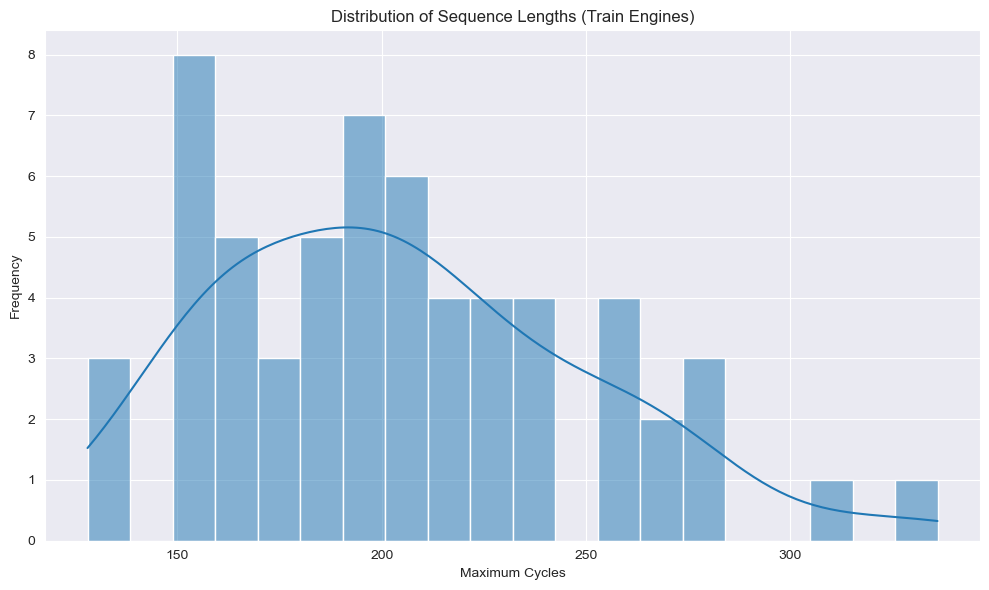

In [5]:
total_engines_train = train_data['engine_id'].nunique()
total_rows_train = len(train_data)
missing_values = train_data.isnull().sum().sum()
infinite_values = np.isinf(train_data.drop(['engine_id', 'cycle'], axis=1)).sum().sum()

cycle_diff = train_data.groupby('engine_id')['cycle'].diff().dropna()
continuity_check = (cycle_diff == 1.0).all()
duplicate_keys = train_data.duplicated(subset=['engine_id', 'cycle']).sum()

plt.figure(figsize=(10, 6))
sns.histplot(train_data.groupby('engine_id')['cycle'].max(), bins=20, kde=True)
plt.title('Distribution of Sequence Lengths (Train Engines)')
plt.xlabel('Maximum Cycles')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
plt.savefig('sequence_length_distribution.png', dpi=300)
plt.close()

In [6]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
variances = train_data[sensor_cols].var()
flatline_sensors = variances[variances < 1e-5].index.tolist()
active_sensors = [s for s in sensor_cols if s not in flatline_sensors]

In [7]:
kmeans = KMeans(n_clusters=1, random_state=42, n_init=10)
op_settings = ['op_setting_1', 'op_setting_2', 'op_setting_3']
train_data['regime'] = kmeans.fit_predict(train_data[op_settings])
num_regimes = train_data['regime'].nunique()
print(num_regimes)

1


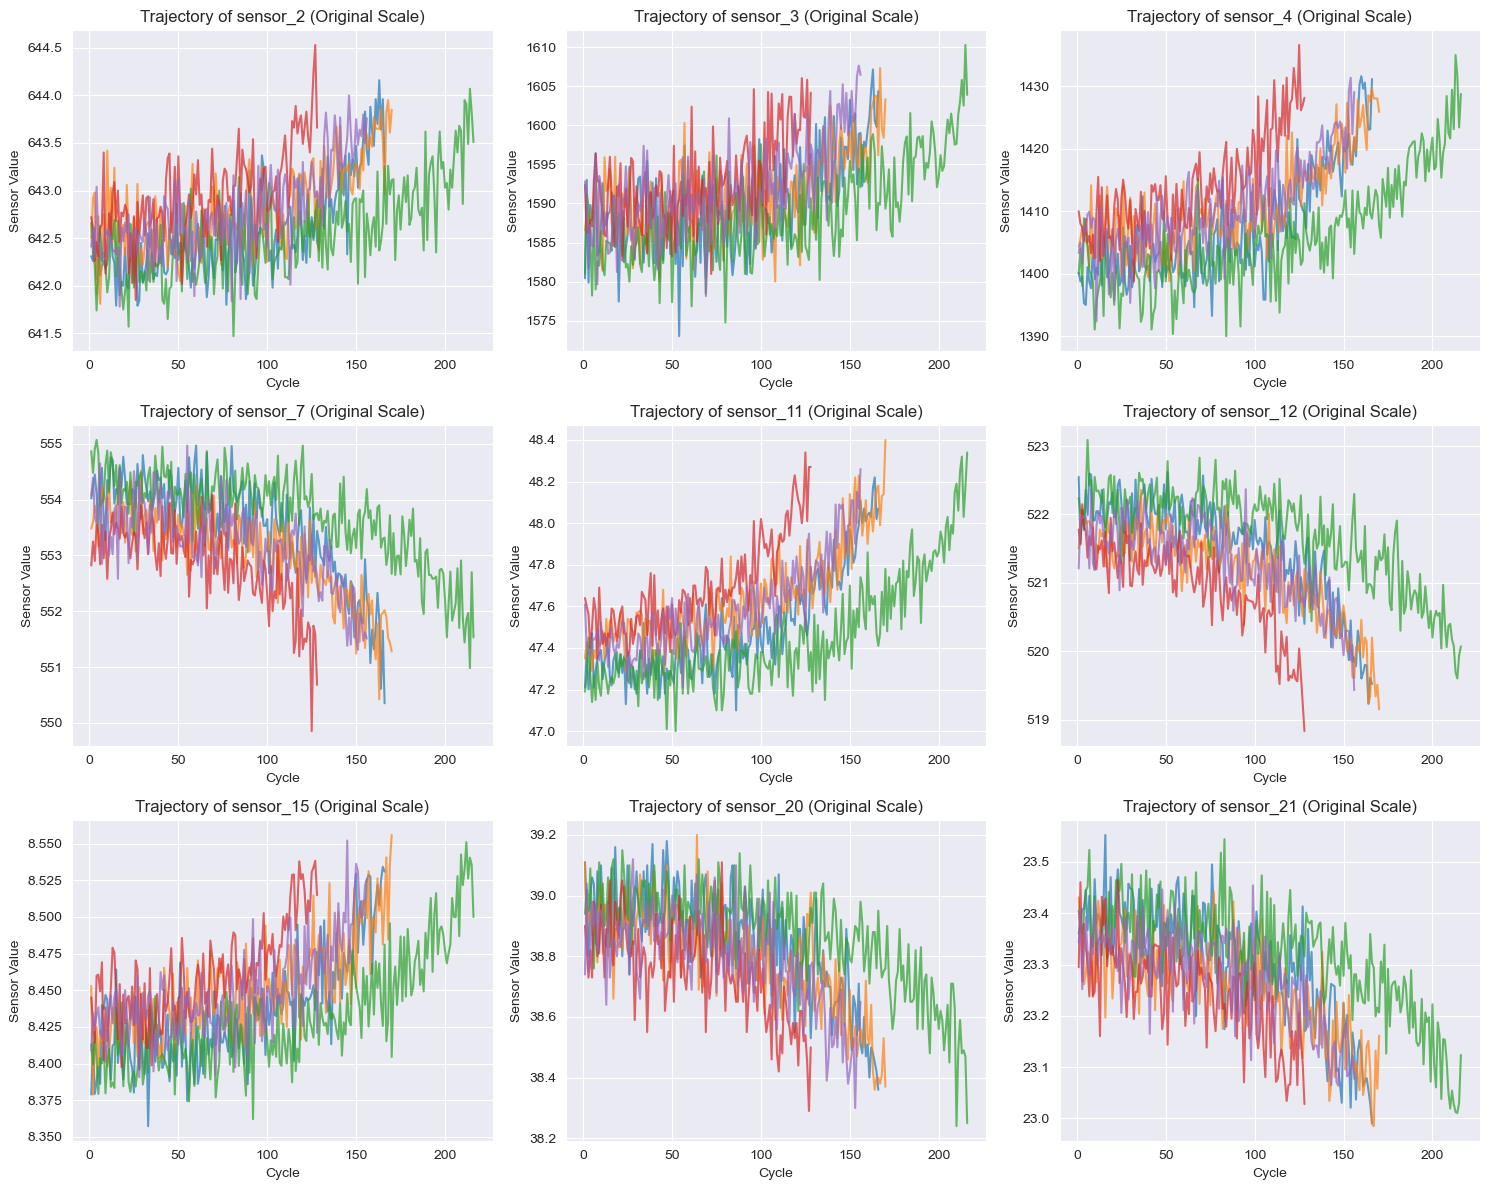

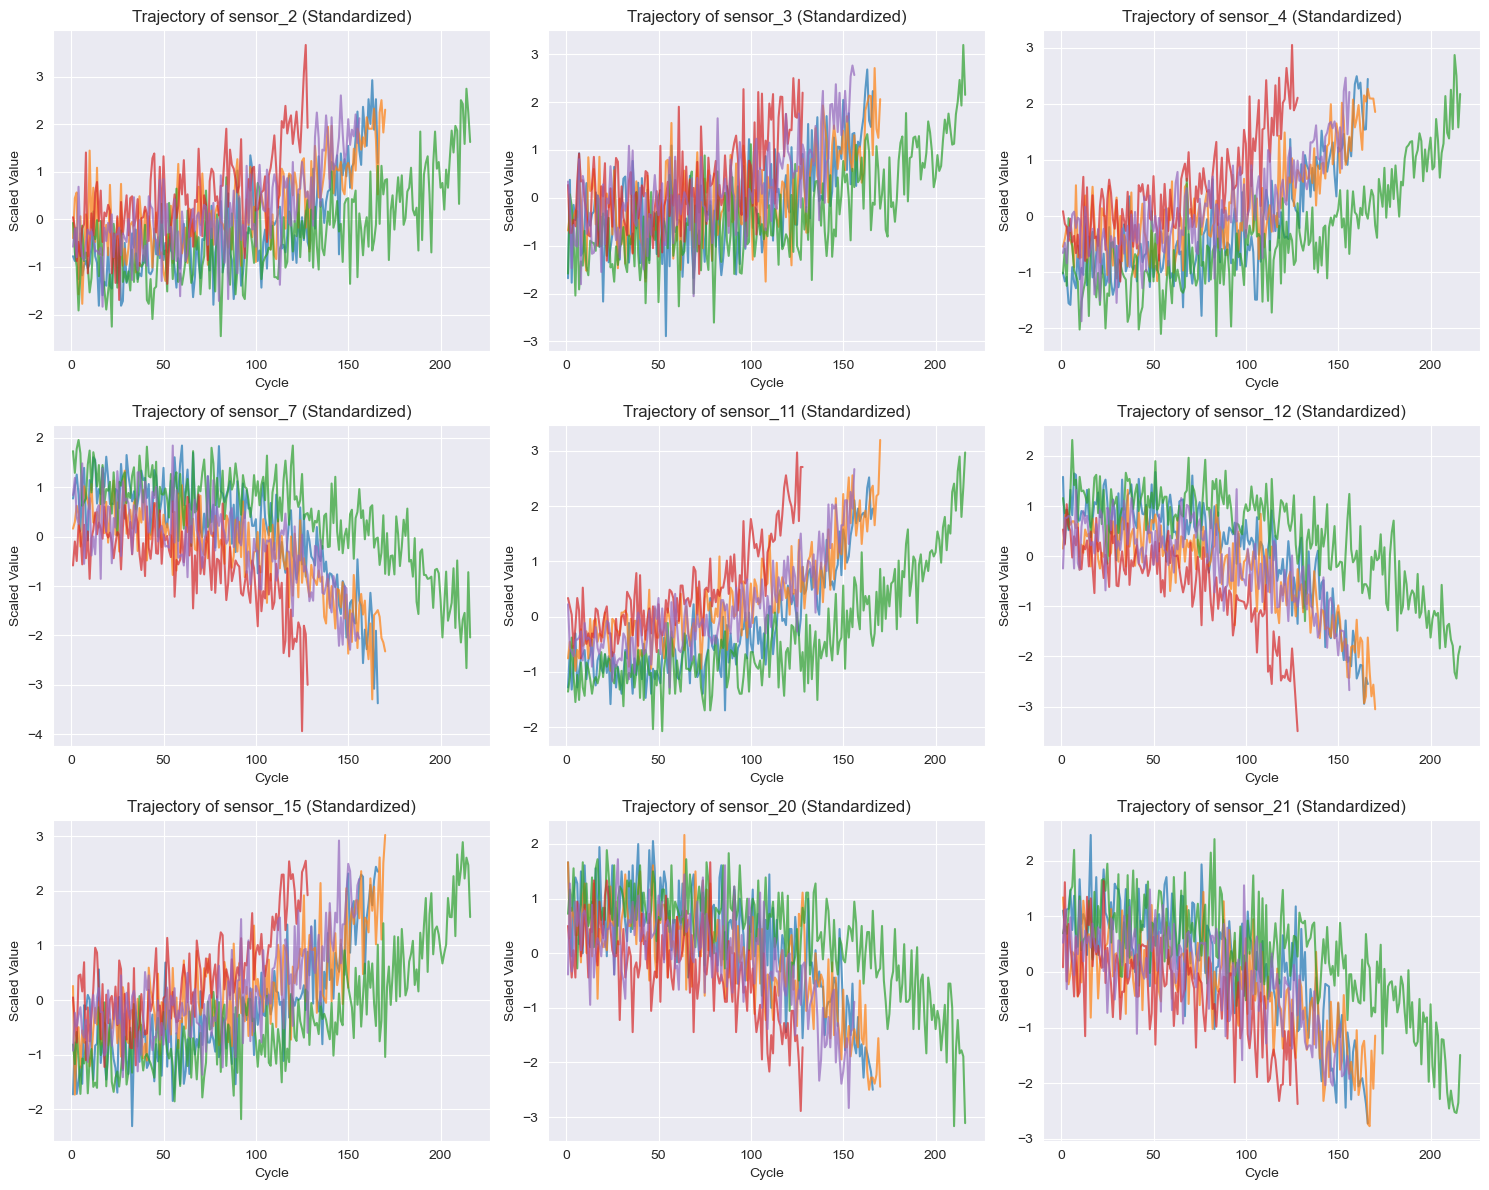

In [8]:
key_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15', 'sensor_20', 'sensor_21']
sample_engines = np.random.choice(train_data['engine_id'].unique(), size=5, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, sensor in enumerate(key_sensors):
    for engine in sample_engines:
        engine_data = train_data[train_data['engine_id'] == engine]
        axes[i].plot(engine_data['cycle'], engine_data[sensor], alpha=0.7)
    axes[i].set_title(f'Trajectory of {sensor} (Original Scale)')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Sensor Value')
plt.tight_layout()
plt.show()
plt.savefig('trajectories_original_scale.png', dpi=300)
plt.close()

scaler_eda = StandardScaler()
train_data_scaled = train_data.copy()
train_data_scaled[key_sensors] = scaler_eda.fit_transform(train_data[key_sensors])

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, sensor in enumerate(key_sensors):
    for engine in sample_engines:
        engine_data = train_data_scaled[train_data_scaled['engine_id'] == engine]
        axes[i].plot(engine_data['cycle'], engine_data[sensor], alpha=0.7)
    axes[i].set_title(f'Trajectory of {sensor} (Standardized)')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Scaled Value')
plt.tight_layout()
plt.show()
plt.savefig('trajectories_standardized_scale.png', dpi=300)
plt.close()

In [9]:
horizons = [10, 20, 30]
class_balance_records = []

for h in horizons:
    train_h = (train_data['RUL'] <= h).mean() * 100
    val_h = (val_data['RUL'] <= h).mean() * 100
    test_h = (test_data_split['RUL'] <= h).mean() * 100
    
    class_balance_records.append({
        'Horizon': h,
        'Train_Class1_%': np.round(train_h, 2),
        'Validation_Class1_%': np.round(val_h, 2),
        'Test_Class1_%': np.round(test_h, 2)
    })

class_balance_df = pd.DataFrame(class_balance_records)
display(class_balance_df)

,Horizon,Train_Class1_%,Validation_Class1_%,Test_Class1_%
0,10,5.38,5.41,5.13
1,20,10.27,10.32,9.79
2,30,15.16,15.23,14.45


In [10]:
audit_data = {
    'Metric': [
        'Total Engines (Pre-split)',
        'Train / Val / Test Engines',
        'Total Train Rows',
        'Dropped Sensors',
        'Number of Dropped Sensors',
        'Rows Dropped',
        'Identified Operating Regimes'
    ],
    'Value': [
        100,
        f'{len(train_engines)} / {len(val_engines)} / {len(test_engines)}',
        total_rows_train,
        ', '.join(flatline_sensors),
        len(flatline_sensors),
        0,
        num_regimes
    ]
}
audit_table = pd.DataFrame(audit_data)
display(audit_table)

,Metric,Value
0,Total Engines (Pre-split),100
1,Train / Val / Test Engines,60 / 20 / 20
2,Total Train Rows,12270
3,Dropped Sensors,"sensor_1, sensor_5, sensor_6, sensor_10, senso..."
4,Number of Dropped Sensors,7
5,Rows Dropped,0
6,Identified Operating Regimes,1


# Task 2

In [11]:
scaler = StandardScaler()
features_to_scale = op_settings + active_sensors

train_fe = train_data.copy().drop(columns=flatline_sensors + ['regime'])
val_fe = val_data.copy().drop(columns=flatline_sensors)
test_fe = test_data_split.copy().drop(columns=flatline_sensors)

train_fe[features_to_scale] = scaler.fit_transform(train_fe[features_to_scale])
val_fe[features_to_scale] = scaler.transform(val_fe[features_to_scale])
test_fe[features_to_scale] = scaler.transform(test_fe[features_to_scale])

print("--- Scaling (Standardization) Results ---")
print(f"Train data shape after scaling: {train_fe.shape}")
print(f"Sample mean of 'sensor_2': {train_fe['sensor_2'].mean():.4f}")
print(f"Sample std of 'sensor_2': {train_fe['sensor_2'].std():.4f}")
print("\nFirst 3 rows of processed Train data:")
display(train_fe.head(10))

--- Scaling (Standardization) Results ---
Train data shape after scaling: (12270, 20)
Sample mean of 'sensor_2': -0.0000
Sample std of 'sensor_2': 1.0000

First 3 rows of processed Train data:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.318814,-1.384029,0.0,-1.754676,-0.167149,-0.961456,1.155737,-0.541320,-0.857754,-0.304006,0.369095,-1.089115,-0.288138,-0.638942,-0.817224,1.387195,1.230816,191
1,1,2,0.871479,-1.043428,0.0,-1.094781,0.178719,-0.678455,0.466852,-0.825105,-0.949169,-0.228729,1.214431,-0.389839,-0.644937,-0.309071,-0.817224,1.053956,1.273268,190
2,1,3,-1.966912,1.000179,0.0,-0.694844,-0.446128,-0.560353,1.042805,-0.257534,-0.566690,-1.056775,1.405313,-0.949260,-0.557864,-0.684534,-2.109324,0.776257,0.540500,189
3,1,4,0.322113,-0.021624,0.0,-0.694844,-1.294483,-0.819956,1.257376,0.168143,-0.715887,-1.583713,2.005228,-0.249984,-0.527839,-2.014746,-0.817224,0.387479,0.814596,188
4,1,5,-0.868180,-0.702826,0.0,-0.654850,-1.284694,-0.335289,0.749182,-0.541320,-0.471394,-1.019137,1.091721,-0.809405,-0.529340,-0.373436,-0.171174,0.498559,1.096075,187
5,1,6,-1.966912,-0.362225,0.0,-1.194765,-1.020399,-1.209918,1.505826,-1.108890,-0.707263,-1.470798,0.396364,-0.949260,-0.576880,-0.872265,-1.463274,0.942877,0.749994,186
6,1,7,0.459454,0.318977,0.0,-0.434885,0.260291,-1.276768,1.133151,-1.108890,-0.299774,-0.718029,1.268968,-0.949260,-0.603403,-1.231637,-0.817224,1.609354,0.846897,185
7,1,8,-1.554888,1.000179,0.0,-0.274910,-1.266748,-0.920232,0.579784,-1.392675,-1.090174,-1.169691,1.473485,-0.949260,-0.665955,-0.958085,-1.463274,0.887337,0.230412,184
8,1,9,0.367893,0.318977,0.0,-1.154771,0.041677,-1.607679,0.399093,-0.683212,-0.846111,-0.981498,0.546343,-0.669549,-0.935181,-1.891379,-0.817224,1.331655,1.116378,183
9,1,10,-1.509107,0.318977,0.0,-1.974642,0.084095,-0.977055,0.286161,-0.683212,-0.620160,-1.960098,0.546343,-0.529694,-0.750526,-0.394891,-0.171174,0.776257,1.695948,182


In [12]:
baseline_train = train_fe.copy()
baseline_val = val_fe.copy()
baseline_test = test_fe.copy()

print("--- Baseline Dataframes Created ---")
print(f"baseline_train shape: {baseline_train.shape}")
print(f"baseline_val shape: {baseline_val.shape}")
print(f"baseline_test shape: {baseline_test.shape}")

--- Baseline Dataframes Created ---
baseline_train shape: (12270, 20)
baseline_val shape: (4070, 20)
baseline_test shape: (4291, 20)


In [13]:
def calculate_slope(y):
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0]

def extract_multi_window_features(df, window_sizes, feature_cols):
    df_out = df.copy()
    grouped = df_out.groupby('engine_id')
    
    for W in window_sizes:
        for col in feature_cols:
            rolling_obj = grouped[col].rolling(window=W, min_periods=1)
            
            df_out[f'{col}_roll_mean_W{W}'] = rolling_obj.mean().reset_index(level=0, drop=True)
            df_out[f'{col}_roll_std_W{W}'] = rolling_obj.std().reset_index(level=0, drop=True).fillna(0)
            df_out[f'{col}_roll_min_W{W}'] = rolling_obj.min().reset_index(level=0, drop=True)
            df_out[f'{col}_roll_max_W{W}'] = rolling_obj.max().reset_index(level=0, drop=True)
            
            df_out[f'{col}_ewma_W{W}'] = grouped[col].apply(lambda x: x.ewm(span=W, adjust=False).mean()).reset_index(level=0, drop=True)
            
            df_out[f'{col}_diff_W{W}'] = grouped[col].diff().fillna(0)
            
            slope_col = grouped[col].rolling(window=W, min_periods=2).apply(calculate_slope, raw=True)
            df_out[f'{col}_slope_W{W}'] = slope_col.reset_index(level=0, drop=True).fillna(0)
    
    return df_out

window_sizes = [10, 20, 50, 100, 150]

train_window_features = extract_multi_window_features(train_fe, window_sizes, active_sensors)
val_window_features = extract_multi_window_features(val_fe, window_sizes, active_sensors)
test_window_features = extract_multi_window_features(test_fe, window_sizes, active_sensors)

print("--- Window Feature Extraction Results ---")
print(f"Number of columns Before extraction: {train_fe.shape[1]}")
print(f"Number of columns After extraction: {train_window_features.shape[1]}")
print(f"Total new features added: {train_window_features.shape[1] - train_fe.shape[1]}")
print(f"Window sizes used: {window_sizes}")
print("\nSnapshot of new features (first 3 rows):")
display(train_window_features.head(10))

--- Window Feature Extraction Results ---
Number of columns Before extraction: 20
Number of columns After extraction: 510
Total new features added: 490
Window sizes used: [10, 20, 50, 100, 150]

Snapshot of new features (first 3 rows):


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,...,sensor_20_ewma_W150,sensor_20_diff_W150,sensor_20_slope_W150,sensor_21_roll_mean_W150,sensor_21_roll_std_W150,sensor_21_roll_min_W150,sensor_21_roll_max_W150,sensor_21_ewma_W150,sensor_21_diff_W150,sensor_21_slope_W150
0,1,1,-0.318814,-1.384029,0.0,-1.754676,-0.167149,-0.961456,1.155737,-0.541320,...,1.387195,0.000000,0.000000,1.230816,0.000000,1.230816,1.230816,1.230816,0.000000,0.000000
1,1,2,0.871479,-1.043428,0.0,-1.094781,0.178719,-0.678455,0.466852,-0.825105,...,1.382781,-0.333239,-0.333239,1.252042,0.030018,1.230816,1.273268,1.231378,0.042453,0.042453
2,1,3,-1.966912,1.000179,0.0,-0.694844,-0.446128,-0.560353,1.042805,-0.257534,...,1.374748,-0.277699,-0.305469,1.014861,0.411357,0.540500,1.273268,1.222227,-0.732768,-0.345158
3,1,4,0.322113,-0.021624,0.0,-0.694844,-1.294483,-0.819956,1.257376,0.168143,...,1.361671,-0.388778,-0.327685,0.964795,0.350480,0.540500,1.273268,1.216828,0.274096,-0.198143
4,1,5,-0.868180,-0.702826,0.0,-0.654850,-1.284694,-0.335289,0.749182,-0.541320,...,1.350239,0.111080,-0.244375,0.991051,0.309151,0.540500,1.273268,1.215229,0.281479,-0.072815
5,1,6,-1.966912,-0.362225,0.0,-1.194765,-1.020399,-1.209918,1.505826,-1.108890,...,1.344844,0.444318,-0.122187,0.950875,0.293503,0.540500,1.273268,1.209067,-0.346081,-0.076045
6,1,7,0.459454,0.318977,0.0,-0.434885,0.260291,-1.276768,1.133151,-1.108890,...,1.348347,0.666477,0.005951,0.936021,0.270797,0.540500,1.273268,1.204270,0.096903,-0.058669
7,1,8,-1.554888,1.000179,0.0,-0.274910,-1.266748,-0.920232,0.579784,-1.392675,...,1.342241,-0.722017,-0.001322,0.847820,0.353682,0.230412,1.273268,1.191371,-0.616485,-0.097913
8,1,9,0.367893,0.318977,0.0,-1.154771,0.041677,-1.607679,0.399093,-0.683212,...,1.342101,0.444318,0.024993,0.877660,0.342736,0.230412,1.273268,1.190378,0.885966,-0.050635
9,1,10,-1.509107,0.318977,0.0,-1.974642,0.084095,-0.977055,0.286161,-0.683212,...,1.334606,-0.555398,0.006732,0.959489,0.413976,0.230412,1.695948,1.197074,0.579570,0.007808


In [14]:
def verify_causality(df, window_sizes, feature_cols):
    sample_engine = df[df['engine_id'] == df['engine_id'].iloc[0]].copy()
    
    res_original = extract_multi_window_features(sample_engine, window_sizes, feature_cols)
    
    target_idx = len(sample_engine) // 2
    future_idx = target_idx + 1
    
    for col in feature_cols:
        sample_engine.iloc[future_idx, sample_engine.columns.get_loc(col)] += 999.0
        
    res_modified = extract_multi_window_features(sample_engine, window_sizes, feature_cols)
    
    orig_cols = [c for c in res_original.columns if c not in ['engine_id', 'cycle', 'RUL']]
    mod_cols = [c for c in res_modified.columns if c not in ['engine_id', 'cycle', 'RUL']]
    
    orig_row = res_original.iloc[target_idx][orig_cols]
    mod_row = res_modified.iloc[target_idx][mod_cols]
    
    return orig_row.equals(mod_row)

causality_passed = verify_causality(train_fe, window_sizes, active_sensors)

print("--- Causality Verification ---")
if causality_passed:
    print("No data leakage from the future detected.")
else:
    print("The extraction function is peeking into future cycles.")

--- Causality Verification ---
No data leakage from the future detected.


# Task 3

In [15]:
rul_threshold = 125

baseline_train['RUL_capped'] = baseline_train['RUL'].clip(upper=rul_threshold)
baseline_val['RUL_capped'] = baseline_val['RUL'].clip(upper=rul_threshold)
train_window_features['RUL_capped'] = train_window_features['RUL'].clip(upper=rul_threshold)
val_window_features['RUL_capped'] = val_window_features['RUL'].clip(upper=rul_threshold)

test_engines_official = test_fd001['engine_id'].unique()
rul_mapping = {engine: rul_fd001.iloc[i, 0] for i, engine in enumerate(test_engines_official)}

test_fd001_final = test_fd001.copy()
test_max_cycle = test_fd001_final.groupby('engine_id')['cycle'].max().to_dict()
test_fd001_final['max_cycle'] = test_fd001_final['engine_id'].map(test_max_cycle)
test_fd001_final['RUL_final'] = test_fd001_final['engine_id'].map(rul_mapping)
test_fd001_final['RUL'] = test_fd001_final['max_cycle'] - test_fd001_final['cycle'] + test_fd001_final['RUL_final']
test_fd001_final['RUL_capped'] = test_fd001_final['RUL'].clip(upper=rul_threshold)

test_fd001_final.drop(columns=flatline_sensors, inplace=True)
test_fd001_final[features_to_scale] = scaler.transform(test_fd001_final[features_to_scale])

baseline_test_official = test_fd001_final.copy()
test_window_features_official = extract_multi_window_features(test_fd001_final, window_sizes, active_sensors)

print("--- Data Prep & Test Target Reconstruction ---")
print(f"RUL Capping Threshold applied: {rul_threshold} cycles")
print(f"Official Baseline Test shape: {baseline_test_official.shape}")
print(f"Official Window Test shape: {test_window_features_official.shape}")
print(f"Window sizes used: {window_sizes}")
print("\nSample mapped RULs for first 5 test engines:")
for eng_id in list(rul_mapping.keys())[:5]:
    print(f" Engine {eng_id}: Final True RUL = {rul_mapping[eng_id]}")

--- Data Prep & Test Target Reconstruction ---
RUL Capping Threshold applied: 125 cycles
Official Baseline Test shape: (13096, 23)
Official Window Test shape: (13096, 513)
Window sizes used: [10, 20, 50, 100, 150]

Sample mapped RULs for first 5 test engines:
 Engine 1: Final True RUL = 112
 Engine 2: Final True RUL = 98
 Engine 3: Final True RUL = 69
 Engine 4: Final True RUL = 82
 Engine 5: Final True RUL = 91


### Saving preproccessed data for better peformance in dashboard

In [16]:
test_window_features_official.to_csv('test_window_fd001_preprocessed.csv.gz', index=False, compression='gzip')
print(f"test_window_fd001_preprocessed saved: {test_window_features_official.shape}")

rul_df_fd001 = pd.DataFrame({
    'engine_id': test_window_features_official['engine_id'].unique(),
    'RUL_final': [test_window_features_official[test_window_features_official['engine_id'] == e]['RUL'].iloc[-1] 
                  for e in test_window_features_official['engine_id'].unique()]
})
rul_df_fd001.to_csv('rul_final_fd001.csv.gz', index=False, compression='gzip')
print(f"rul_final_fd001 saved: {len(rul_df_fd001)} engines")

size_mb = os.path.getsize('test_window_fd001_preprocessed.csv.gz') / (1024 * 1024)
print(f"\nData Summary:")
print(f"  Total rows: {len(test_window_features_official)}")
print(f"  Total columns: {len(test_window_features_official.columns)}")
print(f"  Total features: {len(test_window_features_official.columns) - 4}")
print(f"  Total engines: {len(rul_df_fd001)}")
print(f"  RUL range: {rul_df_fd001['RUL_final'].min()} - {rul_df_fd001['RUL_final'].max()}")
print(f"  File size: {size_mb:.2f} MB (compressed)")

test_window_fd001_preprocessed saved: (13096, 513)
rul_final_fd001 saved: 100 engines

Data Summary:
  Total rows: 13096
  Total columns: 513
  Total features: 509
  Total engines: 100
  RUL range: 7 - 145
  File size: 32.74 MB (compressed)


In [17]:
drop_cols = ['engine_id', 'cycle', 'RUL', 'RUL_capped', 'regime', 'max_cycle', 'RUL_final']

X_train_base = baseline_train.drop(columns=[c for c in drop_cols if c in baseline_train.columns])
y_train = baseline_train['RUL_capped']

X_val_base = baseline_val.drop(columns=[c for c in drop_cols if c in baseline_val.columns])
y_val = baseline_val['RUL_capped']

X_test_base = baseline_test_official.drop(columns=[c for c in drop_cols if c in baseline_test_official.columns])
y_test_true = baseline_test_official['RUL']

feature_cols_window = [col for col in train_window_features.columns if col not in drop_cols]

X_train_win_df = train_window_features[feature_cols_window]
X_val_win_df = val_window_features[feature_cols_window]
X_test_win_df = test_window_features_official[feature_cols_window]

X_train_win = X_train_win_df.values
X_val_win = X_val_win_df.values
X_test_win = X_test_win_df.values

print("--- Feature Matrices (X) & Targets (y) Status ---")
print(f"Base Features   -> Train: {X_train_base.shape} | Val: {X_val_base.shape} | Test: {X_test_base.shape}")
print(f"Window Features -> Train: {X_train_win.shape}  | Val: {X_val_win.shape}  | Test: {X_test_win.shape}")
print(f"Targets Lengths -> y_train: {len(y_train)} | y_val: {len(y_val)} | y_test_true: {len(y_test_true)}")
print(f"DataFrame versions available: X_train_win_df, X_val_win_df, X_test_win_df")

--- Feature Matrices (X) & Targets (y) Status ---
Base Features   -> Train: (12270, 17) | Val: (4070, 17) | Test: (13096, 17)
Window Features -> Train: (12270, 507)  | Val: (4070, 507)  | Test: (13096, 507)
Targets Lengths -> y_train: 12270 | y_val: 4070 | y_test_true: 13096
DataFrame versions available: X_train_win_df, X_val_win_df, X_test_win_df


In [18]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_base, y_train)

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=10.0, random_state=42))
])
poly_model.fit(X_train_base, y_train)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_base, y_train)

xgb_base_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_base_model.fit(X_train_base, y_train)

xgb_win_model = xgb.XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_win_model.fit(X_train_win, y_train)

print("--- Model Training Completed Successfully ---")
print("Trained Models Summary:")
print(f" 1. Ridge Regression       (Features: {X_train_base.shape[1]})")
print(f" 2. Polynomial Ridge       (Features: {X_train_base.shape[1]})")
print(f" 3. Random Forest          (Features: {X_train_base.shape[1]})")
print(f" 4. XGBoost (Base)         (Features: {X_train_base.shape[1]})")
print(f" 5. XGBoost (Windowing)    (Features: {X_train_win.shape[1]})")

--- Model Training Completed Successfully ---
Trained Models Summary:
 1. Ridge Regression       (Features: 17)
 2. Polynomial Ridge       (Features: 17)
 3. Random Forest          (Features: 17)
 4. XGBoost (Base)         (Features: 17)
 5. XGBoost (Windowing)    (Features: 507)


In [19]:
def asymmetric_cost(y_true, y_pred):
    diff = y_pred - y_true
    return np.where(diff > 0, 2 * diff, -diff).sum()

def bootstrap_rmse_ci(df_test, model, X_test, y_true_col, n_iterations=100):
    engines = df_test['engine_id'].unique()
    rmses = []
    preds = model.predict(X_test)
    df_eval = df_test.copy()
    df_eval['pred'] = preds
    
    for _ in range(n_iterations):
        sample_engines = np.random.choice(engines, size=len(engines), replace=True)
        sampled_data = pd.concat([df_eval[df_eval['engine_id'] == e] for e in sample_engines])
        rmse = np.sqrt(mean_squared_error(sampled_data[y_true_col], sampled_data['pred']))
        rmses.append(rmse)
    
    return np.percentile(rmses, 2.5), np.percentile(rmses, 97.5)

models_dict = {
    'Ridge (Base)': (ridge_model, X_test_base),
    'Polynomial (Base)': (poly_model, X_test_base),
    'Random Forest (Base)': (rf_model, X_test_base),
    'XGBoost (Base)': (xgb_base_model, X_test_base),
    'XGBoost (Window)': (xgb_win_model, X_test_win)
}

regions = {
    'Near-failure': lambda y: y <= 50,
    'Mid-life': lambda y: (y > 50) & (y <= 150),
    'Early-life': lambda y: y > 150
}

results = []

for name, (model, X_test_data) in models_dict.items():
    preds = model.predict(X_test_data)
    
    mae_tot = mean_absolute_error(y_test_true, preds)
    rmse_tot = np.sqrt(mean_squared_error(y_test_true, preds))
    r2_tot = r2_score(y_test_true, preds)
    cost_tot = asymmetric_cost(y_test_true, preds)
    
    ci_lower, ci_upper = bootstrap_rmse_ci(baseline_test_official, model, X_test_data, 'RUL')
    
    row = {'Model': name, 'Overall MAE': mae_tot, 'Overall RMSE': rmse_tot, 
           'Overall R2': r2_tot, 'Asym Cost': cost_tot, 
           '95% CI RMSE': f"[{ci_lower:.2f}, {ci_upper:.2f}]"}
    
    for region_name, condition in regions.items():
        mask = condition(y_test_true)
        if mask.sum() > 0:
            rmse_reg = np.sqrt(mean_squared_error(y_test_true[mask], preds[mask]))
            row[f'RMSE ({region_name})'] = rmse_reg
            
    results.append(row)

evaluation_df = pd.DataFrame(results).round(2)

print("--- Comprehensive Evaluation Table ---")
display(evaluation_df)

--- Comprehensive Evaluation Table ---


,Model,Overall MAE,Overall RMSE,Overall R2,Asym Cost,95% CI RMSE,RMSE (Near-failure),RMSE (Mid-life),RMSE (Early-life)
0,Ridge (Base),45.70,60.26,-0.04,671227.89,"[54.10, 68.39]",31.35,25.39,87.11
1,Polynomial (Base),43.93,58.46,0.02,648741.85,"[50.43, 66.03]",32.08,24.01,84.62
2,Random Forest (Base),44.92,59.89,-0.03,659504.06,"[51.65, 67.99]",30.82,23.31,87.24
3,XGBoost (Base),44.26,59.23,-0.01,649893.27,"[53.29, 67.13]",30.30,23.13,86.26
4,XGBoost (Window),39.36,55.48,0.12,553731.41,"[46.74, 60.36]",7.97,17.43,82.72


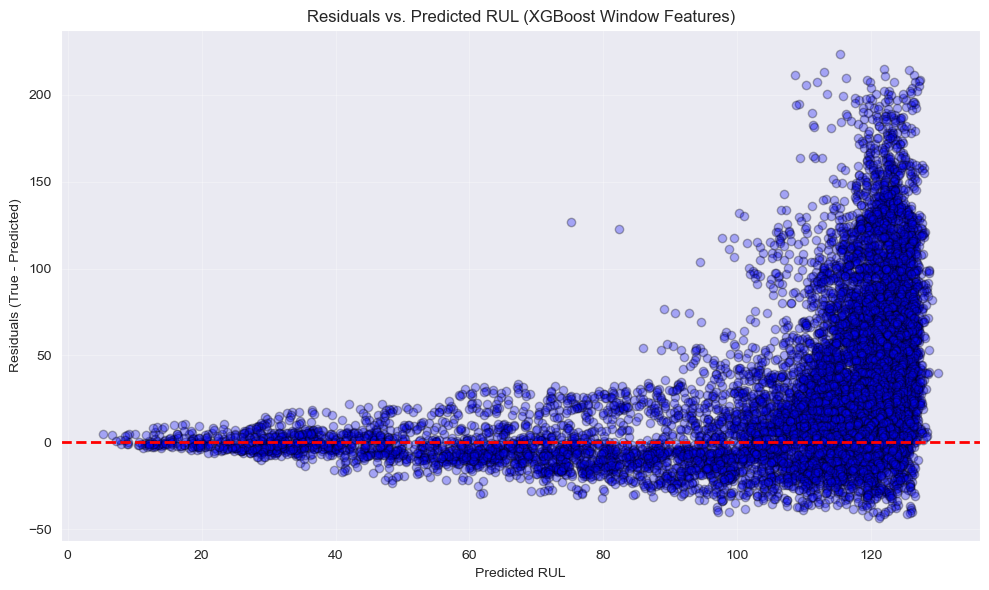

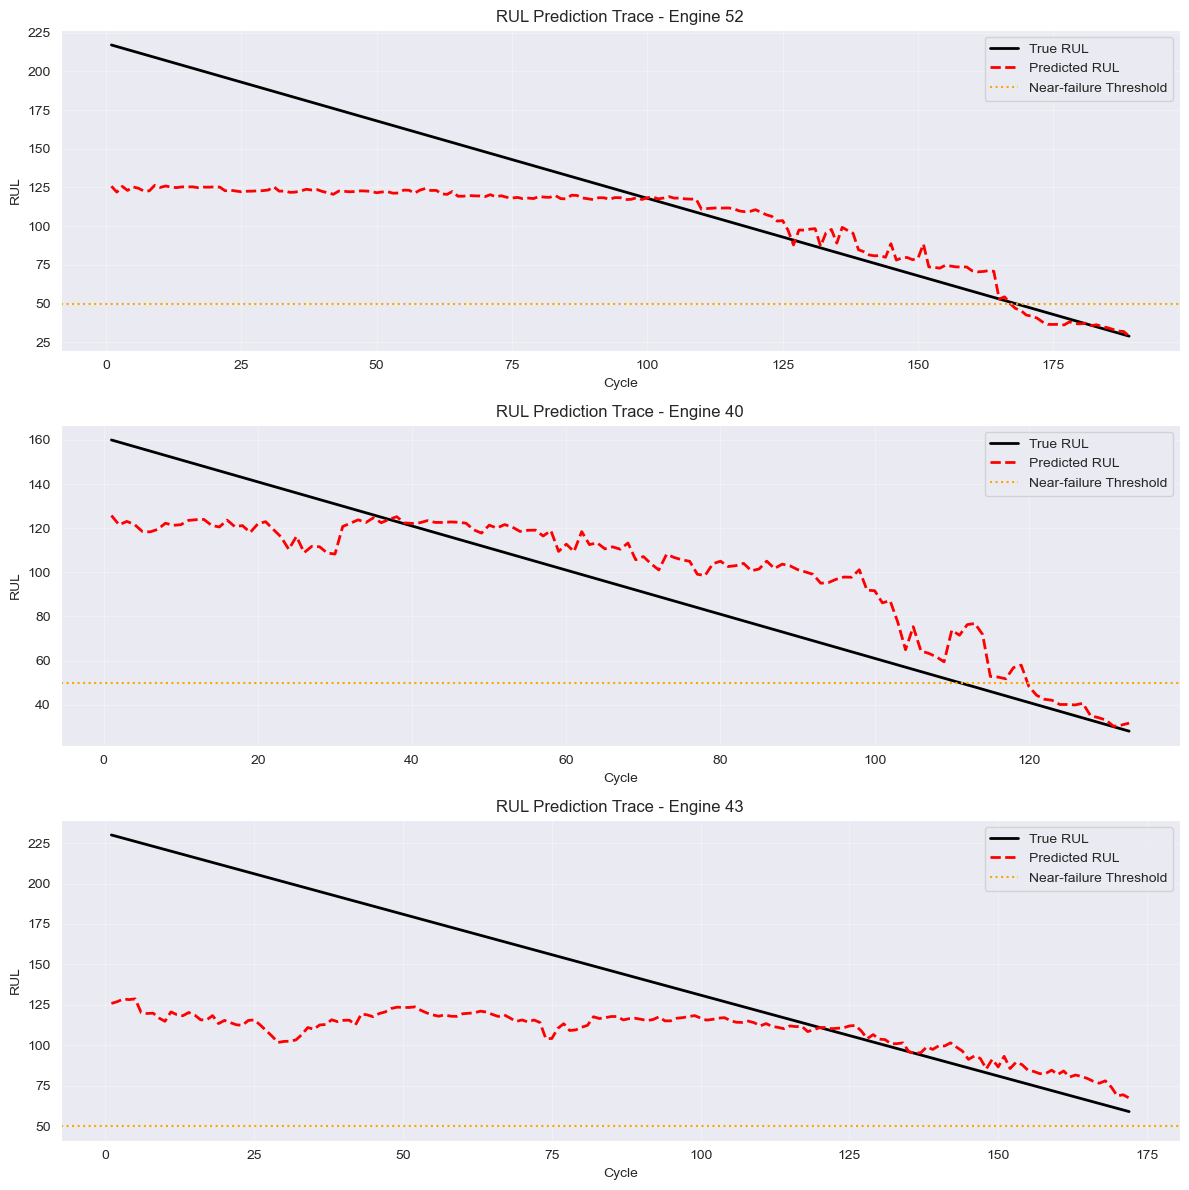

In [20]:
best_model = xgb_win_model
best_X_test = X_test_win
y_pred_best = best_model.predict(best_X_test)
residuals = y_test_true - y_pred_best

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, residuals, alpha=0.3, color='blue', edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Predicted RUL (XGBoost Window Features)')
plt.xlabel('Predicted RUL')
plt.ylabel('Residuals (True - Predicted)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('residual_plot_xgb_window.png', dpi=300)
plt.close()

sample_test_engines = np.random.choice(test_engines_official, size=3, replace=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
for i, engine in enumerate(sample_test_engines):
    engine_mask = baseline_test_official['engine_id'] == engine
    true_rul_trace = baseline_test_official.loc[engine_mask, 'RUL'].values
    engine_X_test = X_test_win_df.loc[engine_mask]
    pred_rul_trace = best_model.predict(engine_X_test)
    cycles = baseline_test_official.loc[engine_mask, 'cycle'].values
    
    axes[i].plot(cycles, true_rul_trace, label='True RUL', color='black', linewidth=2)
    axes[i].plot(cycles, pred_rul_trace, label='Predicted RUL', color='red', linestyle='--', linewidth=2)
    axes[i].axhline(50, color='orange', linestyle=':', label='Near-failure Threshold')
    axes[i].set_title(f'RUL Prediction Trace - Engine {engine}')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('RUL')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('prediction_traces_test_engines.png', dpi=300)
plt.close()

In [21]:
cal_split_idx = int(len(X_val_win_df) * 0.5)
X_cal = X_val_win_df.iloc[:cal_split_idx]
y_cal_true = val_window_features['RUL'].iloc[:cal_split_idx]

preds_cal = np.asarray(best_model.predict(X_cal)).flatten()
y_cal_arr = np.asarray(y_cal_true).flatten()

RUL_CAP = 125
y_cal_eval = np.clip(y_cal_arr, a_min=None, a_max=RUL_CAP)

scores = np.abs(y_cal_eval - preds_cal)

mask_near = preds_cal <= 50
mask_mid = (preds_cal > 50) & (preds_cal <= 100)
mask_early = preds_cal > 100

q_95_near = np.percentile(scores[mask_near], 95) if np.sum(mask_near) > 5 else 12.0
q_95_mid = np.percentile(scores[mask_mid], 95) if np.sum(mask_mid) > 5 else 25.0
q_95_early = np.percentile(scores[mask_early], 95) if np.sum(mask_early) > 5 else 35.0

print(f"Calculated q_95 (Near-Failure, <=50): {q_95_near:.2f}")
print(f"Calculated q_95 (Mid-Life, 50-100): {q_95_mid:.2f}")
print(f"Calculated q_95 (Early-Life, >100): {q_95_early:.2f}")

preds_test_rul = np.asarray(best_model.predict(X_test_win)).flatten()
y_test_true_arr = np.asarray(y_test_true).flatten()

y_test_eval = np.clip(y_test_true_arr, a_min=None, a_max=RUL_CAP)

q_dynamic = np.select(
    [preds_test_rul <= 50, (preds_test_rul > 50) & (preds_test_rul <= 100)],
    [q_95_near, q_95_mid],
    default=q_95_early
)

lower_bounds = np.maximum(0, preds_test_rul - q_dynamic)
upper_bounds = preds_test_rul + q_dynamic

inside_interval = (y_test_eval >= lower_bounds) & (y_test_eval <= upper_bounds)
coverage = np.mean(inside_interval)
mean_interval_width = np.mean(upper_bounds - lower_bounds)

conformal_results = pd.DataFrame({
    'Metric': [
        'q_95 (Near / Mid / Early)', 
        'Empirical Coverage on Test (%)', 
        'Mean Interval Width (Cycles)'
    ],
    'Value': [
        f"{q_95_near:.1f} / {q_95_mid:.1f} / {q_95_early:.1f}", 
        f"{coverage * 100:.2f}%", 
        f"{mean_interval_width:.2f}"
    ]
})

print("\n--- 3-Region Adaptive Conformal Prediction Results ---")
display(conformal_results)

if coverage >= 0.90:
    print(f"Empirical coverage ({coverage*100:.2f}%) is successfully maintained.")
else:
    print(f"Empirical coverage ({coverage*100:.2f}%) is below target.")

Calculated q_95 (Near-Failure, <=50): 10.35
Calculated q_95 (Mid-Life, 50-100): 25.94
Calculated q_95 (Early-Life, >100): 22.79

--- 3-Region Adaptive Conformal Prediction Results ---


,Metric,Value
0,q_95 (Near / Mid / Early),10.3 / 25.9 / 22.8
1,Empirical Coverage on Test (%),95.46%
2,Mean Interval Width (Cycles),45.02


Empirical coverage (95.46%) is successfully maintained.


# Task 4

In [22]:
horizons = [10, 20, 30]

for h in horizons:
    baseline_train[f'label_h{h}'] = (baseline_train['RUL'] <= h).astype(int)
    baseline_val[f'label_h{h}'] = (baseline_val['RUL'] <= h).astype(int)
    baseline_test_official[f'label_h{h}'] = (baseline_test_official['RUL'] <= h).astype(int)

X_train_cls = X_train_win_df.copy()
X_val_cls = X_val_win_df.copy()
X_test_cls = X_test_win_df.copy()

y_train_cls = {h: baseline_train[f'label_h{h}'] for h in horizons}
y_val_cls = {h: baseline_val[f'label_h{h}'] for h in horizons}
y_test_cls = {h: baseline_test_official[f'label_h{h}'] for h in horizons}

models_cls = {}
for h in horizons:
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_cls, y_train_cls[h])
    
    xgb_c = xgb.XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
    xgb_c.fit(X_train_cls, y_train_cls[h])
    
    models_cls[h] = {'LR': lr, 'XGBoost': xgb_c}
    
    
print("--- Target Label Creation & Classification Training ---")
print(f"Features matrix shape: Train={X_train_cls.shape} | Val={X_val_cls.shape} | Test={X_test_cls.shape}\n")
print("Class Imbalance Analysis (Positive samples = RUL <= Horizon):")
for h in horizons:
    pos_train = y_train_cls[h].sum()
    total_train = len(y_train_cls[h])
    pos_test = y_test_cls[h].sum()
    total_test = len(y_test_cls[h])
    print(f"Horizon {h:2d} cycles -> Train: {pos_train:5d}/{total_train} ({pos_train/total_train*100:.1f}%) | Test: {pos_test:5d}/{total_test} ({pos_test/total_test*100:.1f}%)")

--- Target Label Creation & Classification Training ---
Features matrix shape: Train=(12270, 507) | Val=(4070, 507) | Test=(13096, 507)

Class Imbalance Analysis (Positive samples = RUL <= Horizon):
Horizon 10 cycles -> Train:   660/12270 (5.4%) | Test:    17/13096 (0.1%)
Horizon 20 cycles -> Train:  1260/12270 (10.3%) | Test:   123/13096 (0.9%)
Horizon 30 cycles -> Train:  1860/12270 (15.2%) | Test:   332/13096 (2.5%)


In [23]:
def tune_threshold(y_true, y_prob, fn_cost=10, fp_cost=1):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = []
    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        costs.append(fn * fn_cost + fp * fp_cost)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx]

calibrated_models = {}
tuned_thresholds = {}

for h in horizons:
    calibrated_models[h] = {}
    tuned_thresholds[h] = {}
    for name, model in models_cls[h].items():
        calib_model = CalibratedClassifierCV(estimator=model, method='isotonic', cv='prefit')
        calib_model.fit(X_val_cls, y_val_cls[h])
        calibrated_models[h][name] = calib_model
        
        y_val_prob = calib_model.predict_proba(X_val_cls)[:, 1]
        best_th, _ = tune_threshold(y_val_cls[h], y_val_prob, fn_cost=10, fp_cost=1)
        tuned_thresholds[h][name] = best_th
        
print("--- Isotonic Calibration & Asymmetric Threshold Tuning ---")
print("Tuned Decision Thresholds (Optimized for Cost Ratio FN:FP = 10:1):")
for h in horizons:
    print(f"\n[Horizon {h} Cycles]")
    for name in ['LR', 'XGBoost']:
        th = tuned_thresholds[h][name]
        print(f"{name:7s} -> Optimal Threshold: {th:.4f} (Shifted from default 0.5000)")

--- Isotonic Calibration & Asymmetric Threshold Tuning ---
Tuned Decision Thresholds (Optimized for Cost Ratio FN:FP = 10:1):

[Horizon 10 Cycles]
LR      -> Optimal Threshold: 0.0300 (Shifted from default 0.5000)
XGBoost -> Optimal Threshold: 0.0100 (Shifted from default 0.5000)

[Horizon 20 Cycles]
LR      -> Optimal Threshold: 0.0800 (Shifted from default 0.5000)
XGBoost -> Optimal Threshold: 0.0800 (Shifted from default 0.5000)

[Horizon 30 Cycles]
LR      -> Optimal Threshold: 0.0300 (Shifted from default 0.5000)
XGBoost -> Optimal Threshold: 0.0700 (Shifted from default 0.5000)


In [24]:
def bootstrap_prauc_ci(df_test, model, X_test, y_true_col, n_iterations=100):
    engines = df_test['engine_id'].unique()
    praucs = []
    preds_prob = model.predict_proba(X_test)[:, 1]
    df_eval = df_test.copy()
    df_eval['prob'] = preds_prob
    
    for _ in range(n_iterations):
        sample_engines = np.random.choice(engines, size=len(engines), replace=True)
        sampled_data = pd.concat([df_eval[df_eval['engine_id'] == e] for e in sample_engines])
        y_true_samp = sampled_data[y_true_col]
        y_prob_samp = sampled_data['prob']
        if len(np.unique(y_true_samp)) > 1:
            pr, rc, _ = precision_recall_curve(y_true_samp, y_prob_samp)
            praucs.append(auc(rc, pr))
            
    return np.percentile(praucs, 2.5), np.percentile(praucs, 97.5)

cls_results = []
for h in horizons:
    for name, model in calibrated_models[h].items():
        y_test_true = y_test_cls[h]
        y_test_prob = model.predict_proba(X_test_cls)[:, 1]
        
        th = tuned_thresholds[h][name]
        y_test_pred_tuned = (y_test_prob >= th).astype(int)
        y_test_pred_05 = (y_test_prob >= 0.5).astype(int)
        
        pr, rc, _ = precision_recall_curve(y_test_true, y_test_prob)
        pr_auc_val = auc(rc, pr)
        brier = brier_score_loss(y_test_true, y_test_prob)
        
        prec_tuned = precision_score(y_test_true, y_test_pred_tuned, zero_division=0)
        rec_tuned = recall_score(y_test_true, y_test_pred_tuned, zero_division=0)
        f1_tuned = f1_score(y_test_true, y_test_pred_tuned, zero_division=0)
        
        cm_05 = confusion_matrix(y_test_true, y_test_pred_05)
        
        ci_lower, ci_upper = bootstrap_prauc_ci(baseline_test_official, model, X_test_cls, f'label_h{h}')
        
        cls_results.append({
            'Horizon': h,
            'Model': name,
            'PR-AUC': pr_auc_val,
            '95% CI PR-AUC': f"[{ci_lower:.3f}, {ci_upper:.3f}]",
            'Brier Score': brier,
            'Optimal Thresh': th,
            'Prec (Tuned)': prec_tuned,
            'Recall (Tuned)': rec_tuned,
            'F1 (Tuned)': f1_tuned,
            'CM at 0.5 [TN,FP,FN,TP]': cm_05.ravel().tolist()
        })

classification_evaluation_df = pd.DataFrame(cls_results).round(3)

print("--- Comprehensive Classification & Uncertainty Evaluation ---")
display(classification_evaluation_df)

--- Comprehensive Classification & Uncertainty Evaluation ---


,Horizon,Model,PR-AUC,95% CI PR-AUC,Brier Score,Optimal Thresh,Prec (Tuned),Recall (Tuned),F1 (Tuned),"CM at 0.5 [TN,FP,FN,TP]"
0,10,LR,0.759,"[0.441, 0.992]",0.001,0.03,0.254,1.000,0.405,"[13072, 7, 1, 16]"
1,10,XGBoost,0.629,"[0.405, 0.948]",0.001,0.01,0.239,1.000,0.386,"[13069, 10, 6, 11]"
2,20,LR,0.852,"[0.700, 0.930]",0.003,0.08,0.588,0.951,0.727,"[12940, 33, 20, 103]"
3,20,XGBoost,0.885,"[0.708, 0.957]",0.003,0.08,0.568,0.984,0.720,"[12956, 17, 32, 91]"
4,30,LR,0.943,"[0.903, 0.972]",0.005,0.03,0.686,0.973,0.804,"[12699, 65, 32, 300]"
5,30,XGBoost,0.942,"[0.906, 0.964]",0.005,0.07,0.683,0.985,0.806,"[12723, 41, 54, 278]"


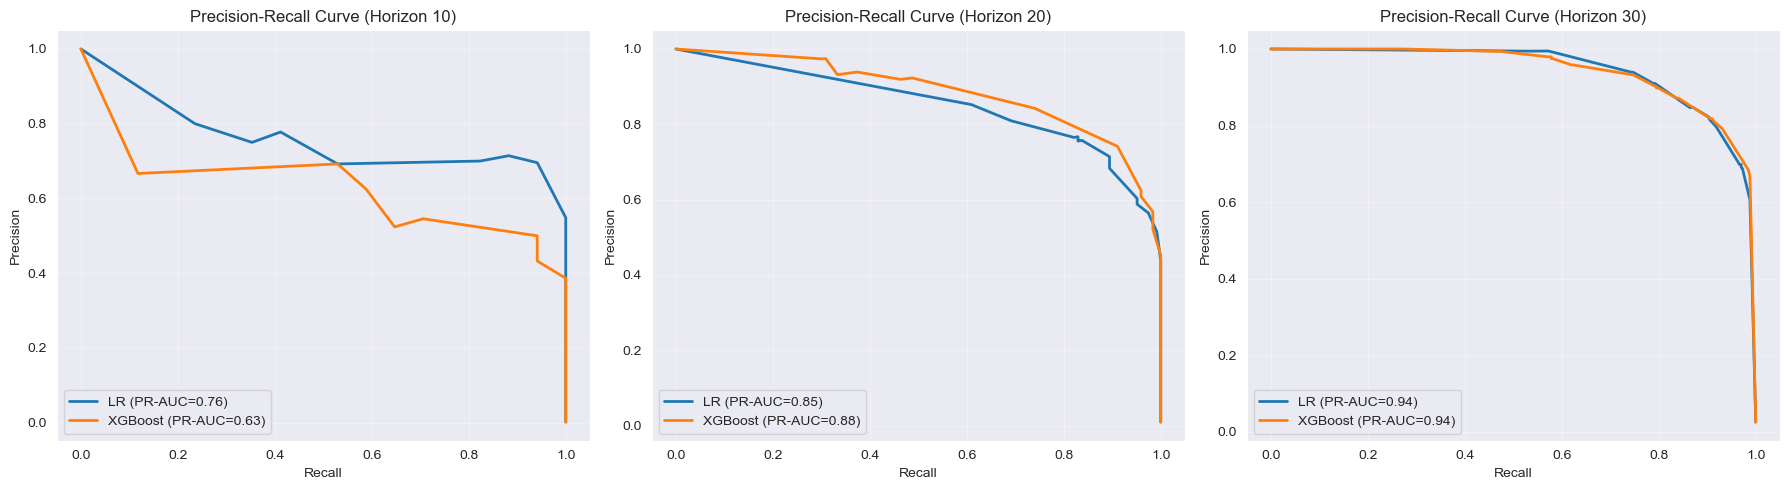

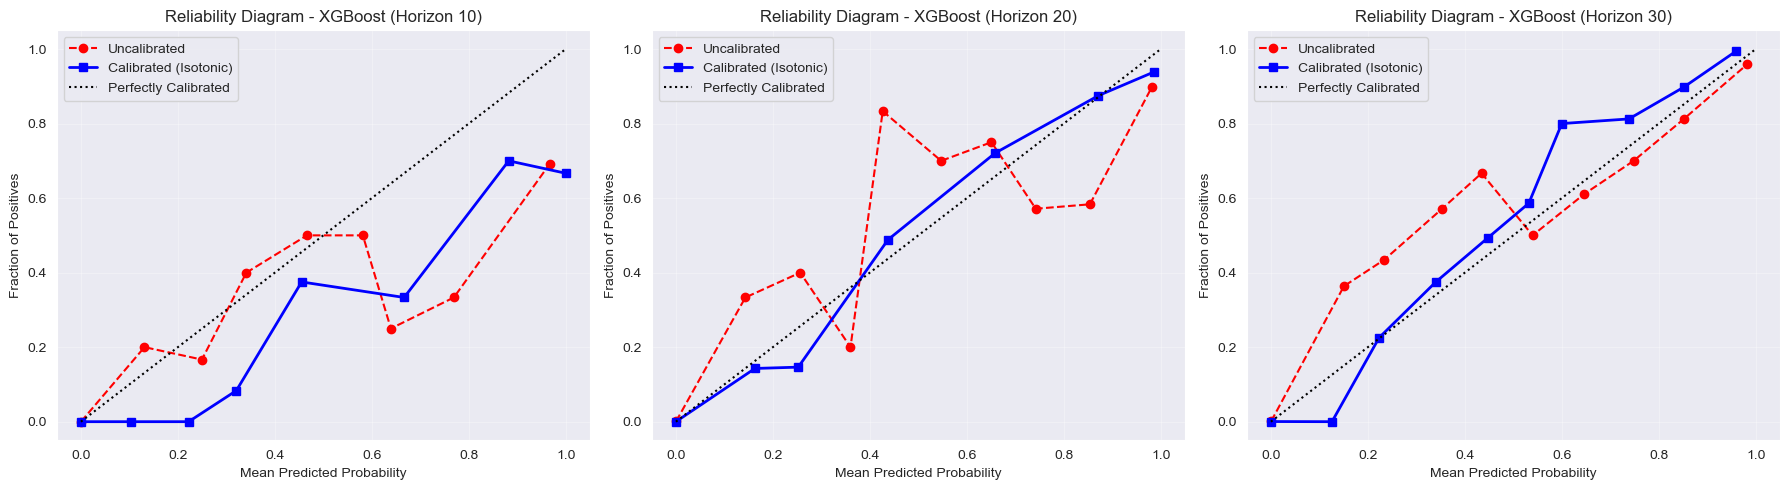

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, h in enumerate(horizons):
    for name, model in calibrated_models[h].items():
        y_test_prob = model.predict_proba(X_test_cls)[:, 1]
        pr, rc, _ = precision_recall_curve(y_test_cls[h], y_test_prob)
        axes[i].plot(rc, pr, linewidth=2, label=f'{name} (PR-AUC={auc(rc, pr):.2f})')
        
    axes[i].set_title(f'Precision-Recall Curve (Horizon {h})')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend(loc='lower left')
    axes[i].grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()
plt.savefig('pr_curves_horizons.png', dpi=300)
plt.close()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, h in enumerate(horizons):
    for name in ['XGBoost']:
        uncalib_prob = models_cls[h][name].predict_proba(X_test_cls)[:, 1]
        calib_prob = calibrated_models[h][name].predict_proba(X_test_cls)[:, 1]
        
        fop_uncalib, mpv_uncalib = calibration_curve(y_test_cls[h], uncalib_prob, n_bins=10)
        fop_calib, mpv_calib = calibration_curve(y_test_cls[h], calib_prob, n_bins=10)
        
        axes[i].plot(mpv_uncalib, fop_uncalib, marker='o', linestyle='--', color='red', label='Uncalibrated')
        axes[i].plot(mpv_calib, fop_calib, marker='s', color='blue', linewidth=2, label='Calibrated (Isotonic)')
        
    axes[i].plot([0, 1], [0, 1], color='black', linestyle=':', label='Perfectly Calibrated')
    axes[i].set_title(f'Reliability Diagram - XGBoost (Horizon {h})')
    axes[i].set_xlabel('Mean Predicted Probability')
    axes[i].set_ylabel('Fraction of Positives')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()
plt.savefig('reliability_curves_calibration.png', dpi=300)
plt.close()

# Task 5

In [26]:
warnings.filterwarnings('ignore')

healthy_threshold = 150

healthy_mask_train = baseline_train['RUL'] > healthy_threshold
X_train_healthy = X_train_win_df[healthy_mask_train].copy()

healthy_mask_val = baseline_val['RUL'] > healthy_threshold
X_val_healthy = X_val_win_df[healthy_mask_val].copy()

print("\n--- Healthy Region Isolation ---")
print(f"Healthy Threshold applied: RUL > {healthy_threshold} cycles")
print(f"Train Dataset -> Total: {len(X_train_win_df):5d} | Healthy: {len(X_train_healthy):5d} ({len(X_train_healthy)/len(X_train_win_df)*100:.1f}%)")
print(f"Val Dataset   -> Total: {len(X_val_win_df):5d} | Healthy: {len(X_val_healthy):5d} ({len(X_val_healthy)/len(X_val_win_df)*100:.1f}%)")


--- Healthy Region Isolation ---
Healthy Threshold applied: RUL > 150 cycles
Train Dataset -> Total: 12270 | Healthy:  3264 (26.6%)
Val Dataset   -> Total:  4070 | Healthy:  1068 (26.2%)


In [27]:
pca_temp = PCA(random_state=42).fit(X_train_win_df)
cumulative_variance = np.cumsum(pca_temp.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

models_unsupervised = {
    'Isolation_Forest': IsolationForest(contamination=0.05, random_state=42, n_jobs=-1),
    'LOF': LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1),
    'OCSVM': OneClassSVM(kernel='rbf', nu=0.05, gamma='scale'),
    'PCA': PCA(n_components=n_components_90, random_state=42)
}

models_unsupervised['Isolation_Forest'].fit(X_train_win_df)
models_unsupervised['LOF'].fit(X_train_win_df)
models_unsupervised['OCSVM'].fit(X_train_healthy) 
models_unsupervised['PCA'].fit(X_train_win_df)

print("--- Unsupervised Models Training Status ---")
print(f"90% cumulative variance achieved with {n_components_90} components (out of {X_train_win_df.shape[1]} total features).")
print(f"Actual Cumulative Variance Retained: {cumulative_variance[n_components_90-1]*100:.2f}%\n")
print("Model Training Overview:")
print(f" 1. Isolation Forest -> Fitted on All Train samples ({X_train_win_df.shape[0]})")
print(f" 2. LOF (Novelty)    -> Fitted on All Train samples ({X_train_win_df.shape[0]})")
print(f" 3. One-Class SVM    -> Fitted Only on Healthy Train samples ({X_train_healthy.shape[0]})")
print(f" 4. PCA Model        -> Fitted on All Train samples ({X_train_win_df.shape[0]})")

--- Unsupervised Models Training Status ---
90% cumulative variance achieved with 14 components (out of 507 total features).
Actual Cumulative Variance Retained: 90.34%

Model Training Overview:
 1. Isolation Forest -> Fitted on All Train samples (12270)
 2. LOF (Novelty)    -> Fitted on All Train samples (12270)
 3. One-Class SVM    -> Fitted Only on Healthy Train samples (3264)
 4. PCA Model        -> Fitted on All Train samples (12270)


In [28]:
def get_anomaly_scores(model, X, model_name):
    if model_name in ['Isolation_Forest', 'LOF', 'OCSVM']:
        return -model.decision_function(X)
    elif model_name == 'PCA':
        X_reconstructed = model.inverse_transform(model.transform(X))
        return np.mean((X - X_reconstructed)**2, axis=1)

raw_scores_val = {}
for name, model in models_unsupervised.items():
    raw_scores_val[name] = get_anomaly_scores(model, X_val_win_df, name)

def raw_to_percentile(reference_scores, new_scores):
    return np.array([percentileofscore(reference_scores, s, kind='weak') for s in new_scores])

pct_scores_val = {}
pct_scores_test = {}

for name, model in models_unsupervised.items():
    raw_test = get_anomaly_scores(model, X_test_win_df, name)
    
    pct_scores_val[name] = raw_to_percentile(raw_scores_val[name], raw_scores_val[name])
    pct_scores_test[name] = raw_to_percentile(raw_scores_val[name], raw_test)

for name in models_unsupervised.keys():
    baseline_test_official[f'{name}_Anomaly_Score'] = pct_scores_test[name]
    baseline_val[f'{name}_Anomaly_Score'] = pct_scores_val[name]
    
    
print("--- Anomaly Score Calibration & Percentile Ranking ---")
print("Summary of Normalized Anomaly Percentile Scores (Test Data):")

pct_summary = pd.DataFrame({
    name: [
        baseline_test_official[f'{name}_Anomaly_Score'].min(),
        baseline_test_official[f'{name}_Anomaly_Score'].mean(),
        baseline_test_official[f'{name}_Anomaly_Score'].max()
    ] for name in models_unsupervised.keys()
}, index=['Min Percentile', 'Mean Percentile', 'Max Percentile']).round(2)

display(pct_summary)

--- Anomaly Score Calibration & Percentile Ranking ---
Summary of Normalized Anomaly Percentile Scores (Test Data):


,Isolation_Forest,LOF,OCSVM,PCA
Min Percentile,0.00,0.00,0.00,0.00
Mean Percentile,46.46,53.52,35.90,50.47
Max Percentile,99.98,99.98,95.43,99.95


               Model  Percentile Threshold  True Alarm Rate (RUL<=50)  \
0   Isolation_Forest                    90                      27.55   
1   Isolation_Forest                    95                      12.55   
2   Isolation_Forest                    99                       1.86   
3                LOF                    90                       4.61   
4                LOF                    95                       1.96   
5                LOF                    99                       0.49   
6              OCSVM                    90                      40.00   
7              OCSVM                    95                      20.00   
8              OCSVM                    99                       4.02   
9                PCA                    90                       8.43   
10               PCA                    95                       2.25   
11               PCA                    99                       0.29   

    False Alarm Rate (RUL>150)  
0                

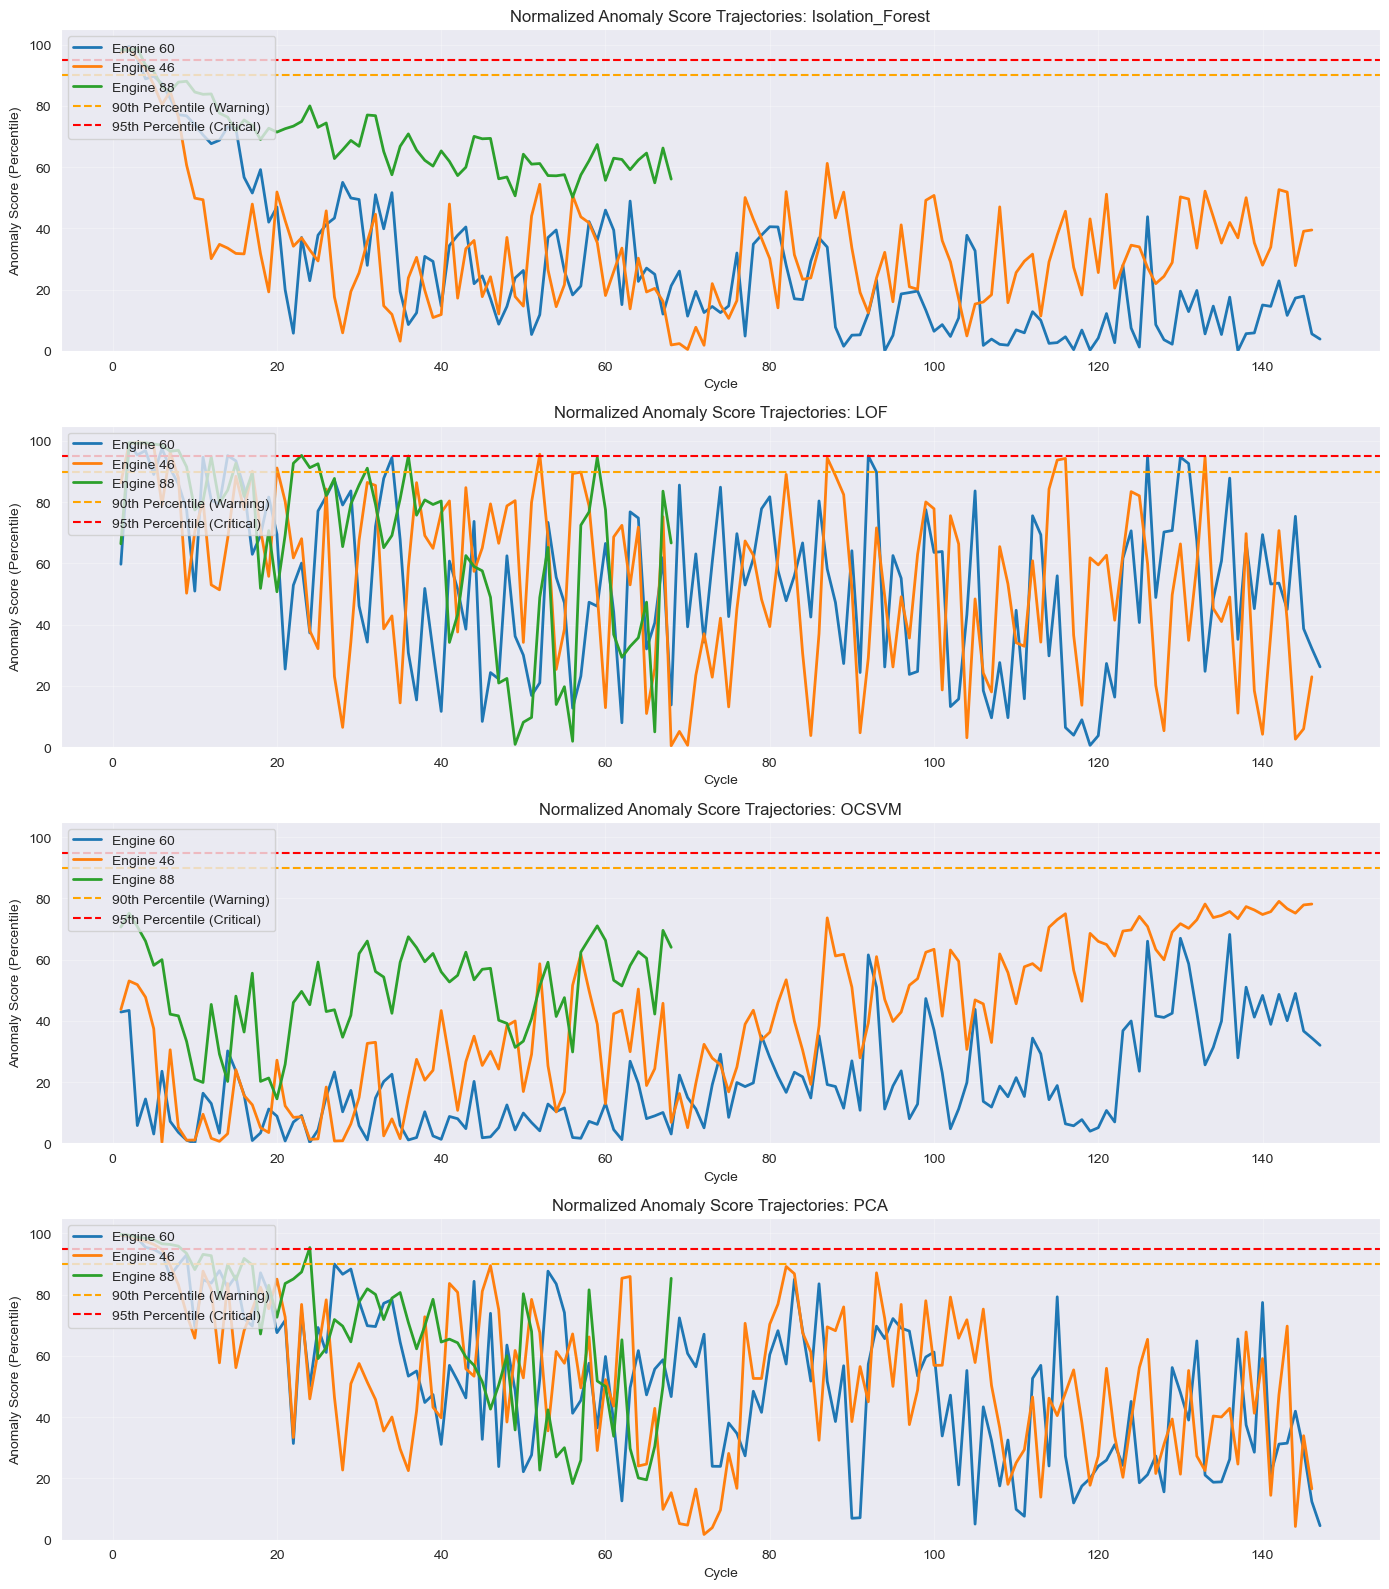

In [29]:
thresholds = [90, 95, 99]
sensitivity_results = []

for name in models_unsupervised.keys():
    for th in thresholds:
        val_predictions = (pct_scores_val[name] >= th).astype(int)
        
        true_anomalies = (baseline_val['RUL'] <= 50)
        false_anomalies = (baseline_val['RUL'] > 150)
        
        true_alarms = np.sum((val_predictions == 1) & true_anomalies)
        total_true_conditions = np.sum(true_anomalies)
        true_alarm_rate = true_alarms / total_true_conditions if total_true_conditions > 0 else 0
        
        false_alarms = np.sum((val_predictions == 1) & false_anomalies)
        total_false_conditions = np.sum(false_anomalies)
        false_alarm_rate = false_alarms / total_false_conditions if total_false_conditions > 0 else 0
        
        sensitivity_results.append({
            'Model': name,
            'Percentile Threshold': th,
            'True Alarm Rate (RUL<=50)': round(true_alarm_rate * 100, 2),
            'False Alarm Rate (RUL>150)': round(false_alarm_rate * 100, 2)
        })

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df)

sample_engines = np.random.choice(test_engines_official, size=3, replace=False)

fig, axes = plt.subplots(len(models_unsupervised), 1, figsize=(14, 16), sharex=False)

for i, (name, _) in enumerate(models_unsupervised.items()):
    for engine in sample_engines:
        engine_mask = baseline_test_official['engine_id'] == engine
        cycles = baseline_test_official.loc[engine_mask, 'cycle'].values
        scores = baseline_test_official.loc[engine_mask, f'{name}_Anomaly_Score'].values
        
        axes[i].plot(cycles, scores, label=f'Engine {engine}', linewidth=2)
        
    axes[i].axhline(90, color='orange', linestyle='--', label='90th Percentile (Warning)')
    axes[i].axhline(95, color='red', linestyle='--', label='95th Percentile (Critical)')
    axes[i].set_title(f'Normalized Anomaly Score Trajectories: {name}')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Anomaly Score (Percentile)')
    axes[i].set_ylim(0, 105)
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('anomaly_score_trajectories.png', dpi=300)
plt.close()

# Task 6

In [30]:
h_target = 30
th_xgb = tuned_thresholds[30]['XGBoost']

test_eval = baseline_test_official.copy()
test_eval['prob_h30'] = calibrated_models[30]['XGBoost'].predict_proba(X_test_cls)[:, 1]

test_eval['raw_alert'] = (
    (test_eval['prob_h30'] >= th_xgb) | 
    (test_eval['OCSVM_Anomaly_Score'] >= 95)
).astype(int)

def persistent_rule(series, window=5, min_alerts=3):
    return (series.rolling(window=window, min_periods=1).sum() >= min_alerts).astype(int)

test_eval['persistent_alert'] = test_eval.groupby('engine_id')['raw_alert'].transform(persistent_rule)

In [31]:
c_miss = 10
c_late = 5
c_early = 1

if 'h_target' not in globals():
    h_target = 30 

alert_metrics = []

for engine in test_eval['engine_id'].unique():
    engine_data = test_eval[test_eval['engine_id'] == engine].sort_values('cycle')
    
    T_i = engine_data['cycle'].iloc[-1] + engine_data['RUL'].iloc[-1]
    min_rul = engine_data['RUL'].min()
    
    is_truly_critical = (min_rul <= h_target)
    
    alerts = engine_data[engine_data['persistent_alert'] == 1]
    
    if len(alerts) > 0:
        tau_i = alerts['cycle'].iloc[0]
        L_i = T_i - tau_i
        late_delay = max(0, h_target - L_i)
        early_burden = max(0, L_i - h_target)
        miss = 0
        cost = (late_delay * c_late) + (early_burden * c_early)
    else:
        tau_i = np.nan
        L_i = np.nan
        late_delay = np.nan
        early_burden = np.nan
        
        if is_truly_critical:
            miss = 1
            cost = c_miss * h_target 
        else:
            miss = 0
            cost = 0
        
    alert_metrics.append({
        'engine_id': engine,
        'T_i': T_i,
        'tau_i': tau_i,
        'L_i': L_i,
        'Late_Delay': late_delay,
        'Early_Burden': early_burden,
        'Miss': miss,
        'Total_Cost': cost,
        'is_critical': int(is_truly_critical)
    })

metrics_df = pd.DataFrame(alert_metrics)

critical_engines_df = metrics_df[metrics_df['is_critical'] == 1]
real_miss_rate = (critical_engines_df['Miss'].sum() / len(critical_engines_df) * 100) if len(critical_engines_df) > 0 else 0.0

summary_metrics = {
    'Miss Rate (Critical Engines) (%)': real_miss_rate,
    'Avg Lead Time (Cycles)': metrics_df['L_i'].mean(),
    'Avg Late Delay (Cycles)': metrics_df['Late_Delay'].fillna(0).mean(),
    'Avg Early Burden (Cycles)': metrics_df['Early_Burden'].fillna(0).mean(),
    'Avg Total Cost': metrics_df['Total_Cost'].mean()
}

print(pd.Series(summary_metrics))

total_engines = len(test_eval['engine_id'].unique())
critical_count = len(critical_engines_df)
engines_with_alerts = sum(1 for engine in test_eval['engine_id'].unique() if len(test_eval[(test_eval['engine_id'] == engine) & (test_eval['persistent_alert'] == 1)]) > 0)

print(f"Number of All Test Engines: {total_engines}")
print(f"Number of Critical Situation Engines (Min RUL <= {h_target}): {critical_count}")
print(f"Number of Engines That Got at Least one Warning: {engines_with_alerts}")

Miss Rate (Critical Engines) (%)     0.000000
Avg Lead Time (Cycles)              33.807692
Avg Late Delay (Cycles)              0.170000
Avg Early Burden (Cycles)            1.160000
Avg Total Cost                       2.010000
dtype: float64
Number of All Test Engines: 100
Number of Critical Situation Engines (Min RUL <= 30): 25
Number of Engines That Got at Least one Warning: 26


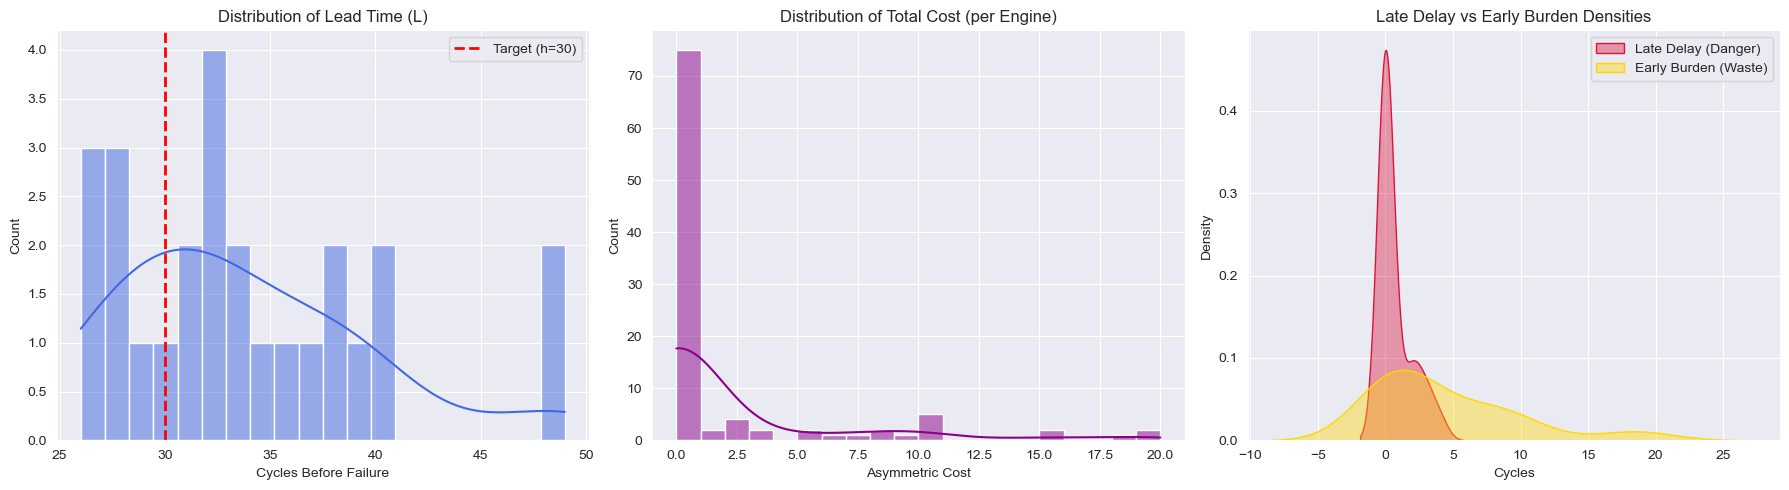

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

valid_L = metrics_df['L_i'].dropna()
sns.histplot(valid_L, bins=20, kde=True, ax=axes[0], color='royalblue')
axes[0].axvline(h_target, color='red', linestyle='--', linewidth=2, label=f'Target (h={h_target})')
axes[0].set_title('Distribution of Lead Time (L)')
axes[0].set_xlabel('Cycles Before Failure')
axes[0].legend()

sns.histplot(metrics_df['Total_Cost'], bins=20, kde=True, ax=axes[1], color='darkmagenta')
axes[1].set_title('Distribution of Total Cost (per Engine)')
axes[1].set_xlabel('Asymmetric Cost')

sns.kdeplot(metrics_df['Late_Delay'].dropna(), ax=axes[2], color='crimson', label='Late Delay (Danger)', fill=True, alpha=0.4)
sns.kdeplot(metrics_df['Early_Burden'].dropna(), ax=axes[2], color='gold', label='Early Burden (Waste)', fill=True, alpha=0.4)
axes[2].set_title('Late Delay vs Early Burden Densities')
axes[2].set_xlabel('Cycles')
axes[2].legend()

plt.tight_layout()
plt.show()
plt.savefig('early_warning_metrics_distribution.png', dpi=300)
plt.close()

# Task 7

In [33]:
empirical_coverage = np.mean((y_test_eval >= lower_bounds) & (y_test_eval <= upper_bounds))
mean_interval_width = np.mean(upper_bounds - lower_bounds)

rul_uncertainty_report = pd.DataFrame({
    'Metric': ['Target Confidence Level', 'Overall Empirical Coverage (Test)', 'Overall Mean Interval Width (Cycles)'],
    'Value': ['95.00%', f"{empirical_coverage * 100:.2f}%", f"{mean_interval_width:.2f}"]
})

print("--- Overall 3-Region RUL Uncertainty (Conformal Prediction) ---")
print(rul_uncertainty_report.to_string(index=False))
print("\n" + "="*60 + "\n")

regions = {
    'Critical (RUL <= 50)': y_test_eval <= 50,
    'Medium (50 < RUL <= 100)': (y_test_eval > 50) & (y_test_eval <= 100),
    'Healthy (RUL > 100)': y_test_eval > 100
}

region_metrics = []
for reg_name, mask in regions.items():
    if np.sum(mask) > 0:
        reg_cov = np.mean((y_test_eval[mask] >= lower_bounds[mask]) & (y_test_eval[mask] <= upper_bounds[mask]))
        reg_width = np.mean(upper_bounds[mask] - lower_bounds[mask])
        region_metrics.append({
            'Region': reg_name,
            'Sample Count': int(np.sum(mask)),
            'Coverage (%)': round(reg_cov * 100, 2),
            'Mean Width (Cycles)': round(reg_width, 2)
        })

df_region_metrics = pd.DataFrame(region_metrics)
print("--- Region-wise Conformal Prediction Performance ---")
display(df_region_metrics)

--- Overall 3-Region RUL Uncertainty (Conformal Prediction) ---
                              Metric  Value
             Target Confidence Level 95.00%
   Overall Empirical Coverage (Test) 95.46%
Overall Mean Interval Width (Cycles)  45.02


--- Region-wise Conformal Prediction Performance ---


,Region,Sample Count,Coverage (%),Mean Width (Cycles)
0,Critical (RUL <= 50),886,93.45,26.08
1,Medium (50 < RUL <= 100),2308,83.88,49.12
2,Healthy (RUL > 100),9902,98.34,45.76


In [34]:
h = 30 
y_test_true_cls = y_test_cls[h]

uncalib_prob = models_cls[h]['XGBoost'].predict_proba(X_test_cls)[:, 1]
brier_uncalib = brier_score_loss(y_test_true_cls, uncalib_prob)

calib_prob = calibrated_models[h]['XGBoost'].predict_proba(X_test_cls)[:, 1]
brier_calib = brier_score_loss(y_test_true_cls, calib_prob)

cls_uncertainty_report = pd.DataFrame({
    'Model State (Horizon 30)': ['XGBoost (Uncalibrated)', 'XGBoost (Isotonic Calibrated)'],
    'Brier Score': [round(brier_uncalib, 4), round(brier_calib, 4)]
})
print("\n--- Classification Uncertainty (Calibration) ---")
print(cls_uncertainty_report.to_string(index=False))


--- Classification Uncertainty (Calibration) ---
     Model State (Horizon 30)  Brier Score
       XGBoost (Uncalibrated)       0.0053
XGBoost (Isotonic Calibrated)       0.0050


In [35]:
def format_anomaly_output(raw_score, percentile_score):
    if percentile_score >= 99:
        status = "CRITICAL"
    elif percentile_score >= 95:
        status = "WARNING"
    elif percentile_score >= 90:
        status = "ELEVATED"
    else:
        status = "NORMAL"
        
    return f"Status: {status} | Score: {percentile_score:.1f}th percentile (Raw: {raw_score:.3f})"

sample_percentile = pct_scores_test['OCSVM'][100] 
sample_raw = raw_scores_val['OCSVM'][100] 

print("\n--- Anomaly Detection Uncertainty ---")
print(format_anomaly_output(sample_raw, sample_percentile))


--- Anomaly Detection Uncertainty ---
Status: NORMAL | Score: 4.8th percentile (Raw: -5.877)


In [36]:
def generate_uncertainty_aware_alert(engine_id, cycle, rul_pred, rul_lower, rul_upper, calib_prob, anomaly_pct, h_target=30):
    
    interval_width = rul_upper - rul_lower
    
    report = f"Engine ID: {engine_id} | Current Cycle: {cycle}\n"
    report += "-"*50 + "\n"
    report += f"1. RUL Estimate: {rul_pred:.0f} cycles (95% CI: [{rul_lower:.0f}, {rul_upper:.0f}])\n"
    report += f"2. Failure Probability (Next {h_target} cycles): {calib_prob*100:.1f}% (Calibrated)\n"
    report += f"3. Anomaly Sensor Margin: {anomaly_pct:.1f}th Percentile\n"
    report += "-"*50 + "\n"
    
    if (calib_prob > 0.8) and (anomaly_pct > 95):
        report += "RECOMMENDATION: IMMEDIATE STOP / MAINTENANCE REQUIRED.\n"
        report += "Reasoning: High probability of failure with corroborating critical anomaly scores."
    elif (rul_lower < h_target) and (interval_width > 50):
        report += "RECOMMENDATION: SCHEDULE INSPECTION (DO NOT STOP YET).\n"
        report += "Reasoning: Lower bound of RUL intersects critical horizon, but model uncertainty (interval width) is too high to justify an immediate operational halt."
    elif (calib_prob > 0.3) or (anomaly_pct > 90):
        report += "RECOMMENDATION: INCREASE MONITORING FREQUENCY.\n"
        report += "Reasoning: Early warning signs detected. Uncertainty bounds do not yet mandate physical intervention."
    else:
        report += "RECOMMENDATION: NORMAL OPERATION.\n"
        report += "Reasoning: All systems operating within historical normal distributions."
        
    return report

sample_idx = len(baseline_test_official) - 15 
eng_id = baseline_test_official.iloc[sample_idx]['engine_id']
cyc = baseline_test_official.iloc[sample_idx]['cycle']

print("\n--- Uncertainty-Aware Recommendation System ---")
print(generate_uncertainty_aware_alert(
    engine_id=eng_id,
    cycle=cyc,
    rul_pred=preds_test_rul[sample_idx],
    rul_lower=lower_bounds[sample_idx],
    rul_upper=upper_bounds[sample_idx],
    calib_prob=calib_prob[sample_idx],
    anomaly_pct=pct_scores_test['OCSVM'][sample_idx]
))


--- Uncertainty-Aware Recommendation System ---
Engine ID: 100.0 | Current Cycle: 184.0
--------------------------------------------------
1. RUL Estimate: 41 cycles (95% CI: [31, 52])
2. Failure Probability (Next 30 cycles): 53.3% (Calibrated)
3. Anomaly Sensor Margin: 87.1th Percentile
--------------------------------------------------
RECOMMENDATION: INCREASE MONITORING FREQUENCY.
Reasoning: Early warning signs detected. Uncertainty bounds do not yet mandate physical intervention.


# Stage 2

--- FD002 Regime-Specific Scaling ---
Number of samples per operational regime (Cluster sizes):
regime
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64

Number of fitted scalers successfully saved: 6


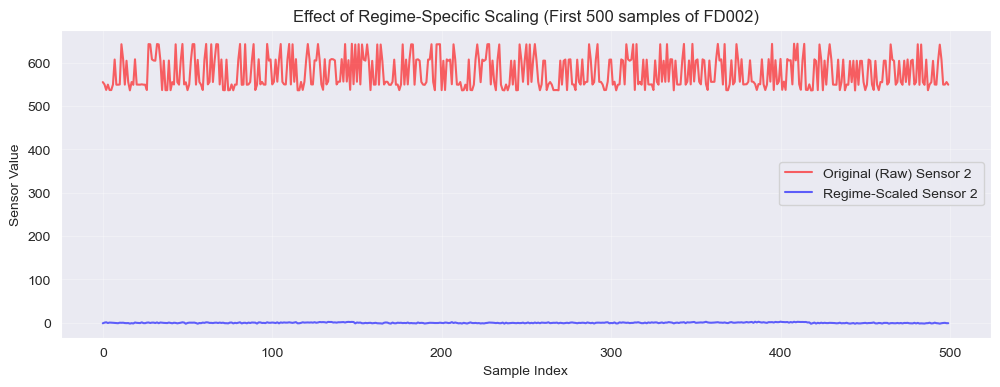

In [37]:
train_fd002, test_fd002_raw, rul_fd002 = load_cmapss_data('train_FD002.txt', 'test_FD002.txt', 'RUL_FD002.txt')

kmeans_fd002 = KMeans(n_clusters=6, random_state=42, n_init=10)
train_fd002['regime'] = kmeans_fd002.fit_predict(train_fd002[['op_setting_1', 'op_setting_2', 'op_setting_3']])
test_fd002_raw['regime'] = kmeans_fd002.predict(test_fd002_raw[['op_setting_1', 'op_setting_2', 'op_setting_3']])

scalers_dict = {}
train_fd002_scaled = train_fd002.copy()
test_fd002 = test_fd002_raw.copy()
sensor_cols_002 = [f'sensor_{i}' for i in range(1, 22)]

for r in range(6):
    regime_data = train_fd002[train_fd002['regime'] == r]
    if len(regime_data) > 0:
        scaler_r = StandardScaler()
        train_fd002_scaled.loc[train_fd002['regime'] == r, sensor_cols_002] = scaler_r.fit_transform(regime_data[sensor_cols_002])
        scalers_dict[r] = scaler_r
        
        regime_mask_test = test_fd002['regime'] == r
        if regime_mask_test.sum() > 0:
            test_fd002.loc[regime_mask_test, sensor_cols_002] = scaler_r.transform(test_fd002.loc[regime_mask_test, sensor_cols_002])

print("--- FD002 Regime-Specific Scaling ---")
print("Number of samples per operational regime (Cluster sizes):")
print(train_fd002['regime'].value_counts().sort_index())
print(f"\nNumber of fitted scalers successfully saved: {len(scalers_dict)}")

plt.figure(figsize=(12, 4))
plt.plot(train_fd002['sensor_2'][:500], alpha=0.6, label='Original (Raw) Sensor 2', color='red')
plt.plot(train_fd002_scaled['sensor_2'][:500], alpha=0.6, label='Regime-Scaled Sensor 2', color='blue')
plt.title("Effect of Regime-Specific Scaling (First 500 samples of FD002)")
plt.xlabel("Sample Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig('effect_of_regime_specific_scaling.png', dpi=300)
plt.close()

In [38]:
train_engines_fd002 = train_fd002['engine_id'].unique()
np.random.seed(42)
shuffled = np.random.permutation(train_engines_fd002)
n_train = int(0.6 * len(shuffled))
n_val = int(0.2 * len(shuffled))
train_engines_fd002_set = shuffled[:n_train]
val_engines_fd002_set = shuffled[n_train:n_train+n_val]
test_engines_fd002_set = shuffled[n_train+n_val:]

train_data_fd002 = train_fd002[train_fd002['engine_id'].isin(train_engines_fd002_set)].copy()
val_data_fd002 = train_fd002[train_fd002['engine_id'].isin(val_engines_fd002_set)].copy()
test_data_fd002 = train_fd002[train_fd002['engine_id'].isin(test_engines_fd002_set)].copy()

for df in [train_data_fd002, val_data_fd002, test_data_fd002]:
    df['regime'] = kmeans_fd002.predict(df[['op_setting_1', 'op_setting_2', 'op_setting_3']])

scaler_dict_fd002 = {}
sensor_cols_002 = [f'sensor_{i}' for i in range(1, 22)]
for r in range(6):
    regime_data = train_data_fd002[train_data_fd002['regime'] == r]
    if len(regime_data) > 0:
        scaler_r = StandardScaler()
        regime_data_scaled = scaler_r.fit_transform(regime_data[sensor_cols_002])
        train_data_fd002.loc[train_data_fd002['regime'] == r, sensor_cols_002] = regime_data_scaled
        scaler_dict_fd002[r] = scaler_r

for df in [val_data_fd002, test_data_fd002]:
    for r in range(6):
        regime_mask = df['regime'] == r
        if regime_mask.sum() > 0 and r in scaler_dict_fd002:
            df.loc[regime_mask, sensor_cols_002] = scaler_dict_fd002[r].transform(df.loc[regime_mask, sensor_cols_002])

print("--- Engine Split Statistics - FD002: ---")
print(f"Total Train Engines: {len(train_engines_fd002)}")
print(f"Train Split: {len(train_engines_fd002_set)} engines ({len(train_data_fd002)} rows)")
print(f"Validation Split: {len(val_engines_fd002_set)} engines ({len(val_data_fd002)} rows)")
print(f"Test Split: {len(test_engines_fd002_set)} engines ({len(test_data_fd002)} rows)")
print("\nRegime Distribution - Train:")
print(train_data_fd002['regime'].value_counts().sort_index())

--- Engine Split Statistics - FD002: ---
Total Train Engines: 260
Train Split: 156 engines (31871 rows)
Validation Split: 52 engines (11018 rows)
Test Split: 52 engines (10870 rows)

Regime Distribution - Train:
regime
0    7944
1    4827
2    4734
3    4758
4    4823
5    4785
Name: count, dtype: int64


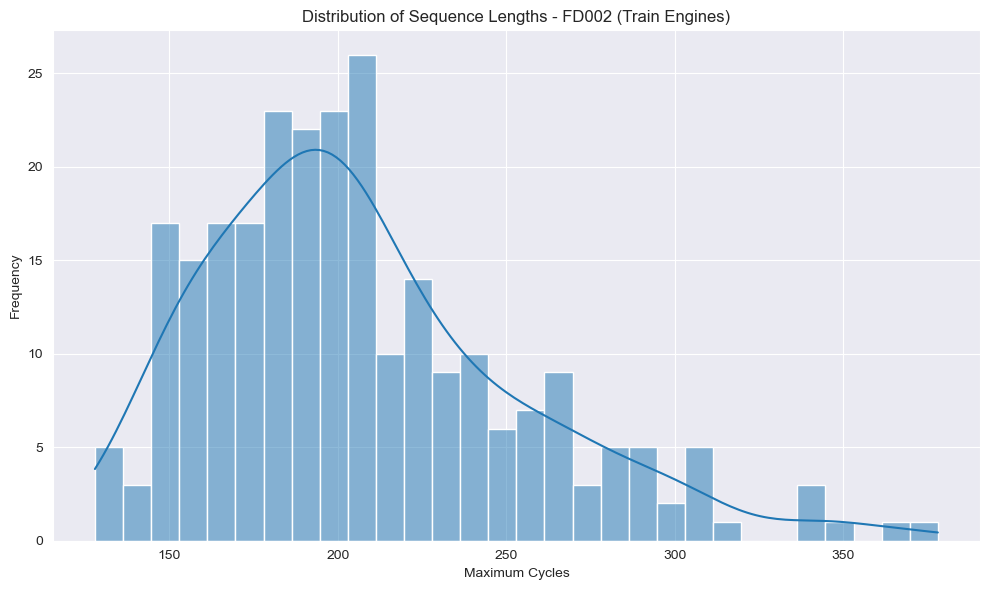

--- FD002 EDA Results: ---
Total Engines: 260
Total Rows: 53759
Missing Values: 0
Infinite Values: 0
Cycle Continuity: True
Duplicate Keys: 0

Dropped Sensors (Variance < 1e-5): []
Number of Dropped Sensors: 0


In [39]:
total_engines_fd002 = len(train_fd002['engine_id'].unique())
total_rows_fd002 = len(train_fd002)
missing_values_fd002 = train_fd002.isnull().sum().sum()
infinite_values_fd002 = np.isinf(train_fd002.drop(['engine_id', 'cycle'], axis=1)).sum().sum()
cycle_diff_fd002 = train_fd002.groupby('engine_id')['cycle'].diff().dropna()
continuity_check_fd002 = (cycle_diff_fd002 == 1.0).all()
duplicate_keys_fd002 = train_fd002.duplicated(subset=['engine_id', 'cycle']).sum()

plt.figure(figsize=(10, 6))
sns.histplot(train_fd002.groupby('engine_id')['cycle'].max(), bins=30, kde=True)
plt.title('Distribution of Sequence Lengths - FD002 (Train Engines)')
plt.xlabel('Maximum Cycles')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
plt.savefig('sequence_length_distribution_fd002.png', dpi=300)
plt.close()

variances_fd002 = train_fd002[sensor_cols_002].var()
flatline_sensors_fd002 = variances_fd002[variances_fd002 < 1e-5].index.tolist()

print("--- FD002 EDA Results: ---")
print(f"Total Engines: {total_engines_fd002}")
print(f"Total Rows: {total_rows_fd002}")
print(f"Missing Values: {missing_values_fd002}")
print(f"Infinite Values: {infinite_values_fd002}")
print(f"Cycle Continuity: {continuity_check_fd002}")
print(f"Duplicate Keys: {duplicate_keys_fd002}")
print(f"\nDropped Sensors (Variance < 1e-5): {flatline_sensors_fd002}")
print(f"Number of Dropped Sensors: {len(flatline_sensors_fd002)}")

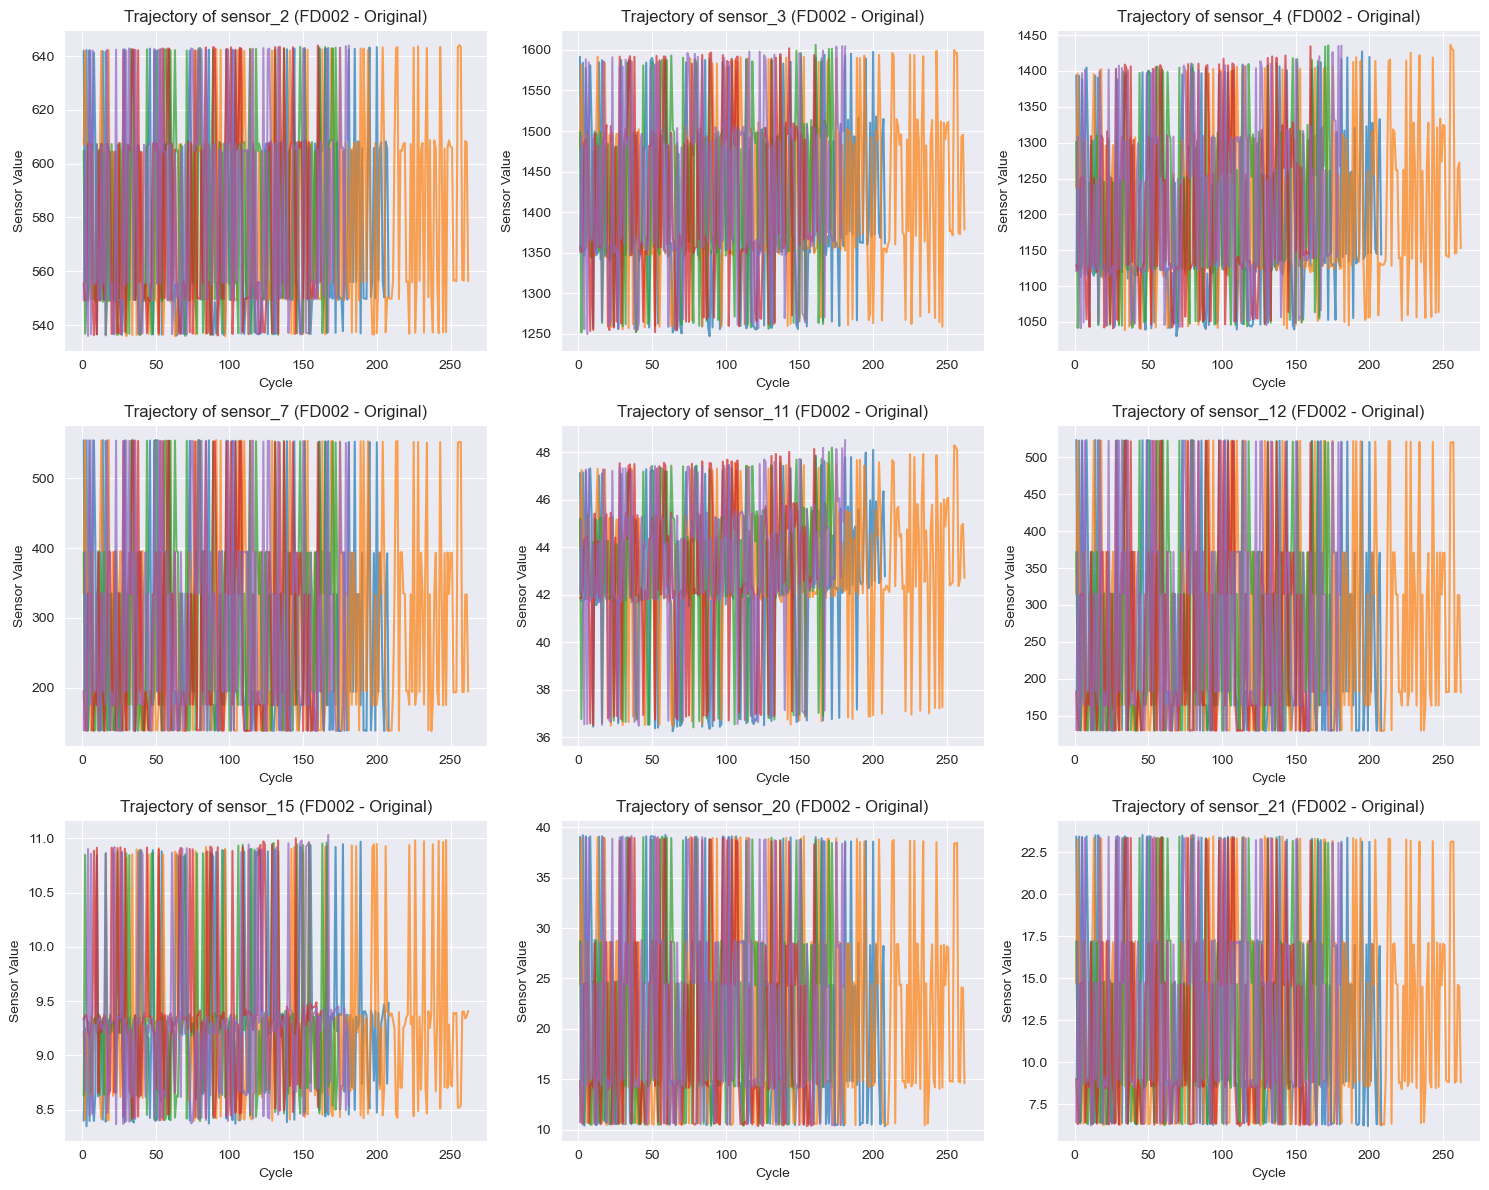

--- FD002 Operating Regime Analysis: ---
Number of regimes identified: 6

Regime distribution:
regime
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64

Engines per regime:
regime
0    260
1    260
2    260
3    260
4    260
5    260
Name: engine_id, dtype: int64


In [40]:
key_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15', 'sensor_20', 'sensor_21']
sample_engines_fd002 = np.random.choice(train_fd002['engine_id'].unique(), size=5, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, sensor in enumerate(key_sensors):
    for engine in sample_engines_fd002:
        engine_data = train_fd002[train_fd002['engine_id'] == engine]
        axes[i].plot(engine_data['cycle'], engine_data[sensor], alpha=0.7)
    axes[i].set_title(f'Trajectory of {sensor} (FD002 - Original)')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Sensor Value')
plt.tight_layout()
plt.show()
plt.savefig('trajectories_original_scale_fd002.png', dpi=300)
plt.close()

regime_counts = train_fd002.groupby(['engine_id', 'regime']).size().reset_index(name='count')
regime_per_engine = regime_counts.groupby('engine_id')['regime'].nunique()
print("--- FD002 Operating Regime Analysis: ---")
print(f"Number of regimes identified: 6")
print(f"\nRegime distribution:")
print(train_fd002['regime'].value_counts().sort_index())
print(f"\nEngines per regime:")
print(regime_counts.groupby('regime')['engine_id'].nunique())

In [41]:
op_settings_fd002 = ['op_setting_1', 'op_setting_2', 'op_setting_3']
active_sensors_fd002 = [col for col in sensor_cols_002 if col not in flatline_sensors_fd002]
features_to_scale_fd002 = op_settings_fd002 + active_sensors_fd002

train_fe_fd002 = train_data_fd002.drop(columns=flatline_sensors_fd002)
val_fe_fd002 = val_data_fd002.drop(columns=flatline_sensors_fd002)
test_fe_fd002 = test_data_fd002.drop(columns=flatline_sensors_fd002)

scaler_global_fd002 = StandardScaler()
train_fe_fd002[op_settings_fd002] = scaler_global_fd002.fit_transform(train_fe_fd002[op_settings_fd002])
val_fe_fd002[op_settings_fd002] = scaler_global_fd002.transform(val_fe_fd002[op_settings_fd002])
test_fe_fd002[op_settings_fd002] = scaler_global_fd002.transform(test_fe_fd002[op_settings_fd002])

print("--- FD002 Feature Engineering - Scaling Results: ---")
print(f"Train shape after preprocessing: {train_fe_fd002.shape}")
print(f"Active sensors: {len(active_sensors_fd002)} sensors kept")
print(f"Dropped sensors: {len(flatline_sensors_fd002)} sensors removed")

--- FD002 Feature Engineering - Scaling Results: ---
Train shape after preprocessing: (31871, 27)
Active sensors: 21 sensors kept
Dropped sensors: 0 sensors removed


In [42]:
window_sizes_fd002 = [10, 20, 50, 100, 150]

def calculate_slope_fd002(y):
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0]

def extract_multi_window_features_fd002(df, window_sizes, feature_cols):
    df_out = df.copy()
    grouped = df_out.groupby('engine_id')
    
    for W in window_sizes:
        for col in feature_cols:
            rolling_obj = grouped[col].rolling(window=W, min_periods=1)
            
            df_out[f'{col}_roll_mean_W{W}'] = rolling_obj.mean().reset_index(level=0, drop=True)
            df_out[f'{col}_roll_std_W{W}'] = rolling_obj.std().reset_index(level=0, drop=True).fillna(0)
            df_out[f'{col}_roll_min_W{W}'] = rolling_obj.min().reset_index(level=0, drop=True)
            df_out[f'{col}_roll_max_W{W}'] = rolling_obj.max().reset_index(level=0, drop=True)
            
            slope_col = grouped[col].rolling(window=W, min_periods=2).apply(calculate_slope_fd002, raw=True)
            df_out[f'{col}_slope_W{W}'] = slope_col.reset_index(level=0, drop=True).fillna(0)
    
    return df_out

train_window_fd002 = extract_multi_window_features_fd002(train_fe_fd002, window_sizes_fd002, active_sensors_fd002)
val_window_fd002 = extract_multi_window_features_fd002(val_fe_fd002, window_sizes_fd002, active_sensors_fd002)
test_window_fd002 = extract_multi_window_features_fd002(test_fe_fd002, window_sizes_fd002, active_sensors_fd002)

print(f"--- FD002 Window Features Created: ---")
print(f"Window sizes used: {window_sizes_fd002}")
print(f"Train shape: {train_window_fd002.shape}")
print(f"Validation shape: {val_window_fd002.shape}")
print(f"Test shape: {test_window_fd002.shape}")

--- FD002 Window Features Created: ---
Window sizes used: [10, 20, 50, 100, 150]
Train shape: (31871, 552)
Validation shape: (11018, 552)
Test shape: (10870, 552)


In [43]:
def verify_causality_fd002(df, window_sizes, feature_cols):
    sample_engine = df[df['engine_id'] == df['engine_id'].iloc[0]].copy()
    
    res_original = extract_multi_window_features_fd002(sample_engine, window_sizes, feature_cols)
    
    target_idx = len(sample_engine) // 2
    future_idx = target_idx + 1
    
    for col in feature_cols:
        sample_engine.iloc[future_idx, sample_engine.columns.get_loc(col)] += 999.0
        
    res_modified = extract_multi_window_features_fd002(sample_engine, window_sizes, feature_cols)
    
    orig_cols = [c for c in res_original.columns if c not in ['engine_id', 'cycle', 'regime']]
    mod_cols = [c for c in res_modified.columns if c not in ['engine_id', 'cycle', 'regime']]
    
    orig_row = res_original.iloc[target_idx][orig_cols]
    mod_row = res_modified.iloc[target_idx][mod_cols]
    
    return orig_row.equals(mod_row)

causality_passed_fd002 = verify_causality_fd002(train_fe_fd002, window_sizes_fd002, active_sensors_fd002)
print("--- FD002 Causality Verification ---")
print(f"Causality test passed: {causality_passed_fd002}")

--- FD002 Causality Verification ---
Causality test passed: True


In [44]:
rul_threshold_fd002 = 125

max_cycle_train_fd002 = train_fe_fd002.groupby('engine_id')['cycle'].transform('max')
train_fe_fd002['RUL'] = max_cycle_train_fd002 - train_fe_fd002['cycle']
train_fe_fd002['RUL_capped'] = train_fe_fd002['RUL'].clip(upper=rul_threshold_fd002)

max_cycle_val_fd002 = val_fe_fd002.groupby('engine_id')['cycle'].transform('max')
val_fe_fd002['RUL'] = max_cycle_val_fd002 - val_fe_fd002['cycle']
val_fe_fd002['RUL_capped'] = val_fe_fd002['RUL'].clip(upper=rul_threshold_fd002)

test_engines_official_fd002 = test_fd002['engine_id'].unique()
rul_mapping_fd002 = {engine: rul_fd002.iloc[i, 0] for i, engine in enumerate(test_engines_official_fd002)}

test_fd002_final = test_fd002.copy()
test_max_cycle_fd002 = test_fd002_final.groupby('engine_id')['cycle'].max().to_dict()
test_fd002_final['max_cycle'] = test_fd002_final['engine_id'].map(test_max_cycle_fd002)
test_fd002_final['RUL_final'] = test_fd002_final['engine_id'].map(rul_mapping_fd002)
test_fd002_final['RUL'] = test_fd002_final['max_cycle'] - test_fd002_final['cycle'] + test_fd002_final['RUL_final']
test_fd002_final['RUL_capped'] = test_fd002_final['RUL'].clip(upper=rul_threshold_fd002)

test_fe_fd002 = test_fd002_final.drop(columns=flatline_sensors_fd002)
test_fe_fd002[op_settings_fd002] = scaler_global_fd002.transform(test_fe_fd002[op_settings_fd002])

train_window_fd002 = extract_multi_window_features_fd002(train_fe_fd002, window_sizes_fd002, active_sensors_fd002)
val_window_fd002 = extract_multi_window_features_fd002(val_fe_fd002, window_sizes_fd002, active_sensors_fd002)
test_window_fd002 = extract_multi_window_features_fd002(test_fe_fd002, window_sizes_fd002, active_sensors_fd002)

train_window_fd002['RUL'] = train_fe_fd002['RUL']
train_window_fd002['RUL_capped'] = train_fe_fd002['RUL_capped']
val_window_fd002['RUL'] = val_fe_fd002['RUL']
val_window_fd002['RUL_capped'] = val_fe_fd002['RUL_capped']
test_window_fd002['RUL'] = test_fe_fd002['RUL']
test_window_fd002['RUL_capped'] = test_fe_fd002['RUL_capped']

y_train_rul_fd002 = train_fe_fd002['RUL_capped'].values
y_val_rul_fd002 = val_fe_fd002['RUL_capped'].values
y_test_rul_fd002 = test_fe_fd002['RUL_capped'].values

print("--- FD002 RUL Labels Created ---")
print(f"Train RUL range: [{train_fe_fd002['RUL'].min():.0f}, {train_fe_fd002['RUL'].max():.0f}]")
print(f"Train capped RUL range: [{train_fe_fd002['RUL_capped'].min():.0f}, {train_fe_fd002['RUL_capped'].max():.0f}]")
print(f"Validation RUL range: [{val_fe_fd002['RUL'].min():.0f}, {val_fe_fd002['RUL'].max():.0f}]")
print(f"Test RUL range: [{test_fe_fd002['RUL'].min():.0f}, {test_fe_fd002['RUL'].max():.0f}]")
print(f"Number of critical engines in Test (RUL<=30): {test_fe_fd002.groupby('engine_id')['RUL'].min().le(30).sum()} out of {test_fe_fd002['engine_id'].nunique()}")

--- FD002 RUL Labels Created ---
Train RUL range: [0, 377]
Train capped RUL range: [0, 125]
Validation RUL range: [0, 287]
Test RUL range: [6, 377]
Number of critical engines in Test (RUL<=30): 61 out of 259


### Saving preproccessed data for better peformance in dashboard

In [45]:
test_window_fd002.to_csv('test_window_fd002_preprocessed.csv.gz', index=False, compression='gzip')
print(f"test_window_fd002 saved: {test_window_fd002.shape}")

rul_df = pd.DataFrame({
    'engine_id': test_window_fd002['engine_id'].unique(),
    'RUL_final': [test_window_fd002[test_window_fd002['engine_id'] == e]['RUL'].iloc[-1] for e in test_window_fd002['engine_id'].unique()]
})
rul_df.to_csv('rul_final_fd002.csv.gz', index=False, compression='gzip')
print(f"rul_final_fd002 saved: {len(rul_df)} engines")

print(f"\nData Summary:")
print(f"  Total rows: {len(test_window_fd002)}")
print(f"  Total columns: {len(test_window_fd002.columns)}")
print(f"  Total features: {len(test_window_fd002.columns) - 4}")  
print(f"  Total engines: {len(rul_df)}")
print(f"  RUL range: {rul_df['RUL_final'].min()} - {rul_df['RUL_final'].max()}")

size_mb = os.path.getsize('test_window_fd002_preprocessed.csv.gz') / (1024 * 1024)
print(f"  File size: {size_mb:.2f} MB (compressed)")

test_window_fd002 saved: (33991, 556)
rul_final_fd002 saved: 259 engines

Data Summary:
  Total rows: 33991
  Total columns: 556
  Total features: 552
  Total engines: 259
  RUL range: 6 - 194
  File size: 78.00 MB (compressed)


In [46]:
X_train_base_fd002 = train_fe_fd002[features_to_scale_fd002].values
X_val_base_fd002 = val_fe_fd002[features_to_scale_fd002].values
X_test_base_fd002 = test_fe_fd002[features_to_scale_fd002].values

feature_cols_window_fd002 = [col for col in train_window_fd002.columns if col not in ['engine_id', 'cycle', 'regime', 'RUL', 'RUL_capped']]
X_train_win_fd002 = train_window_fd002[feature_cols_window_fd002].values
X_val_win_fd002 = val_window_fd002[feature_cols_window_fd002].values
X_test_win_fd002 = test_window_fd002[feature_cols_window_fd002].values

print(f"--- FD002 Data Preparation Complete: ---")
print(f"Base features: {X_train_base_fd002.shape[1]} features")
print(f"Window features: {X_train_win_fd002.shape[1]} features")
print(f"Train samples: {X_train_win_fd002.shape[0]}")
print(f"Validation samples: {X_val_win_fd002.shape[0]}")
print(f"Test samples: {X_test_win_fd002.shape[0]}")
print(f"Window sizes used: {window_sizes_fd002}")

--- FD002 Data Preparation Complete: ---
Base features: 24 features
Window features: 549 features
Train samples: 31871
Validation samples: 11018
Test samples: 33991
Window sizes used: [10, 20, 50, 100, 150]


In [47]:
ridge_fd002 = Ridge(alpha=1.0)
ridge_fd002.fit(X_train_base_fd002, y_train_rul_fd002)

poly_fd002 = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge(alpha=1.0))
])
poly_fd002.fit(X_train_base_fd002, y_train_rul_fd002)

rf_fd002 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_fd002.fit(X_train_base_fd002, y_train_rul_fd002)

xgb_base_fd002 = xgb.XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_base_fd002.fit(X_train_base_fd002, y_train_rul_fd002)

xgb_win_fd002 = xgb.XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_win_fd002.fit(X_train_win_fd002, y_train_rul_fd002)


print("--- FD002 RUL Regression Models Trained ---")
print("="*80)
print(f"{'Model':<25} {'Parameters':<55}")
print("="*80)

ridge_params = f"alpha={ridge_fd002.get_params()['alpha']}"
print(f"{'1. Ridge Regression':<25} {ridge_params:<55}")

poly_params = f"degree={poly_fd002.named_steps['poly'].degree}, alpha={poly_fd002.named_steps['ridge'].get_params()['alpha']}"
print(f"{'2. Polynomial Ridge':<25} {poly_params:<55}")

rf_params = f"n_estimators={rf_fd002.get_params()['n_estimators']}, max_depth={rf_fd002.get_params()['max_depth']}"
print(f"{'3. Random Forest':<25} {rf_params:<55}")

xgb_base_params = f"n_estimators={xgb_base_fd002.get_params()['n_estimators']}, max_depth={xgb_base_fd002.get_params()['max_depth']}, lr={xgb_base_fd002.get_params()['learning_rate']}"
print(f"{'4. XGBoost (Base)':<25} {xgb_base_params:<55}")

xgb_win_params = f"n_estimators={xgb_win_fd002.get_params()['n_estimators']}, max_depth={xgb_win_fd002.get_params()['max_depth']}, lr={xgb_win_fd002.get_params()['learning_rate']}"
print(f"{'5. XGBoost (Window)':<25} {xgb_win_params:<55}")
print("="*80)

print(f"\nFeature Counts:")
print(f"Base Features: {X_train_base_fd002.shape[1]}")
print(f"Window Features: {X_train_win_fd002.shape[1]}")

--- FD002 RUL Regression Models Trained ---
Model                     Parameters                                             
1. Ridge Regression       alpha=1.0                                              
2. Polynomial Ridge       degree=2, alpha=1.0                                    
3. Random Forest          n_estimators=100, max_depth=10                         
4. XGBoost (Base)         n_estimators=150, max_depth=6, lr=0.05                 
5. XGBoost (Window)       n_estimators=150, max_depth=6, lr=0.05                 

Feature Counts:
Base Features: 24
Window Features: 549


In [48]:
def asymmetric_cost_fd002(y_true, y_pred):
    diff = y_pred - y_true
    return np.where(diff > 0, 2 * diff, -diff).sum()

def bootstrap_rmse_ci_fd002(df_test, model, X_test, y_true_col, n_iterations=100):
    engines = df_test['engine_id'].unique()
    rmses = []
    preds = model.predict(X_test)
    df_eval = df_test.copy()
    df_eval['pred'] = preds
    for _ in range(n_iterations):
        sample_engines = np.random.choice(engines, size=len(engines), replace=True)
        sampled_data = pd.concat([df_eval[df_eval['engine_id'] == e] for e in sample_engines])
        rmse = np.sqrt(np.mean((sampled_data[y_true_col] - sampled_data['pred']) ** 2))
        rmses.append(rmse)
    return np.percentile(rmses, 2.5), np.percentile(rmses, 97.5)

models_dict_fd002 = {
    'Ridge (Base)': (ridge_fd002, X_test_base_fd002),
    'Polynomial (Base)': (poly_fd002, X_test_base_fd002),
    'Random Forest (Base)': (rf_fd002, X_test_base_fd002),
    'XGBoost (Base)': (xgb_base_fd002, X_test_base_fd002),
    'XGBoost (Window)': (xgb_win_fd002, X_test_win_fd002)
}

regions_fd002 = {
    'Near-failure': lambda y: y <= 50,
    'Mid-life': lambda y: (y > 50) & (y <= 150),
    'Early-life': lambda y: y > 150
}

results_fd002 = []
for name, (model, X_test_data) in models_dict_fd002.items():
    preds = model.predict(X_test_data)
    mae_tot = np.mean(np.abs(y_test_rul_fd002 - preds))
    rmse_tot = np.sqrt(np.mean((y_test_rul_fd002 - preds) ** 2))
    r2_tot = 1 - np.sum((y_test_rul_fd002 - preds) ** 2) / np.sum((y_test_rul_fd002 - np.mean(y_test_rul_fd002)) ** 2)
    cost_tot = asymmetric_cost_fd002(y_test_rul_fd002, preds)
    
    ci_low, ci_high = bootstrap_rmse_ci_fd002(test_window_fd002, model, X_test_data, 'RUL_capped')
    
    region_metrics = {}
    for region_name, region_mask in regions_fd002.items():
        mask = region_mask(y_test_rul_fd002)
        if mask.sum() > 0:
            y_true_region = y_test_rul_fd002[mask]
            y_pred_region = preds[mask]
            region_metrics[region_name] = {
                'MAE': np.mean(np.abs(y_true_region - y_pred_region)),
                'RMSE': np.sqrt(np.mean((y_true_region - y_pred_region) ** 2)),
                'Count': mask.sum()
            }
    
    results_fd002.append({
        'Model': name,
        'MAE': mae_tot,
        'RMSE': rmse_tot,
        'R2': r2_tot,
        'Asymmetric Cost': cost_tot,
        'RMSE 95% CI': f'[{ci_low:.2f}, {ci_high:.2f}]',
        'Near-failure RMSE': region_metrics.get('Near-failure', {}).get('RMSE', np.nan),
        'Mid-life RMSE': region_metrics.get('Mid-life', {}).get('RMSE', np.nan),
        'Early-life RMSE': region_metrics.get('Early-life', {}).get('RMSE', np.nan)
    })

results_df_fd002 = pd.DataFrame(results_fd002)
print("--- FD002 RUL Regression Results: ---")
print(results_df_fd002.to_string(index=False))

--- FD002 RUL Regression Results: ---
               Model       MAE      RMSE       R2  Asymmetric Cost    RMSE 95% CI  Near-failure RMSE  Mid-life RMSE  Early-life RMSE
        Ridge (Base) 18.060649 22.251939 0.404143    794359.482274 [21.07, 23.54]          25.364598      21.975995              NaN
   Polynomial (Base) 16.328815 23.910084 0.312031    726186.814289 [20.03, 28.15]          51.879301      19.928440              NaN
Random Forest (Base) 14.876818 19.181730 0.557226    646163.931323 [18.32, 20.17]          23.813510      18.749413              NaN
      XGBoost (Base) 14.422879 19.007386 0.565238    630256.425512 [17.92, 20.31]          23.317022      18.608090              NaN
    XGBoost (Window)  8.114360 11.592835 0.838272    374142.035588 [10.74, 12.13]           9.378767      11.756583              NaN


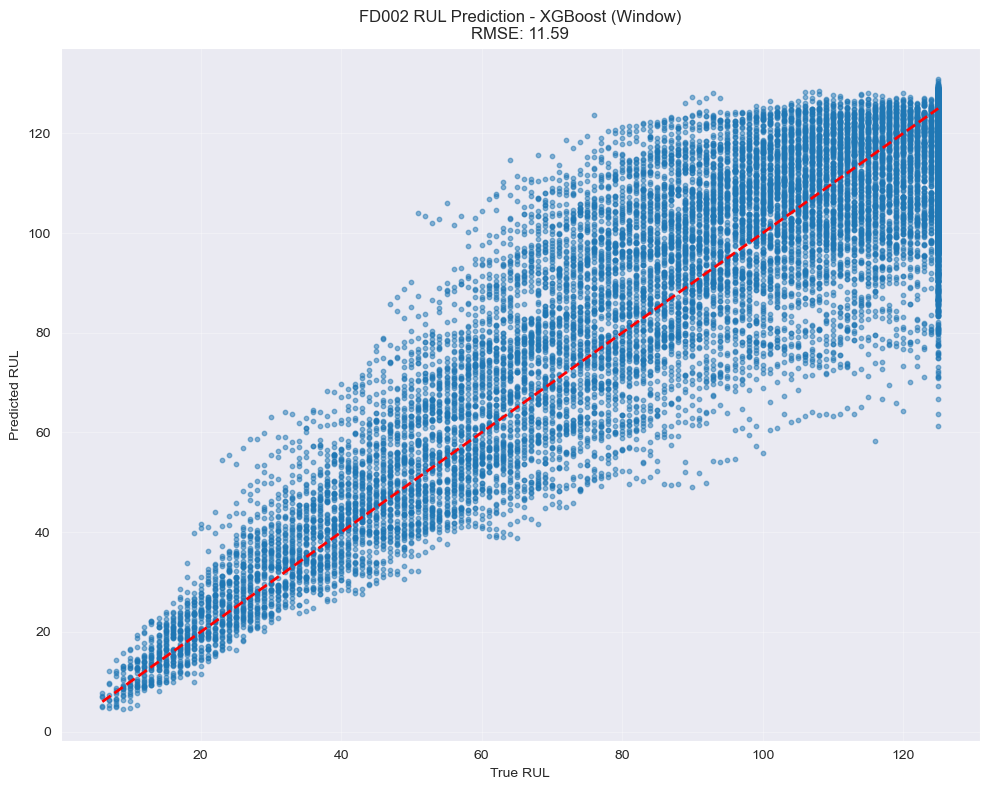

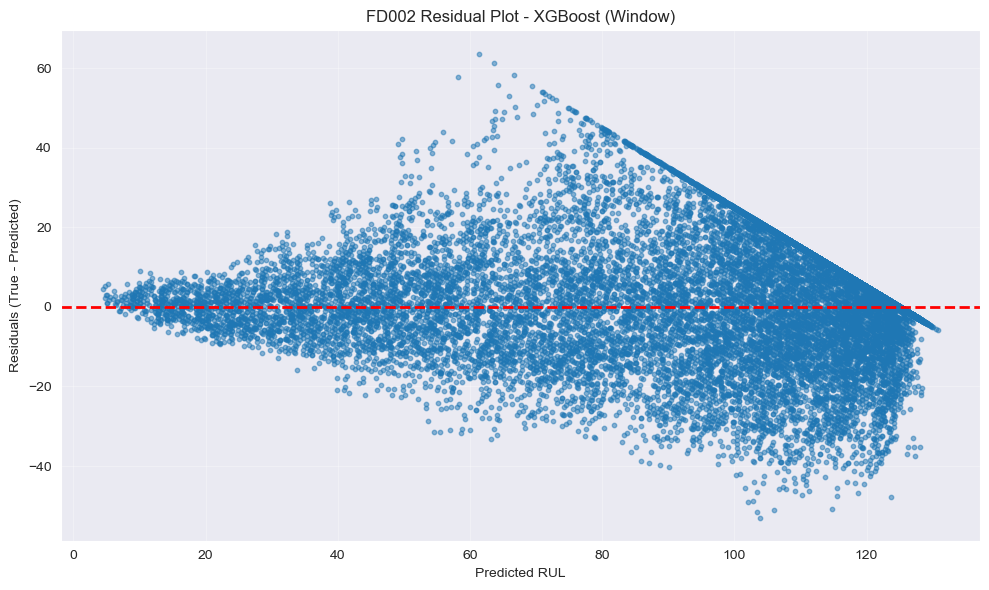

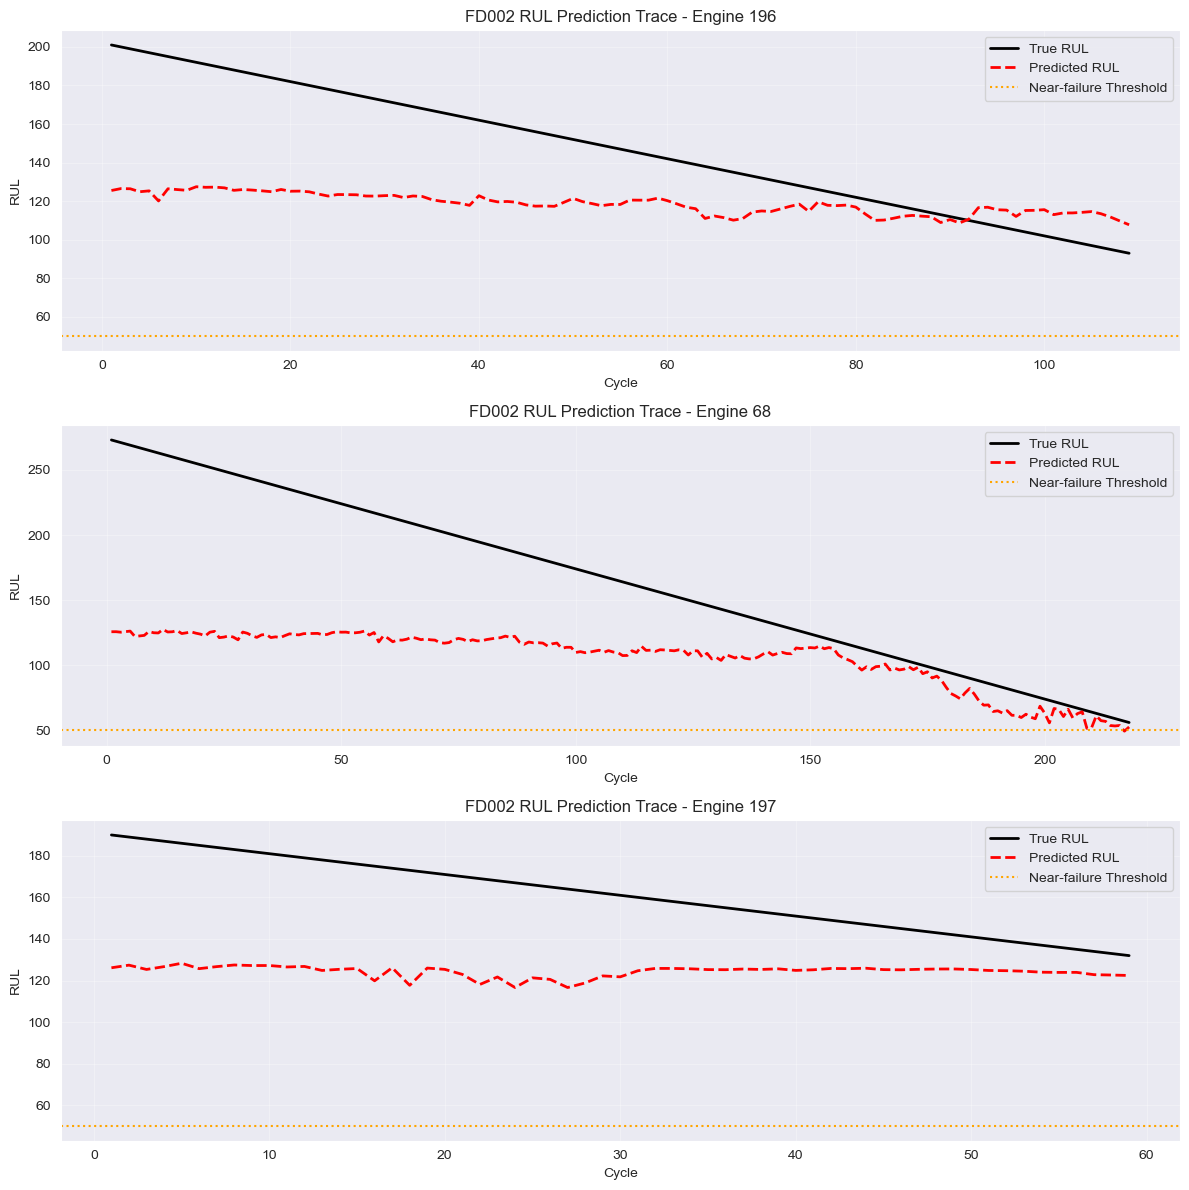

In [49]:
best_model_fd002 = xgb_win_fd002
preds_test_fd002 = best_model_fd002.predict(X_test_win_fd002)

plt.figure(figsize=(10, 8))
plt.scatter(y_test_rul_fd002, preds_test_fd002, alpha=0.5, s=10)
plt.plot([y_test_rul_fd002.min(), y_test_rul_fd002.max()], [y_test_rul_fd002.min(), y_test_rul_fd002.max()], 'r--', linewidth=2)
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.title(f'FD002 RUL Prediction - XGBoost (Window)\nRMSE: {np.sqrt(np.mean((y_test_rul_fd002 - preds_test_fd002) ** 2)):.2f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('fd002_rul_prediction_scatter.png', dpi=300)
plt.close()

residuals_fd002 = y_test_rul_fd002 - preds_test_fd002
plt.figure(figsize=(10, 6))
plt.scatter(preds_test_fd002, residuals_fd002, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted RUL')
plt.ylabel('Residuals (True - Predicted)')
plt.title('FD002 Residual Plot - XGBoost (Window)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('fd002_residual_plot.png', dpi=300)
plt.close()

sample_engines_fd002 = np.random.choice(test_window_fd002['engine_id'].unique(), size=3, replace=False)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
for i, engine in enumerate(sample_engines_fd002):
    engine_mask = test_window_fd002['engine_id'] == engine
    true_rul = test_window_fd002.loc[engine_mask, 'RUL'].values
    engine_X_test = X_test_win_fd002[engine_mask]
    pred_rul = best_model_fd002.predict(engine_X_test)
    cycles = test_window_fd002.loc[engine_mask, 'cycle'].values
    axes[i].plot(cycles, true_rul, label='True RUL', color='black', linewidth=2)
    axes[i].plot(cycles, pred_rul, label='Predicted RUL', color='red', linestyle='--', linewidth=2)
    axes[i].axhline(50, color='orange', linestyle=':', label='Near-failure Threshold')
    axes[i].set_title(f'FD002 RUL Prediction Trace - Engine {engine}')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('RUL')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('fd002_prediction_traces.png', dpi=300)
plt.close() 

In [50]:
cal_split_idx_fd002 = int(len(X_val_win_fd002) * 0.5)
X_cal_fd002 = X_val_win_fd002[:cal_split_idx_fd002]
y_cal_true_fd002 = val_window_fd002['RUL'].iloc[:cal_split_idx_fd002].values
preds_cal_fd002 = best_model_fd002.predict(X_cal_fd002)
y_cal_eval_fd002 = np.clip(y_cal_true_fd002, a_min=None, a_max=125)
scores_fd002 = np.abs(y_cal_eval_fd002 - preds_cal_fd002)

rul_val_fd002 = y_cal_eval_fd002
q_near_fd002 = np.percentile(scores_fd002[rul_val_fd002 <= 50], 95) if (rul_val_fd002 <= 50).sum() > 0 else 0
q_mid_fd002 = np.percentile(scores_fd002[(rul_val_fd002 > 50) & (rul_val_fd002 <= 100)], 95) if ((rul_val_fd002 > 50) & (rul_val_fd002 <= 100)).sum() > 0 else 0
q_early_fd002 = np.percentile(scores_fd002[rul_val_fd002 > 100], 95) if (rul_val_fd002 > 100).sum() > 0 else 0

print("--- FD002 Conformal Prediction Parameters: ---")
print(f"q_95 (Near-failure, RUL<=50): {q_near_fd002:.2f}")
print(f"q_95 (Mid-life, 50<RUL<=100): {q_mid_fd002:.2f}")
print(f"q_95 (Early-life, RUL>100): {q_early_fd002:.2f}")

preds_test_fd002 = best_model_fd002.predict(X_test_win_fd002)
preds_test_capped_fd002 = np.clip(preds_test_fd002, None, 125)

lower_bounds_fd002 = np.zeros_like(preds_test_capped_fd002)
upper_bounds_fd002 = np.zeros_like(preds_test_capped_fd002)

for i, rul_val in enumerate(preds_test_capped_fd002):
    if rul_val <= 50:
        lower_bounds_fd002[i] = max(0, rul_val - q_near_fd002)
        upper_bounds_fd002[i] = rul_val + q_near_fd002
    elif rul_val <= 100:
        lower_bounds_fd002[i] = max(0, rul_val - q_mid_fd002)
        upper_bounds_fd002[i] = rul_val + q_mid_fd002
    else:
        lower_bounds_fd002[i] = max(0, rul_val - q_early_fd002)
        upper_bounds_fd002[i] = rul_val + q_early_fd002

y_test_eval_fd002 = np.clip(y_test_rul_fd002, None, 125)
coverage_fd002 = np.mean((y_test_eval_fd002 >= lower_bounds_fd002) & (y_test_eval_fd002 <= upper_bounds_fd002))
mean_width_fd002 = np.mean(upper_bounds_fd002 - lower_bounds_fd002)

print("\n--- FD002 Conformal Prediction Performance: ---")
print(f"Empirical Coverage: {coverage_fd002*100:.2f}%")
print(f"Mean Interval Width: {mean_width_fd002:.2f} cycles")

--- FD002 Conformal Prediction Parameters: ---
q_95 (Near-failure, RUL<=50): 17.43
q_95 (Mid-life, 50<RUL<=100): 29.42
q_95 (Early-life, RUL>100): 20.93

--- FD002 Conformal Prediction Performance: ---
Empirical Coverage: 94.21%
Mean Interval Width: 44.34 cycles


In [51]:
horizons_fd002 = [10, 20, 30]

for h in horizons_fd002:
    train_window_fd002[f'label_h{h}'] = (train_window_fd002['RUL'] <= h).astype(int)
    val_window_fd002[f'label_h{h}'] = (val_window_fd002['RUL'] <= h).astype(int)
    test_window_fd002[f'label_h{h}'] = (test_window_fd002['RUL'] <= h).astype(int)

X_train_cls_fd002 = X_train_win_fd002.copy()
X_val_cls_fd002 = X_val_win_fd002.copy()
X_test_cls_fd002 = X_test_win_fd002.copy()

y_train_cls_fd002 = {h: train_window_fd002[f'label_h{h}'].values for h in horizons_fd002}
y_val_cls_fd002 = {h: val_window_fd002[f'label_h{h}'].values for h in horizons_fd002}
y_test_cls_fd002 = {h: test_window_fd002[f'label_h{h}'].values for h in horizons_fd002}

models_cls_fd002 = {}
for h in horizons_fd002:
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_cls_fd002, y_train_cls_fd002[h])
    
    xgb_c = xgb.XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
    xgb_c.fit(X_train_cls_fd002, y_train_cls_fd002[h])
    
    models_cls_fd002[h] = {'LR': lr, 'XGBoost': xgb_c}

print("--- FD002 Classification Models Trained: ---")
for h in horizons_fd002:
    pos_train = y_train_cls_fd002[h].sum()
    total_train = len(y_train_cls_fd002[h])
    pos_test = y_test_cls_fd002[h].sum()
    total_test = len(y_test_cls_fd002[h])
    print(f"Horizon {h:2d} cycles -> Train: {pos_train:5d}/{total_train:5d} ({pos_train/total_train*100:.1f}%) | Test: {pos_test:5d}/{total_test:5d} ({pos_test/total_test*100:.1f}%)")
    
    
label_cols = [f'label_h{h}' for h in horizons_fd002]
train_window_fd002 = train_window_fd002.drop(columns=label_cols)
val_window_fd002 = val_window_fd002.drop(columns=label_cols)
test_window_fd002 = test_window_fd002.drop(columns=label_cols)

--- FD002 Classification Models Trained: ---
Horizon 10 cycles -> Train:  1716/31871 (5.4%) | Test:    68/33991 (0.2%)
Horizon 20 cycles -> Train:  3276/31871 (10.3%) | Test:   504/33991 (1.5%)
Horizon 30 cycles -> Train:  4836/31871 (15.2%) | Test:  1087/33991 (3.2%)


In [52]:
def tune_threshold_fd002(y_true, y_prob, fn_cost=10, fp_cost=1):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = []
    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        costs.append(fn * fn_cost + fp * fp_cost)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs[best_idx]

calibrated_models_fd002 = {}
tuned_thresholds_fd002 = {}

for h in horizons_fd002:
    calibrated_models_fd002[h] = {}
    tuned_thresholds_fd002[h] = {}
    for name, model in models_cls_fd002[h].items():
        calib_model = CalibratedClassifierCV(estimator=model, method='isotonic', cv='prefit')
        calib_model.fit(X_val_cls_fd002, y_val_cls_fd002[h])
        calibrated_models_fd002[h][name] = calib_model
        
        y_val_prob = calib_model.predict_proba(X_val_cls_fd002)[:, 1]
        best_th, _ = tune_threshold_fd002(y_val_cls_fd002[h], y_val_prob, fn_cost=10, fp_cost=1)
        tuned_thresholds_fd002[h][name] = best_th

print("--- FD002 Isotonic Calibration & Threshold Tuning Complete: ---")
for h in horizons_fd002:
    print(f"\nHorizon {h} Cycles:")
    for name in ['LR', 'XGBoost']:
        th = tuned_thresholds_fd002[h][name]
        print(f"{name}: Optimal Threshold = {th:.4f}")

--- FD002 Isotonic Calibration & Threshold Tuning Complete: ---

Horizon 10 Cycles:
LR: Optimal Threshold = 0.0800
XGBoost: Optimal Threshold = 0.0600

Horizon 20 Cycles:
LR: Optimal Threshold = 0.0500
XGBoost: Optimal Threshold = 0.0900

Horizon 30 Cycles:
LR: Optimal Threshold = 0.0800
XGBoost: Optimal Threshold = 0.0500


In [53]:
cls_results_fd002 = []
for h in horizons_fd002:
    for name, model in calibrated_models_fd002[h].items():
        y_test_prob = model.predict_proba(X_test_cls_fd002)[:, 1]
        y_test_pred = (y_test_prob >= tuned_thresholds_fd002[h][name]).astype(int)
        
        pr, rc, _ = precision_recall_curve(y_test_cls_fd002[h], y_test_prob)
        pr_auc = auc(rc, pr)
        
        precision = precision_score(y_test_cls_fd002[h], y_test_pred)
        recall = recall_score(y_test_cls_fd002[h], y_test_pred)
        f1 = f1_score(y_test_cls_fd002[h], y_test_pred)
        brier = brier_score_loss(y_test_cls_fd002[h], y_test_prob)
        cm = confusion_matrix(y_test_cls_fd002[h], y_test_pred)
        
        cls_results_fd002.append({
            'Horizon': h,
            'Model': name,
            'PR-AUC': pr_auc,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Brier': brier,
            'Threshold': tuned_thresholds_fd002[h][name],
            'CM_TN': cm[0,0], 'CM_FP': cm[0,1], 'CM_FN': cm[1,0], 'CM_TP': cm[1,1]
        })

cls_results_df_fd002 = pd.DataFrame(cls_results_fd002)
print("--- FD002 Classification Results: ---")
print(cls_results_df_fd002.to_string(index=False))

--- FD002 Classification Results: ---
 Horizon   Model   PR-AUC  Precision   Recall       F1    Brier  Threshold  CM_TN  CM_FP  CM_FN  CM_TP
      10      LR 0.617160   0.232472 0.926471 0.371681 0.001516       0.08  33715    208      5     63
      10 XGBoost 0.751491   0.292793 0.955882 0.448276 0.001032       0.06  33766    157      3     65
      20      LR 0.852613   0.560000 0.944444 0.703102 0.005519       0.05  33113    374     28    476
      20 XGBoost 0.899687   0.718069 0.914683 0.804538 0.004025       0.09  33306    181     43    461
      30      LR 0.924635   0.527574 0.994480 0.689413 0.007927       0.08  31936    968      6   1081
      30 XGBoost 0.941427   0.660176 0.966881 0.784621 0.006793       0.05  32363    541     36   1051


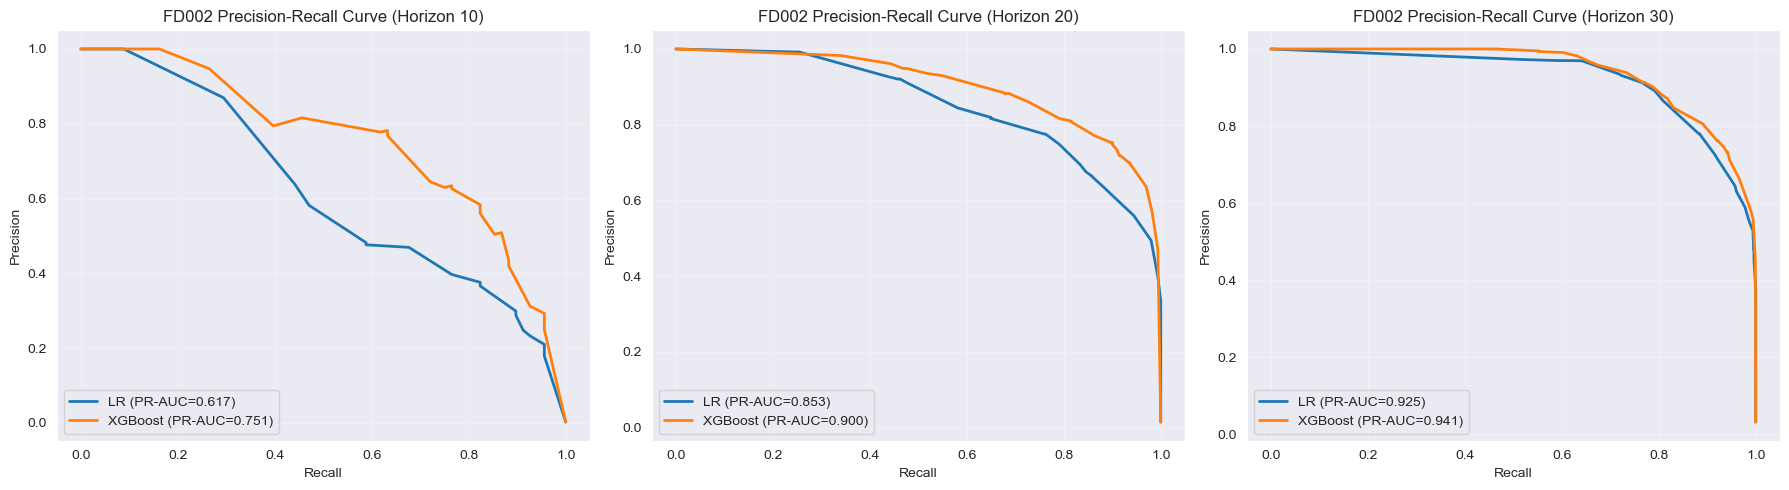

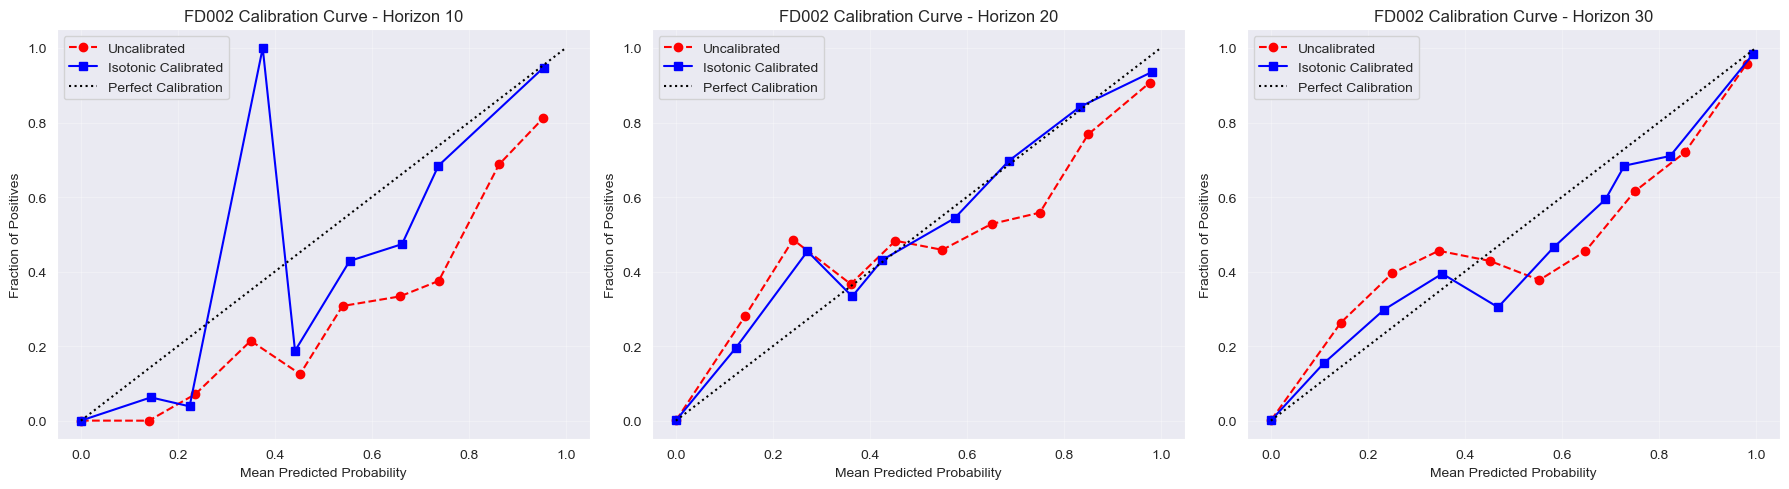

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, h in enumerate(horizons_fd002):
    for name, model in calibrated_models_fd002[h].items():
        y_test_prob = model.predict_proba(X_test_cls_fd002)[:, 1]
        pr, rc, _ = precision_recall_curve(y_test_cls_fd002[h], y_test_prob)
        axes[i].plot(rc, pr, linewidth=2, label=f'{name} (PR-AUC={auc(rc, pr):.3f})')
    axes[i].set_title(f'FD002 Precision-Recall Curve (Horizon {h})')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend(loc='lower left')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('fd002_pr_curves.png', dpi=300)
plt.close()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, h in enumerate(horizons_fd002):
    uncalib_prob = models_cls_fd002[h]['XGBoost'].predict_proba(X_test_cls_fd002)[:, 1]
    calib_prob = calibrated_models_fd002[h]['XGBoost'].predict_proba(X_test_cls_fd002)[:, 1]
    
    fop_uncalib, mpv_uncalib = calibration_curve(y_test_cls_fd002[h], uncalib_prob, n_bins=10)
    fop_calib, mpv_calib = calibration_curve(y_test_cls_fd002[h], calib_prob, n_bins=10)
    
    axes[i].plot(mpv_uncalib, fop_uncalib, marker='o', linestyle='--', color='red', label='Uncalibrated')
    axes[i].plot(mpv_calib, fop_calib, marker='s', linestyle='-', color='blue', label='Isotonic Calibrated')
    axes[i].plot([0, 1], [0, 1], linestyle=':', color='black', label='Perfect Calibration')
    axes[i].set_title(f'FD002 Calibration Curve - Horizon {h}')
    axes[i].set_xlabel('Mean Predicted Probability')
    axes[i].set_ylabel('Fraction of Positives')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('fd002_calibration_curves.png', dpi=300)
plt.close()

In [55]:
healthy_region_fd002 = train_window_fd002[train_window_fd002['RUL'] > 150]
healthy_features_fd002 = healthy_region_fd002[feature_cols_window_fd002].values

if len(healthy_features_fd002) == 0:
    healthy_region_fd002 = train_window_fd002.head(1000)
    healthy_features_fd002 = train_window_fd002[feature_cols_window_fd002].values

iso_forest_fd002 = IsolationForest(contamination=0.05, random_state=42)
iso_forest_fd002.fit(healthy_features_fd002)

lof_fd002 = LocalOutlierFactor(novelty=True, n_neighbors=20)
lof_fd002.fit(healthy_features_fd002)

ocsvm_fd002 = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm_fd002.fit(healthy_features_fd002)

pca_fd002 = PCA(n_components=0.9)
pca_fd002.fit(healthy_features_fd002)

models_unsupervised_fd002 = {
    'Isolation_Forest': iso_forest_fd002,
    'LOF': lof_fd002,
    'OCSVM': ocsvm_fd002,
    'PCA': pca_fd002
}

print("--- FD002 Anomaly Detection Models Trained: ---")
print(f"Isolation Forest: trained on {healthy_features_fd002.shape[0]} healthy samples")
print(f"LOF: trained on {healthy_features_fd002.shape[0]} healthy samples")
print(f"One-Class SVM: trained on {healthy_features_fd002.shape[0]} healthy samples")
print(f"PCA: trained on {healthy_features_fd002.shape[0]} healthy samples")

--- FD002 Anomaly Detection Models Trained: ---
Isolation Forest: trained on 8400 healthy samples
LOF: trained on 8400 healthy samples
One-Class SVM: trained on 8400 healthy samples
PCA: trained on 8400 healthy samples


In [56]:
def get_anomaly_scores_fd002(model, X, model_name):
    if model_name in ['Isolation_Forest', 'LOF', 'OCSVM']:
        return -model.decision_function(X)
    elif model_name == 'PCA':
        X_reconstructed = model.inverse_transform(model.transform(X))
        return np.mean((X - X_reconstructed) ** 2, axis=1)

raw_scores_val_fd002 = {}
for name, model in models_unsupervised_fd002.items():
    raw_scores_val_fd002[name] = get_anomaly_scores_fd002(model, X_val_win_fd002, name)

def raw_to_percentile_fd002(reference_scores, new_scores):
    return np.array([percentileofscore(reference_scores, s, kind='weak') for s in new_scores])

pct_scores_val_fd002 = {}
pct_scores_test_fd002 = {}
for name, model in models_unsupervised_fd002.items():
    raw_test = get_anomaly_scores_fd002(model, X_test_win_fd002, name)
    pct_scores_val_fd002[name] = raw_to_percentile_fd002(raw_scores_val_fd002[name], raw_scores_val_fd002[name])
    pct_scores_test_fd002[name] = raw_to_percentile_fd002(raw_scores_val_fd002[name], raw_test)

for name in models_unsupervised_fd002.keys():
    test_window_fd002[f'{name}_Anomaly_Score'] = pct_scores_test_fd002[name]

print("--- FD002 Anomaly Scores Normalized to Percentiles: ---")
for name in models_unsupervised_fd002.keys():
    print(f"{name}: mean={np.mean(pct_scores_test_fd002[name]):.1f}, std={np.std(pct_scores_test_fd002[name]):.1f}")

--- FD002 Anomaly Scores Normalized to Percentiles: ---
Isolation_Forest: mean=53.9, std=19.2
LOF: mean=39.0, std=24.9
OCSVM: mean=38.8, std=23.5
PCA: mean=39.0, std=24.6


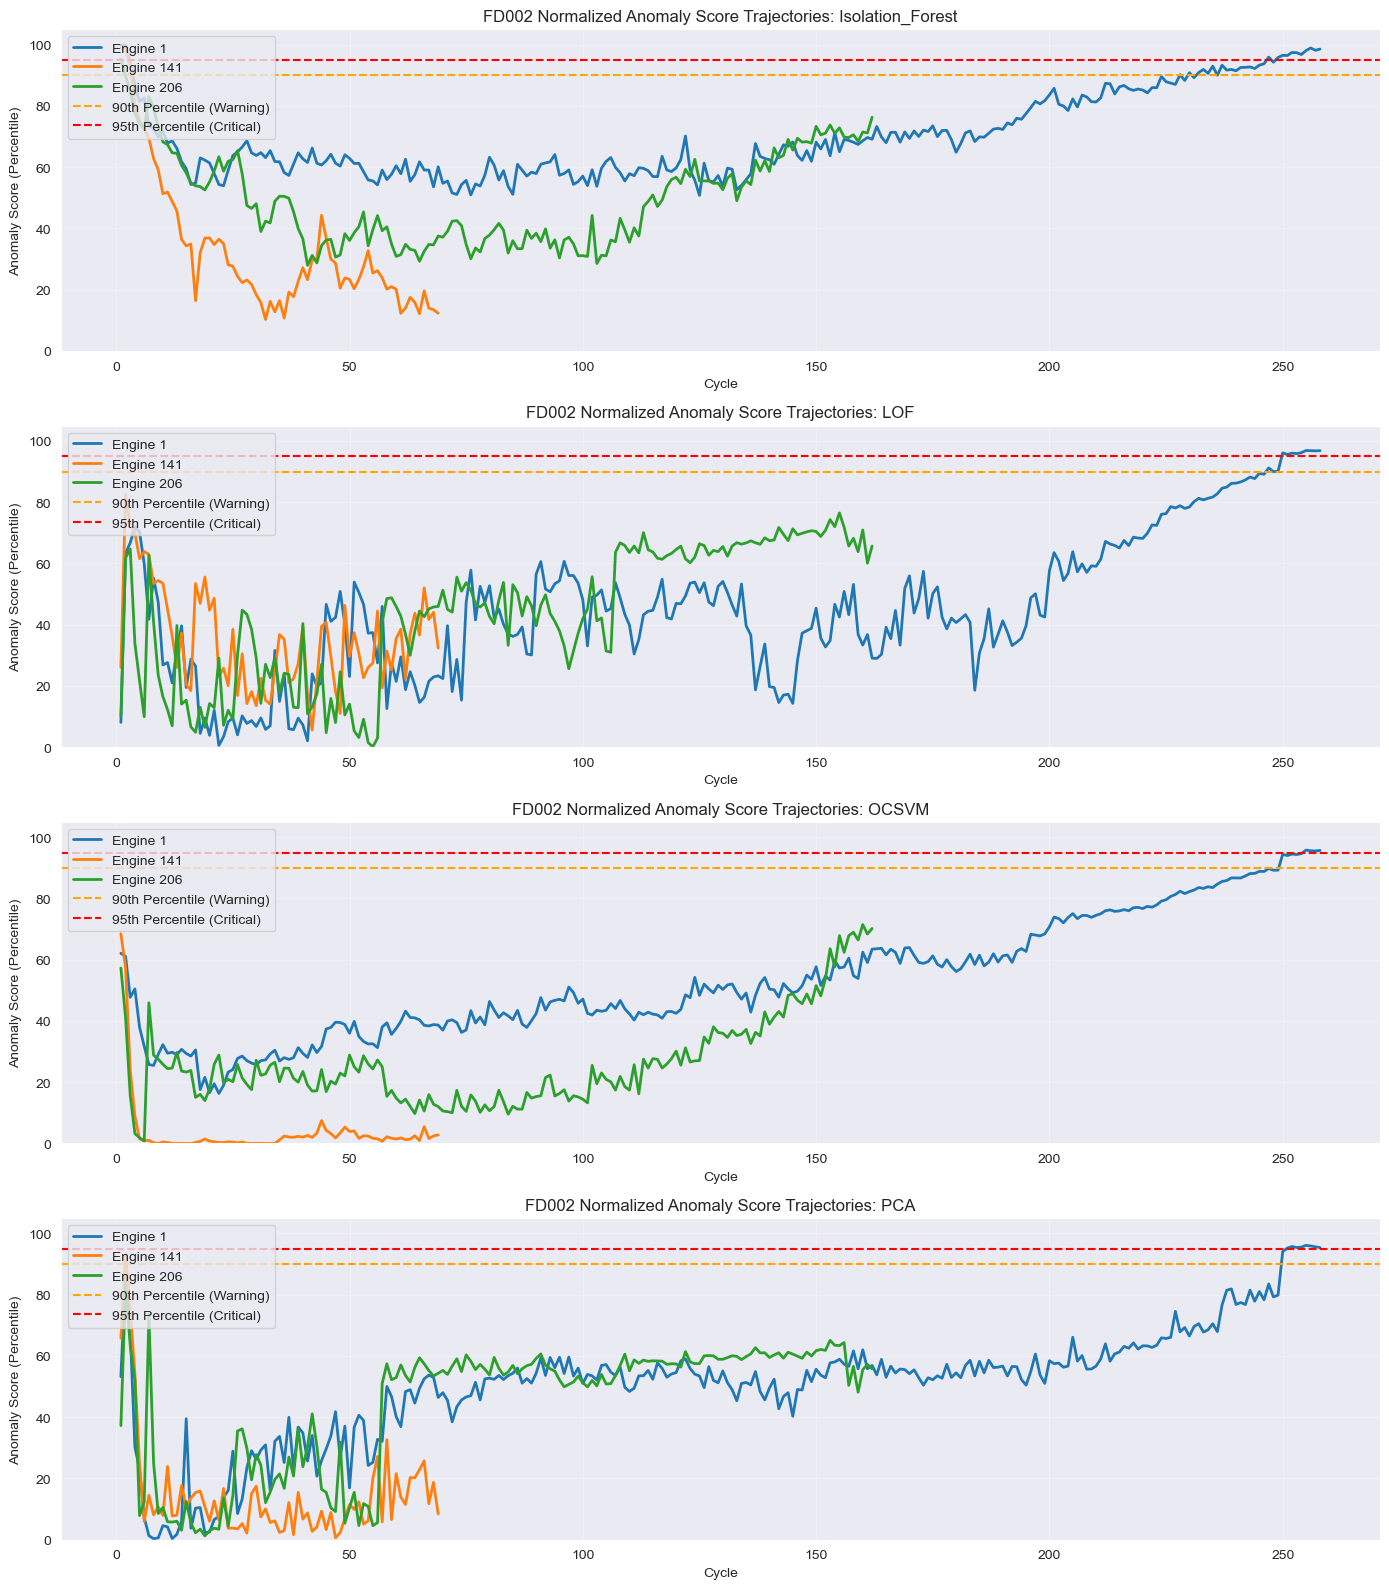

--- FD002 Threshold Sensitivity Analysis ---:
Isolation_Forest - 90th percentile: True Alarm=1.83%, False Alarm=1.93%
Isolation_Forest - 95th percentile: True Alarm=0.59%, False Alarm=1.48%
Isolation_Forest - 99th percentile: True Alarm=0.02%, False Alarm=0.61%
LOF - 90th percentile: True Alarm=1.48%, False Alarm=0.22%
LOF - 95th percentile: True Alarm=0.73%, False Alarm=0.02%
LOF - 99th percentile: True Alarm=0.17%, False Alarm=0.00%
OCSVM - 90th percentile: True Alarm=1.32%, False Alarm=0.04%
OCSVM - 95th percentile: True Alarm=0.51%, False Alarm=0.01%
OCSVM - 99th percentile: True Alarm=0.15%, False Alarm=0.00%
PCA - 90th percentile: True Alarm=1.26%, False Alarm=0.55%
PCA - 95th percentile: True Alarm=0.67%, False Alarm=0.18%
PCA - 99th percentile: True Alarm=0.18%, False Alarm=0.03%


In [57]:
sample_engines_fd002 = np.random.choice(test_window_fd002['engine_id'].unique(), size=3, replace=False)
fig, axes = plt.subplots(len(models_unsupervised_fd002), 1, figsize=(14, 16), sharex=False)

for i, (name, _) in enumerate(models_unsupervised_fd002.items()):
    for engine in sample_engines_fd002:
        engine_mask = test_window_fd002['engine_id'] == engine
        cycles = test_window_fd002.loc[engine_mask, 'cycle'].values
        scores = test_window_fd002.loc[engine_mask, f'{name}_Anomaly_Score'].values
        axes[i].plot(cycles, scores, label=f'Engine {engine}', linewidth=2)
    axes[i].axhline(90, color='orange', linestyle='--', label='90th Percentile (Warning)')
    axes[i].axhline(95, color='red', linestyle='--', label='95th Percentile (Critical)')
    axes[i].set_title(f'FD002 Normalized Anomaly Score Trajectories: {name}')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Anomaly Score (Percentile)')
    axes[i].set_ylim(0, 105)
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('fd002_anomaly_score_trajectories.png', dpi=300)
plt.close()

print("--- FD002 Threshold Sensitivity Analysis ---:")
for name in models_unsupervised_fd002.keys():
    scores = pct_scores_test_fd002[name]
    rul_vals = test_window_fd002['RUL'].values
    
    for threshold in [90, 95, 99]:
        true_alarm = np.mean((scores >= threshold) & (rul_vals <= 50))
        false_alarm = np.mean((scores >= threshold) & (rul_vals > 150))
        print(f"{name} - {threshold}th percentile: True Alarm={true_alarm:.2%}, False Alarm={false_alarm:.2%}")

In [58]:
h_target_fd002 = 30
th_xgb_fd002 = tuned_thresholds_fd002[30]['XGBoost']

test_eval_fd002 = test_window_fd002.copy()
test_eval_fd002['prob_h30'] = calibrated_models_fd002[30]['XGBoost'].predict_proba(X_test_cls_fd002)[:, 1]
test_eval_fd002['raw_alert'] = ((test_eval_fd002['prob_h30'] >= th_xgb_fd002) | 
                                (test_eval_fd002['OCSVM_Anomaly_Score'] >= 95)).astype(int)

def persistent_rule_fd002(series, window=5, min_alerts=3):
    return (series.rolling(window=window, min_periods=1).sum() >= min_alerts).astype(int)

test_eval_fd002['persistent_alert'] = test_eval_fd002.groupby('engine_id')['raw_alert'].transform(persistent_rule_fd002)

print("--- FD002 Early Warning System Setup Complete: ---")
print(f"Target Horizon: {h_target_fd002} cycles")
print(f"XGBoost Threshold: {th_xgb_fd002:.4f}")
print(f"Anomaly Threshold: 95th percentile")
print(f"Persistent Rule: {persistent_rule_fd002.__doc__}")

--- FD002 Early Warning System Setup Complete: ---
Target Horizon: 30 cycles
XGBoost Threshold: 0.0500
Anomaly Threshold: 95th percentile
Persistent Rule: None


In [59]:
c_miss_fd002 = 10
c_late_fd002 = 5
c_early_fd002 = 1

alert_metrics_fd002 = []
for engine in test_eval_fd002['engine_id'].unique():
    engine_data = test_eval_fd002[test_eval_fd002['engine_id'] == engine].sort_values('cycle')
    T_i = engine_data['cycle'].iloc[-1] + engine_data['RUL'].iloc[-1]
    min_rul = engine_data['RUL'].min()
    is_truly_critical = (min_rul <= h_target_fd002)
    
    alerts = engine_data[engine_data['persistent_alert'] == 1]
    
    if len(alerts) > 0:
        tau_i = alerts['cycle'].iloc[0]
        L_i = T_i - tau_i
        late_delay = max(0, h_target_fd002 - L_i)
        early_burden = max(0, L_i - h_target_fd002)
        miss = 0
        cost = (late_delay * c_late_fd002) + (early_burden * c_early_fd002)
    else:
        tau_i = np.nan
        L_i = np.nan
        late_delay = np.nan
        early_burden = np.nan
        if is_truly_critical:
            miss = 1
            cost = c_miss_fd002 * h_target_fd002
        else:
            miss = 0
            cost = 0
    
    alert_metrics_fd002.append({
        'engine_id': engine,
        'T_i': T_i,
        'tau_i': tau_i,
        'L_i': L_i,
        'Late_Delay': late_delay,
        'Early_Burden': early_burden,
        'Miss': miss,
        'Total_Cost': cost,
        'is_critical': int(is_truly_critical)
    })

metrics_df_fd002 = pd.DataFrame(alert_metrics_fd002)
critical_engines_df_fd002 = metrics_df_fd002[metrics_df_fd002['is_critical'] == 1]
real_miss_rate_fd002 = (critical_engines_df_fd002['Miss'].sum() / len(critical_engines_df_fd002) * 100) if len(critical_engines_df_fd002) > 0 else 0.0

summary_metrics_fd002 = {
    'Miss Rate (Critical Engines) (%)': real_miss_rate_fd002,
    'Avg Lead Time (Cycles)': metrics_df_fd002['L_i'].mean(),
    'Avg Late Delay (Cycles)': metrics_df_fd002['Late_Delay'].fillna(0).mean(),
    'Avg Early Burden (Cycles)': metrics_df_fd002['Early_Burden'].fillna(0).mean(),
    'Avg Total Cost': metrics_df_fd002['Total_Cost'].mean()
}

print("--- FD002 Early Warning Metrics: ---")
for key, value in summary_metrics_fd002.items():
    print(f"{key}: {value:.2f}")

total_engines_fd002 = len(test_eval_fd002['engine_id'].unique())
critical_count_fd002 = len(critical_engines_df_fd002)
engines_with_alerts_fd002 = sum(1 for engine in test_eval_fd002['engine_id'].unique() if len(test_eval_fd002[(test_eval_fd002['engine_id'] == engine) & (test_eval_fd002['persistent_alert'] == 1)]) > 0)

print(f"\nNumber of All Test Engines: {total_engines_fd002}")
print(f"Number of Critical Engines: {critical_count_fd002}")
print(f"Number of Engines with Warnings: {engines_with_alerts_fd002}")

--- FD002 Early Warning Metrics: ---
Miss Rate (Critical Engines) (%): 0.00
Avg Lead Time (Cycles): 35.75
Avg Late Delay (Cycles): 0.27
Avg Early Burden (Cycles): 1.84
Avg Total Cost: 3.17

Number of All Test Engines: 259
Number of Critical Engines: 61
Number of Engines with Warnings: 71


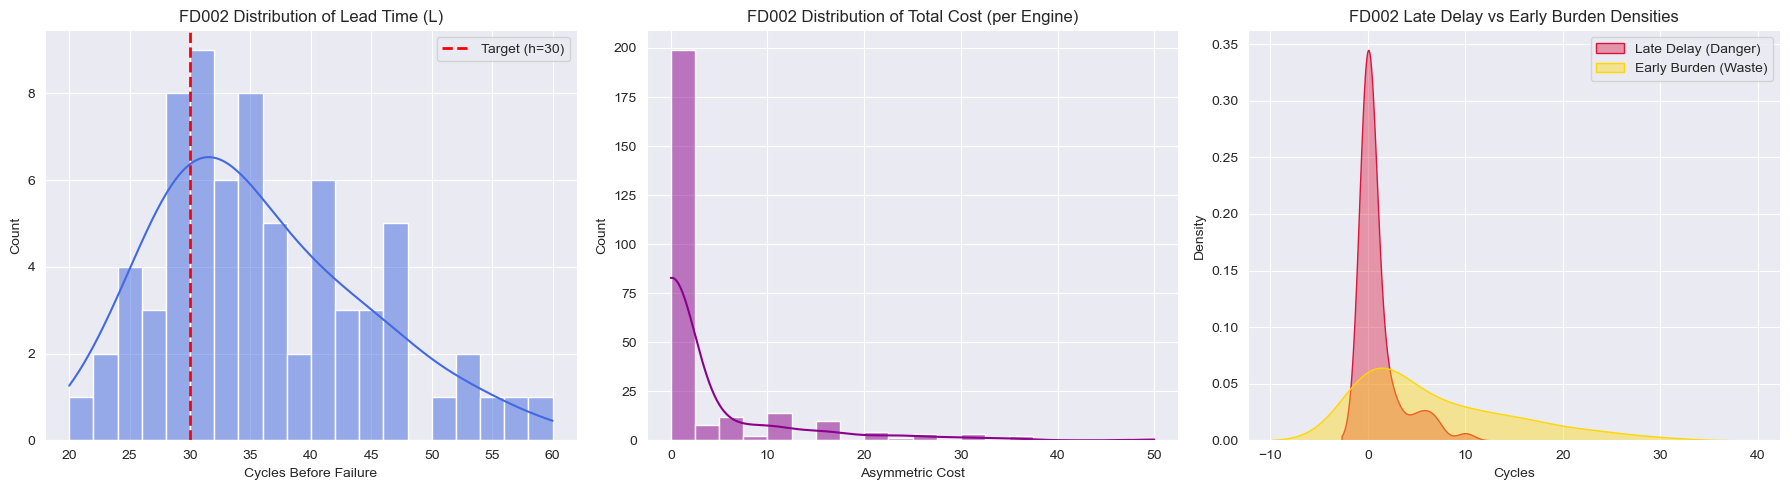

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

valid_L_fd002 = metrics_df_fd002['L_i'].dropna()
sns.histplot(valid_L_fd002, bins=20, kde=True, ax=axes[0], color='royalblue')
axes[0].axvline(h_target_fd002, color='red', linestyle='--', linewidth=2, label=f'Target (h={h_target_fd002})')
axes[0].set_title('FD002 Distribution of Lead Time (L)')
axes[0].set_xlabel('Cycles Before Failure')
axes[0].legend()

sns.histplot(metrics_df_fd002['Total_Cost'], bins=20, kde=True, ax=axes[1], color='darkmagenta')
axes[1].set_title('FD002 Distribution of Total Cost (per Engine)')
axes[1].set_xlabel('Asymmetric Cost')

sns.kdeplot(metrics_df_fd002['Late_Delay'].dropna(), ax=axes[2], color='crimson', label='Late Delay (Danger)', fill=True, alpha=0.4)
sns.kdeplot(metrics_df_fd002['Early_Burden'].dropna(), ax=axes[2], color='gold', label='Early Burden (Waste)', fill=True, alpha=0.4)
axes[2].set_title('FD002 Late Delay vs Early Burden Densities')
axes[2].set_xlabel('Cycles')
axes[2].legend()

plt.tight_layout()
plt.show()
plt.savefig('fd002_early_warning_metrics.png', dpi=300)
plt.close()

In [61]:
rul_uncertainty_report_fd002 = pd.DataFrame({
    'Metric': ['Target Confidence Level', 'Overall Empirical Coverage (Test)', 'Overall Mean Interval Width (Cycles)'],
    'Value': ['95.00%', f"{coverage_fd002 * 100:.2f}%", f"{mean_width_fd002:.2f}"]
})

print("--- FD002 Overall 3-Region RUL Uncertainty (Conformal Prediction): ---")
print(rul_uncertainty_report_fd002.to_string(index=False))

regions_fd002 = {
    'Critical (RUL <= 50)': y_test_eval_fd002 <= 50,
    'Medium (50 < RUL <= 100)': (y_test_eval_fd002 > 50) & (y_test_eval_fd002 <= 100),
    'Healthy (RUL > 100)': y_test_eval_fd002 > 100
}

region_metrics_fd002 = []
for reg_name, mask in regions_fd002.items():
    if np.sum(mask) > 0:
        reg_cov = np.mean((y_test_eval_fd002[mask] >= lower_bounds_fd002[mask]) & (y_test_eval_fd002[mask] <= upper_bounds_fd002[mask]))
        reg_width = np.mean(upper_bounds_fd002[mask] - lower_bounds_fd002[mask])
        region_metrics_fd002.append({
            'Region': reg_name,
            'Sample Count': int(np.sum(mask)),
            'Coverage (%)': round(reg_cov * 100, 2),
            'Mean Width (Cycles)': round(reg_width, 2)
        })

df_region_metrics_fd002 = pd.DataFrame(region_metrics_fd002)
print("\n--- FD002 Region-wise Conformal Prediction Performance: ---")
print(df_region_metrics_fd002.to_string(index=False))

--- FD002 Overall 3-Region RUL Uncertainty (Conformal Prediction): ---
                              Metric  Value
             Target Confidence Level 95.00%
   Overall Empirical Coverage (Test) 94.21%
Overall Mean Interval Width (Cycles)  44.34

--- FD002 Region-wise Conformal Prediction Performance: ---
                  Region  Sample Count  Coverage (%)  Mean Width (Cycles)
    Critical (RUL <= 50)          2586         98.18            38.720001
Medium (50 < RUL <= 100)          6245         83.49            52.820000
     Healthy (RUL > 100)         25160         96.46            42.810001


In [62]:
h_fd002 = 30
y_test_true_cls_fd002 = y_test_cls_fd002[h_fd002]

uncalib_prob_fd002 = models_cls_fd002[h_fd002]['XGBoost'].predict_proba(X_test_cls_fd002)[:, 1]
brier_uncalib_fd002 = brier_score_loss(y_test_true_cls_fd002, uncalib_prob_fd002)

calib_prob_fd002 = calibrated_models_fd002[h_fd002]['XGBoost'].predict_proba(X_test_cls_fd002)[:, 1]
brier_calib_fd002 = brier_score_loss(y_test_true_cls_fd002, calib_prob_fd002)

cls_uncertainty_report_fd002 = pd.DataFrame({
    'Model State (Horizon 30)': ['XGBoost (Uncalibrated)', 'XGBoost (Isotonic Calibrated)'],
    'Brier Score': [round(brier_uncalib_fd002, 4), round(brier_calib_fd002, 4)]
})

print("--- FD002 Classification Uncertainty (Calibration): ---")
print(cls_uncertainty_report_fd002.to_string(index=False))

--- FD002 Classification Uncertainty (Calibration): ---
     Model State (Horizon 30)  Brier Score
       XGBoost (Uncalibrated)       0.0071
XGBoost (Isotonic Calibrated)       0.0068


In [63]:
sample_idx_fd002 = len(test_window_fd002) - 15
sample_engine_fd002 = test_window_fd002.iloc[sample_idx_fd002]['engine_id']
sample_cycle_fd002 = test_window_fd002.iloc[sample_idx_fd002]['cycle']
sample_rul_pred_fd002 = preds_test_capped_fd002[sample_idx_fd002]
sample_rul_lower_fd002 = lower_bounds_fd002[sample_idx_fd002]
sample_rul_upper_fd002 = upper_bounds_fd002[sample_idx_fd002]
sample_calib_prob_fd002 = calibrated_models_fd002[30]['XGBoost'].predict_proba(X_test_cls_fd002)[sample_idx_fd002:sample_idx_fd002+1][:, 1][0]
sample_anomaly_pct_fd002 = pct_scores_test_fd002['OCSVM'][sample_idx_fd002]

print("--- FD002 Uncertainty-Aware Recommendation Sample: ---")
print(f"Engine: {sample_engine_fd002}, Cycle: {sample_cycle_fd002}")
print(f"RUL: {sample_rul_pred_fd002:.0f} cycles (95% CI: [{sample_rul_lower_fd002:.0f}, {sample_rul_upper_fd002:.0f}])")
print(f"Failure Probability (30 cycles): {sample_calib_prob_fd002*100:.1f}%")
print(f"Anomaly Score: {sample_anomaly_pct_fd002:.1f}th percentile")

--- FD002 Uncertainty-Aware Recommendation Sample: ---
Engine: 259.0, Cycle: 109.0
RUL: 74 cycles (95% CI: [44, 103])
Failure Probability (30 cycles): 0.0%
Anomaly Score: 24.7th percentile


In [64]:
fd001_best_rmse = np.sqrt(np.mean((y_test_eval - preds_test_rul) ** 2))
fd001_best_mae = np.mean(np.abs(y_test_eval - preds_test_rul))
fd001_pr_auc_h30 = cls_results[4]['PR-AUC']
fd001_miss_rate = real_miss_rate
fd001_avg_lead_time = metrics_df['L_i'].mean()
fd001_conformal_coverage = empirical_coverage * 100

fd002_best_rmse = np.sqrt(np.mean((y_test_eval_fd002 - preds_test_capped_fd002) ** 2))
fd002_best_mae = np.mean(np.abs(y_test_eval_fd002 - preds_test_capped_fd002))
fd002_pr_auc_h30 = cls_results_df_fd002[(cls_results_df_fd002['Horizon']==30) & (cls_results_df_fd002['Model']=='XGBoost')]['PR-AUC'].values[0]
fd002_miss_rate = real_miss_rate_fd002
fd002_avg_lead_time = metrics_df_fd002['L_i'].mean()
fd002_conformal_coverage = coverage_fd002 * 100

comparison_df = pd.DataFrame({
    'Metric': ['RMSE (XGBoost Window)', 'MAE (XGBoost Window)', 'PR-AUC (XGBoost h=30)', 
               'Miss Rate (%)', 'Avg Lead Time', 'Conformal Coverage (%)'],
    'FD001': [fd001_best_rmse, fd001_best_mae, fd001_pr_auc_h30, fd001_miss_rate, fd001_avg_lead_time, fd001_conformal_coverage],
    'FD002': [fd002_best_rmse, fd002_best_mae, fd002_pr_auc_h30, fd002_miss_rate, fd002_avg_lead_time, fd002_conformal_coverage]
})

print("--- FD001 vs FD002 Comparison: ---")
display(comparison_df)

--- FD001 vs FD002 Comparison: ---


,Metric,FD001,FD002
0,RMSE (XGBoost Window),10.112201,11.576413
1,MAE (XGBoost Window),7.213665,7.961343
2,PR-AUC (XGBoost h=30),0.943289,0.941427
3,Miss Rate (%),0.000000,0.000000
4,Avg Lead Time,33.807692,35.746479
5,Conformal Coverage (%),95.464264,94.210232


# Extracting Artifacts

In [65]:
fd001_thresholds = {
    'rul_stop': 65,
    'prob_stop': 0.05,
    'anomaly_stop': 75,
    'rul_inspect': 120,
    'rul_inspect_lower': 90,
    'prob_inspect': 0.08,
    'anomaly_inspect': 78,
    'trend_threshold': -4,
    'monitor_prob': 0.05,
}

fd002_thresholds = {
    'rul_stop': 65,
    'prob_stop': 0.05,
    'anomaly_stop': 75,
    'rul_inspect': 110,
    'rul_inspect_lower': 85,
    'prob_inspect': 0.10,
    'anomaly_inspect': 80,
    'trend_threshold': -4,
    'monitor_prob': 0.05,
}

joblib.dump(scaler, 'saved_artifacts/scaler_fd001.joblib')
joblib.dump(flatline_sensors, 'saved_artifacts/dropped_sensors_fd001.joblib')

feature_info_fd001 = {
    'op_settings': ['op_setting_1', 'op_setting_2', 'op_setting_3'],
    'active_sensors': active_sensors,
    'all_features': features_to_scale,
}
joblib.dump(feature_info_fd001, 'saved_artifacts/feature_info_fd001.joblib')

window_info_fd001 = {
    'window_sizes': window_sizes,
    'feature_cols': active_sensors,
    'op_settings': ['op_setting_1', 'op_setting_2', 'op_setting_3'],
    'num_windows': len(window_sizes),
}
joblib.dump(window_info_fd001, 'saved_artifacts/window_info_fd001.joblib')

joblib.dump(ridge_model, 'saved_artifacts/ridge_model_fd001.joblib')
joblib.dump(poly_model, 'saved_artifacts/poly_model_fd001.joblib')
joblib.dump(rf_model, 'saved_artifacts/rf_model_fd001.joblib')
joblib.dump(xgb_base_model, 'saved_artifacts/xgb_base_model_fd001.joblib')
joblib.dump(xgb_win_model, 'saved_artifacts/xgb_win_model_fd001.joblib')

best_model_info_fd001 = {
    'best_model_name': 'XGBoost (Window)',
    'best_model_path': 'xgb_win_model_fd001.joblib',
    'feature_type': 'window',
}
joblib.dump(best_model_info_fd001, 'saved_artifacts/best_model_info_fd001.joblib')

rul_params_fd001 = {
    'rul_cap': 125,
}
joblib.dump(rul_params_fd001, 'saved_artifacts/rul_params_fd001.joblib')

conformal_params_fd001 = {
    'q_95_near_failure': float(q_95_near),
    'q_95_mid_life': float(q_95_mid),
    'q_95_early_life': float(q_95_early),
    'confidence_level': 0.95,
}
joblib.dump(conformal_params_fd001, 'saved_artifacts/conformal_params_fd001.joblib')
joblib.dump(models_cls, 'saved_artifacts/models_cls_uncalibrated_fd001.joblib')
joblib.dump(calibrated_models, 'saved_artifacts/calibrated_models_fd001.joblib')
joblib.dump(tuned_thresholds, 'saved_artifacts/tuned_thresholds_fd001.joblib')

classification_params_fd001 = {
    'horizons': [10, 20, 30],
    'cost_ratio': {'fn_cost': 10, 'fp_cost': 1},
}
joblib.dump(classification_params_fd001, 'saved_artifacts/classification_params_fd001.joblib')

joblib.dump(models_unsupervised, 'saved_artifacts/anomaly_models_fd001.joblib')

anomaly_params_fd001 = {
    'thresholds': {
        'Isolation_Forest': 95,
        'LOF': 95,
        'OCSVM': 95,
        'PCA': 95,
    },
    'warning_threshold': 90,
    'critical_threshold': 95,
}
joblib.dump(anomaly_params_fd001, 'saved_artifacts/anomaly_params_fd001.joblib')

early_warning_params_fd001 = {
    'persistent_alert_rule': {
        'window_size': 5,
        'min_alerts': 3,
    },
    'target_horizon': 30,
    'cost_weights': {
        'c_miss': 10,
        'c_late': 5,
        'c_early': 1,
    },
}
joblib.dump(early_warning_params_fd001, 'saved_artifacts/early_warning_params_fd001.joblib')

decision_params_fd001 = {
    'final_thresholds': fd001_thresholds,
    'continue_rules': {
        'rul_lower_bound': 30,
        'max_failure_prob': 0.3,
        'max_anomaly_score': 90,
    },
    'inspect_rules': {
        'rul_lower_bound': 10,
        'failure_prob_threshold': 0.6,
        'anomaly_threshold': 95,
        'uncertainty_threshold': 65,
    },
    'stop_rules': {
        'rul_lower_bound': 5,
        'failure_prob_threshold': 0.8,
        'anomaly_threshold': 99,
        'require_consensus': False,
    }
}
joblib.dump(decision_params_fd001, 'saved_artifacts/decision_params_fd001.joblib')

feature_names_fd001 = {
    'current_features': features_to_scale,
    'window_features': [col for col in test_window_features_official.columns 
                        if col not in ['engine_id', 'cycle', 'RUL', 'RUL_capped', 'RUL_final', 'max_cycle'] 
                        and col not in features_to_scale],
    'all_features': [col for col in test_window_features_official.columns 
                     if col not in ['engine_id', 'cycle', 'RUL', 'RUL_capped', 'RUL_final', 'max_cycle']],
}
joblib.dump(feature_names_fd001, 'saved_artifacts/feature_names_fd001.joblib')

split_info_fd001 = {
    'train_engines': [int(x) for x in train_engines],
    'val_engines': [int(x) for x in val_engines],
    'test_engines': [int(x) for x in test_engines],
    'split_ratios': {'train': 0.6, 'val': 0.2, 'test': 0.2},
}
with open('saved_artifacts/split_info_fd001.json', 'w') as f:
    json.dump(split_info_fd001, f, indent=2)

metadata_fd001 = {
    'dataset': 'FD001',
    'description': 'One condition (sea level) - One fault mode (HPC)',
    'model_version': 'v1.0',
    'training_date': '2026-07-22',
    'author': 'Mohammadreza Amini',
    'seed': 42,
    'train_engines': 60,
    'val_engines': 20,
    'test_engines': 20,
    'window_sizes': window_sizes,
    'total_features': len(features_to_scale) + (len(active_sensors) * len(window_sizes) * 6),
    'dropped_sensors': list(flatline_sensors),
    'kept_sensors': active_sensors,
    'regression_baselines': ['Ridge', 'Polynomial', 'Random Forest', 'XGBoost'],
    'classification_models': ['Logistic Regression', 'XGBoost'],
    'anomaly_models': ['Isolation Forest', 'LOF', 'One-Class SVM', 'PCA'],
    'horizons': [10, 20, 30],
}
with open('saved_artifacts/metadata_fd001.json', 'w') as f:
    json.dump(metadata_fd001, f, indent=2)

joblib.dump(pct_scores_test, 'saved_artifacts/pct_scores_test_fd001.joblib')
joblib.dump(pct_scores_val, 'saved_artifacts/pct_scores_val_fd001.joblib')





joblib.dump(scaler_global_fd002, 'saved_artifacts/scaler_global_fd002.joblib')
joblib.dump(flatline_sensors_fd002, 'saved_artifacts/dropped_sensors_fd002.joblib')
joblib.dump(scaler_dict_fd002, 'saved_artifacts/scaler_dict_fd002.joblib')
joblib.dump(kmeans_fd002, 'saved_artifacts/kmeans_fd002.joblib')

feature_info_fd002 = {
    'op_settings': op_settings_fd002,
    'active_sensors': active_sensors_fd002,
    'all_features': features_to_scale_fd002,
}
joblib.dump(feature_info_fd002, 'saved_artifacts/feature_info_fd002.joblib')

window_info_fd002 = {
    'window_sizes': window_sizes_fd002,
    'feature_cols': active_sensors_fd002,
    'op_settings': op_settings_fd002,
    'num_windows': len(window_sizes_fd002),
}
joblib.dump(window_info_fd002, 'saved_artifacts/window_info_fd002.joblib')

joblib.dump(ridge_fd002, 'saved_artifacts/ridge_model_fd002.joblib')
joblib.dump(poly_fd002, 'saved_artifacts/poly_model_fd002.joblib')
joblib.dump(rf_fd002, 'saved_artifacts/rf_model_fd002.joblib')
joblib.dump(xgb_base_fd002, 'saved_artifacts/xgb_base_model_fd002.joblib')
joblib.dump(xgb_win_fd002, 'saved_artifacts/xgb_win_model_fd002.joblib')

best_model_info_fd002 = {
    'best_model_name': 'XGBoost (Window)',
    'best_model_path': 'xgb_win_model_fd002.joblib',
    'feature_type': 'window',
}
joblib.dump(best_model_info_fd002, 'saved_artifacts/best_model_info_fd002.joblib')

rul_params_fd002 = {
    'rul_cap': 125,
}
joblib.dump(rul_params_fd002, 'saved_artifacts/rul_params_fd002.joblib')

conformal_params_fd002 = {
    'q_95_near_failure': float(q_near_fd002),
    'q_95_mid_life': float(q_mid_fd002),
    'q_95_early_life': float(q_early_fd002),
    'confidence_level': 0.95,
}
joblib.dump(conformal_params_fd002, 'saved_artifacts/conformal_params_fd002.joblib')
joblib.dump(models_cls_fd002, 'saved_artifacts/models_cls_uncalibrated_fd002.joblib')
joblib.dump(calibrated_models_fd002, 'saved_artifacts/calibrated_models_fd002.joblib')
joblib.dump(tuned_thresholds_fd002, 'saved_artifacts/tuned_thresholds_fd002.joblib')

classification_params_fd002 = {
    'horizons': [10, 20, 30],
    'cost_ratio': {'fn_cost': 10, 'fp_cost': 1},
}
joblib.dump(classification_params_fd002, 'saved_artifacts/classification_params_fd002.joblib')

joblib.dump(models_unsupervised_fd002, 'saved_artifacts/anomaly_models_fd002.joblib')

anomaly_params_fd002 = {
    'thresholds': {
        'Isolation_Forest': 95,
        'LOF': 95,
        'OCSVM': 95,
        'PCA': 95,
    },
    'warning_threshold': 90,
    'critical_threshold': 95,
}
joblib.dump(anomaly_params_fd002, 'saved_artifacts/anomaly_params_fd002.joblib')

early_warning_params_fd002 = {
    'persistent_alert_rule': {
        'window_size': 5,
        'min_alerts': 3,
    },
    'target_horizon': 30,
    'cost_weights': {
        'c_miss': 10,
        'c_late': 5,
        'c_early': 1,
    },
}
joblib.dump(early_warning_params_fd002, 'saved_artifacts/early_warning_params_fd002.joblib')

decision_params_fd002 = {
    'final_thresholds': fd002_thresholds,
    'continue_rules': {
        'rul_lower_bound': 30,
        'max_failure_prob': 0.3,
        'max_anomaly_score': 90,
    },
    'inspect_rules': {
        'rul_lower_bound': 10,
        'failure_prob_threshold': 0.6,
        'anomaly_threshold': 95,
        'uncertainty_threshold': 80,
    },
    'stop_rules': {
        'rul_lower_bound': 5,
        'failure_prob_threshold': 0.8,
        'anomaly_threshold': 99,
        'require_consensus': False,
    }
}
joblib.dump(decision_params_fd002, 'saved_artifacts/decision_params_fd002.joblib')

feature_names_fd002 = {
    'current_features': features_to_scale_fd002,
    'window_features': [col for col in train_window_fd002.columns 
                        if col not in ['engine_id', 'cycle', 'regime', 'RUL', 'RUL_capped'] 
                        and col not in features_to_scale_fd002],
    'all_features': [col for col in train_window_fd002.columns 
                     if col not in ['engine_id', 'cycle', 'regime', 'RUL', 'RUL_capped']],
}
joblib.dump(feature_names_fd002, 'saved_artifacts/feature_names_fd002.joblib')

joblib.dump(pct_scores_test_fd002, 'saved_artifacts/pct_scores_test_fd002.joblib')
joblib.dump(pct_scores_val_fd002, 'saved_artifacts/pct_scores_val_fd002.joblib')

split_info_fd002 = {
    'train_engines': [int(x) for x in train_engines_fd002_set],
    'val_engines': [int(x) for x in val_engines_fd002_set],
    'test_engines': [int(x) for x in test_engines_fd002_set],
    'split_ratios': {'train': 0.6, 'val': 0.2, 'test': 0.2},
}
with open('saved_artifacts/split_info_fd002.json', 'w') as f:
    json.dump(split_info_fd002, f, indent=2)

metadata_fd002 = {
    'dataset': 'FD002',
    'description': 'Six operating conditions - One fault mode (HPC)',
    'model_version': 'v1.0',
    'training_date': '2026-07-22',
    'author': 'Mohammadreza Amini',
    'seed': 42,
    'train_engines': 156,
    'val_engines': 52,
    'test_engines': 52,
    'window_sizes': window_sizes_fd002,
    'total_features': len(features_to_scale_fd002) + (len(active_sensors_fd002) * len(window_sizes_fd002) * 6),
    'dropped_sensors': list(flatline_sensors_fd002),
    'kept_sensors': active_sensors_fd002,
    'num_regimes': 6,
    'regression_baselines': ['Ridge', 'Polynomial', 'Random Forest', 'XGBoost'],
    'classification_models': ['Logistic Regression', 'XGBoost'],
    'anomaly_models': ['Isolation Forest', 'LOF', 'One-Class SVM', 'PCA'],
    'horizons': [10, 20, 30],
}
with open('saved_artifacts/metadata_fd002.json', 'w') as f:
    json.dump(metadata_fd002, f, indent=2)





available_datasets = {
    'FD001': {
        'scaler': 'scaler_fd001.joblib',
        'xgb_model': 'xgb_win_model_fd001.joblib',
        'calibrated_models': 'calibrated_models_fd001.joblib',
        'anomaly_models': 'anomaly_models_fd001.joblib',
        'feature_info': 'feature_info_fd001.joblib',
        'window_info': 'window_info_fd001.joblib',
        'conformal_params': 'conformal_params_fd001.joblib',
        'tuned_thresholds': 'tuned_thresholds_fd001.joblib',
        'decision_params': 'decision_params_fd001.joblib',
        'rul_params': 'rul_params_fd001.joblib',
        'feature_names': 'feature_names_fd001.joblib',
        'metadata': 'metadata_fd001.json',
        'pct_scores_test': 'pct_scores_test_fd001.joblib',
        'pct_scores_val': 'pct_scores_val_fd001.joblib'
    },
    'FD002': {
        'scaler': 'scaler_global_fd002.joblib',
        'scaler_dict': 'scaler_dict_fd002.joblib',
        'kmeans': 'kmeans_fd002.joblib',
        'xgb_model': 'xgb_win_model_fd002.joblib',
        'calibrated_models': 'calibrated_models_fd002.joblib',
        'anomaly_models': 'anomaly_models_fd002.joblib',
        'feature_info': 'feature_info_fd002.joblib',
        'window_info': 'window_info_fd002.joblib',
        'conformal_params': 'conformal_params_fd002.joblib',
        'tuned_thresholds': 'tuned_thresholds_fd002.joblib',
        'decision_params': 'decision_params_fd002.joblib',
        'rul_params': 'rul_params_fd002.joblib',
        'feature_names': 'feature_names_fd002.joblib',
        'metadata': 'metadata_fd002.json',
        'pct_scores_test': 'pct_scores_test_fd002.joblib',
        'pct_scores_val': 'pct_scores_val_fd002.joblib'
    }
}
with open('saved_artifacts/available_datasets.json', 'w') as f:
    json.dump(available_datasets, f, indent=2)

In [66]:
print("="*100)
print("COMPREHENSIVE PERFORMANCE COMPARISON: FD001 vs FD002")
print("="*100)

fd001_models = ['Ridge (Base)', 'Polynomial (Base)', 'Random Forest (Base)', 'XGBoost (Base)', 'XGBoost (Window)']
fd001_rul_results = {}

for idx, model_name in enumerate(fd001_models):
    row = evaluation_df.iloc[idx]
    fd001_rul_results[model_name] = {
        'MAE': row['Overall MAE'],
        'RMSE': row['Overall RMSE'],
        'R2': row['Overall R2'],
        'Asym_Cost': row['Asym Cost'],
        'RMSE_CI': row['95% CI RMSE'],
        'RMSE_Near': row.get('RMSE (Near-failure)', np.nan),
        'RMSE_Mid': row.get('RMSE (Mid-life)', np.nan),
        'RMSE_Early': row.get('RMSE (Early-life)', np.nan)
    }

fd001_best_model = 'XGBoost (Window)'
fd001_best_rul = fd001_rul_results[fd001_best_model]

fd001_conformal = {
    'q_95_Near': q_95_near,
    'q_95_Mid': q_95_mid,
    'q_95_Early': q_95_early,
    'Coverage_%': empirical_coverage * 100,
    'Interval_Width': mean_interval_width
}

fd001_cls_results = {}
for h in horizons:
    fd001_cls_results[h] = {}
    for model_type in ['LR', 'XGBoost']:
        row = classification_evaluation_df[
            (classification_evaluation_df['Horizon'] == h) & 
            (classification_evaluation_df['Model'] == model_type)
        ].iloc[0]
        
        fd001_cls_results[h][model_type] = {
            'PR-AUC': row['PR-AUC'],
            'PR-AUC_CI': row['95% CI PR-AUC'],
            'Brier': row['Brier Score'],
            'Threshold': row['Optimal Thresh'],
            'Precision': row['Prec (Tuned)'],
            'Recall': row['Recall (Tuned)'],
            'F1': row['F1 (Tuned)'],
            'CM': row['CM at 0.5 [TN,FP,FN,TP]']
        }

fd001_anomaly_sensitivity = sensitivity_df.copy()

fd001_early_warning = {
    'Miss_Rate_%': real_miss_rate,
    'Avg_Lead_Time': metrics_df['L_i'].mean(),
    'Avg_Late_Delay': metrics_df['Late_Delay'].fillna(0).mean(),
    'Avg_Early_Burden': metrics_df['Early_Burden'].fillna(0).mean(),
    'Avg_Total_Cost': metrics_df['Total_Cost'].mean(),
    'Engines_With_Alert': engines_with_alerts,
    'Total_Engines': len(test_eval['engine_id'].unique()),
    'Critical_Engines': critical_count
}

fd001_region_conformal = df_region_metrics.copy()

fd001_calibration = {
    'Brier_Uncalibrated': cls_uncertainty_report.iloc[0]['Brier Score'],
    'Brier_Calibrated': cls_uncertainty_report.iloc[1]['Brier Score']
}


fd002_models = ['Ridge (Base)', 'Polynomial (Base)', 'Random Forest (Base)', 'XGBoost (Base)', 'XGBoost (Window)']
fd002_rul_results = {}

for idx, model_name in enumerate(fd002_models):
    row = results_df_fd002.iloc[idx]
    fd002_rul_results[model_name] = {
        'MAE': row['MAE'],
        'RMSE': row['RMSE'],
        'R2': row['R2'],
        'Asym_Cost': row['Asymmetric Cost'],
        'RMSE_CI': row['RMSE 95% CI'],
        'RMSE_Near': row['Near-failure RMSE'],
        'RMSE_Mid': row['Mid-life RMSE'],
        'RMSE_Early': row['Early-life RMSE']
    }

fd002_best_model = 'XGBoost (Window)'
fd002_best_rul = fd002_rul_results[fd002_best_model]

fd002_conformal = {
    'q_95_Near': q_near_fd002,
    'q_95_Mid': q_mid_fd002,
    'q_95_Early': q_early_fd002,
    'Coverage_%': coverage_fd002 * 100,
    'Interval_Width': mean_width_fd002
}

fd002_cls_results = {}
for h in horizons_fd002:
    fd002_cls_results[h] = {}
    for model_type in ['LR', 'XGBoost']:
        row = cls_results_df_fd002[
            (cls_results_df_fd002['Horizon'] == h) & 
            (cls_results_df_fd002['Model'] == model_type)
        ].iloc[0]
        
        fd002_cls_results[h][model_type] = {
            'PR-AUC': row['PR-AUC'],
            'Brier': row['Brier'],
            'Threshold': row['Threshold'],
            'Precision': row['Precision'],
            'Recall': row['Recall'],
            'F1': row['F1'],
            'CM': [row['CM_TN'], row['CM_FP'], row['CM_FN'], row['CM_TP']]
        }

fd002_anomaly_sensitivity = []
for name in models_unsupervised_fd002.keys():
    scores = pct_scores_test_fd002[name]
    rul_vals = test_window_fd002['RUL'].values
    for threshold in [90, 95, 99]:
        true_alarm = np.mean((scores >= threshold) & (rul_vals <= 50)) * 100
        false_alarm = np.mean((scores >= threshold) & (rul_vals > 150)) * 100
        fd002_anomaly_sensitivity.append({
            'Model': name,
            'Percentile Threshold': threshold,
            'True Alarm Rate (RUL<=50)': true_alarm,
            'False Alarm Rate (RUL>150)': false_alarm
        })
fd002_anomaly_sensitivity_df = pd.DataFrame(fd002_anomaly_sensitivity)

fd002_early_warning = {
    'Miss_Rate_%': real_miss_rate_fd002,
    'Avg_Lead_Time': metrics_df_fd002['L_i'].mean(),
    'Avg_Late_Delay': metrics_df_fd002['Late_Delay'].fillna(0).mean(),
    'Avg_Early_Burden': metrics_df_fd002['Early_Burden'].fillna(0).mean(),
    'Avg_Total_Cost': metrics_df_fd002['Total_Cost'].mean(),
    'Engines_With_Alert': engines_with_alerts_fd002,
    'Total_Engines': total_engines_fd002,
    'Critical_Engines': critical_count_fd002
}

fd002_region_conformal = df_region_metrics_fd002.copy()

fd002_calibration = {
    'Brier_Uncalibrated': cls_uncertainty_report_fd002.iloc[0]['Brier Score'],
    'Brier_Calibrated': cls_uncertainty_report_fd002.iloc[1]['Brier Score']
}


rul_comparison = []
for model in fd001_models:
    fd001_row = fd001_rul_results[model]
    fd002_row = fd002_rul_results[model]
    rul_comparison.append({
        'Model': model,
        'FD001_MAE': fd001_row['MAE'],
        'FD002_MAE': fd002_row['MAE'],
        'FD001_RMSE': fd001_row['RMSE'],
        'FD002_RMSE': fd002_row['RMSE'],
        'FD001_R2': fd001_row['R2'],
        'FD002_R2': fd002_row['R2'],
        'FD001_AsymCost': fd001_row['Asym_Cost'],
        'FD002_AsymCost': fd002_row['Asym_Cost'],
        'FD001_RMSE_Near': fd001_row['RMSE_Near'],
        'FD002_RMSE_Near': fd002_row['RMSE_Near'],
        'FD001_RMSE_Mid': fd001_row['RMSE_Mid'],
        'FD002_RMSE_Mid': fd002_row['RMSE_Mid'],
        'FD001_RMSE_Early': fd001_row['RMSE_Early'],
        'FD002_RMSE_Early': fd002_row['RMSE_Early']
    })
rul_comparison_df = pd.DataFrame(rul_comparison)

cls_comparison = []
for h in horizons:
    for model_type in ['LR', 'XGBoost']:
        fd001_row = fd001_cls_results[h][model_type]
        fd002_row = fd002_cls_results[h][model_type]
        cls_comparison.append({
            'Horizon': h,
            'Model': model_type,
            'FD001_PR-AUC': fd001_row['PR-AUC'],
            'FD002_PR-AUC': fd002_row['PR-AUC'],
            'FD001_Brier': fd001_row['Brier'],
            'FD002_Brier': fd002_row['Brier'],
            'FD001_Threshold': fd001_row['Threshold'],
            'FD002_Threshold': fd002_row['Threshold'],
            'FD001_Precision': fd001_row['Precision'],
            'FD002_Precision': fd002_row['Precision'],
            'FD001_Recall': fd001_row['Recall'],
            'FD002_Recall': fd002_row['Recall'],
            'FD001_F1': fd001_row['F1'],
            'FD002_F1': fd002_row['F1']
        })
cls_comparison_df = pd.DataFrame(cls_comparison)

anomaly_comparison = pd.merge(
    fd001_anomaly_sensitivity,
    fd002_anomaly_sensitivity_df,
    on=['Model', 'Percentile Threshold'],
    suffixes=('_FD001', '_FD002')
)

ew_comparison = pd.DataFrame({
    'Metric': ['Miss Rate (%)', 'Avg Lead Time (cycles)', 'Avg Late Delay (cycles)', 
               'Avg Early Burden (cycles)', 'Avg Total Cost', 'Engines with Alert / Total'],
    'FD001': [
        fd001_early_warning['Miss_Rate_%'],
        fd001_early_warning['Avg_Lead_Time'],
        fd001_early_warning['Avg_Late_Delay'],
        fd001_early_warning['Avg_Early_Burden'],
        fd001_early_warning['Avg_Total_Cost'],
        f"{fd001_early_warning['Engines_With_Alert']}/{fd001_early_warning['Total_Engines']}"
    ],
    'FD002': [
        fd002_early_warning['Miss_Rate_%'],
        fd002_early_warning['Avg_Lead_Time'],
        fd002_early_warning['Avg_Late_Delay'],
        fd002_early_warning['Avg_Early_Burden'],
        fd002_early_warning['Avg_Total_Cost'],
        f"{fd002_early_warning['Engines_With_Alert']}/{fd002_early_warning['Total_Engines']}"
    ]
})

conformal_comparison = pd.DataFrame({
    'Region': ['Near-failure (RUL<=50)', 'Mid-life (50<RUL<=100)', 'Healthy (RUL>100)', 'Overall'],
    'FD001_Coverage_%': [
        fd001_region_conformal.iloc[0]['Coverage (%)'],
        fd001_region_conformal.iloc[1]['Coverage (%)'],
        fd001_region_conformal.iloc[2]['Coverage (%)'],
        fd001_conformal['Coverage_%']
    ],
    'FD002_Coverage_%': [
        fd002_region_conformal.iloc[0]['Coverage (%)'],
        fd002_region_conformal.iloc[1]['Coverage (%)'],
        fd002_region_conformal.iloc[2]['Coverage (%)'],
        fd002_conformal['Coverage_%']
    ],
    'FD001_Width': [
        fd001_region_conformal.iloc[0]['Mean Width (Cycles)'],
        fd001_region_conformal.iloc[1]['Mean Width (Cycles)'],
        fd001_region_conformal.iloc[2]['Mean Width (Cycles)'],
        fd001_conformal['Interval_Width']
    ],
    'FD002_Width': [
        fd002_region_conformal.iloc[0]['Mean Width (Cycles)'],
        fd002_region_conformal.iloc[1]['Mean Width (Cycles)'],
        fd002_region_conformal.iloc[2]['Mean Width (Cycles)'],
        fd002_conformal['Interval_Width']
    ]
})

calibration_comparison = pd.DataFrame({
    'Metric': ['Brier Score (Uncalibrated)', 'Brier Score (Calibrated)'],
    'FD001': [fd001_calibration['Brier_Uncalibrated'], fd001_calibration['Brier_Calibrated']],
    'FD002': [fd002_calibration['Brier_Uncalibrated'], fd002_calibration['Brier_Calibrated']]
})

print("="*100)
print("COMPLETE COMPARISON RESULTS")
print("="*100)

print("\n" + "="*80)
print("1. RUL REGRESSION - All Models")
print("="*80)
display(rul_comparison_df.round(3))

best_fd001 = rul_comparison_df.loc[rul_comparison_df['FD001_RMSE'].idxmin()]
best_fd002 = rul_comparison_df.loc[rul_comparison_df['FD002_RMSE'].idxmin()]
print(f"\nBest Model FD001: {best_fd001['Model']} (RMSE={best_fd001['FD001_RMSE']:.3f})")
print(f"Best Model FD002: {best_fd002['Model']} (RMSE={best_fd002['FD002_RMSE']:.3f})")

print("\n" + "="*80)
print("2. FAILURE CLASSIFICATION - All Models & Horizons")
print("="*80)
display(cls_comparison_df.round(4))

print("\n" + "="*80)
print("3. ANOMALY DETECTION - Sensitivity Analysis")
print("="*80)
display(anomaly_comparison.round(2))

print("\n" + "="*80)
print("4. EARLY WARNING SYSTEM - Key Metrics")
print("="*80)
display(ew_comparison.round(2))

print("\n" + "="*80)
print("5. UNCERTAINTY ESTIMATION - Conformal Prediction")
print("="*80)
display(conformal_comparison.round(2))

print("\n" + "="*80)
print("6. CALIBRATION PERFORMANCE - Brier Score")
print("="*80)
display(calibration_comparison.round(4))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

metrics_summary = {
    'Metric': [
        'RMSE (XGBoost Window)',
        'MAE (XGBoost Window)',
        'R2 (XGBoost Window)',
        'PR-AUC (XGBoost, h=30)',
        'F1 Score (XGBoost, h=30)',
        'Brier Score (XGBoost, h=30, Calibrated)',
        'Miss Rate (%)',
        'Avg Lead Time (cycles)',
        'Avg Total Cost',
        'Conformal Coverage (%)',
        'Conformal Width (cycles)'
    ],
    'FD001': [
        fd001_best_rul['RMSE'],
        fd001_best_rul['MAE'],
        fd001_best_rul['R2'],
        fd001_cls_results[30]['XGBoost']['PR-AUC'],
        fd001_cls_results[30]['XGBoost']['F1'],
        fd001_cls_results[30]['XGBoost']['Brier'],
        fd001_early_warning['Miss_Rate_%'],
        fd001_early_warning['Avg_Lead_Time'],
        fd001_early_warning['Avg_Total_Cost'],
        fd001_conformal['Coverage_%'],
        fd001_conformal['Interval_Width']
    ],
    'FD002': [
        fd002_best_rul['RMSE'],
        fd002_best_rul['MAE'],
        fd002_best_rul['R2'],
        fd002_cls_results[30]['XGBoost']['PR-AUC'],
        fd002_cls_results[30]['XGBoost']['F1'],
        fd002_cls_results[30]['XGBoost']['Brier'],
        fd002_early_warning['Miss_Rate_%'],
        fd002_early_warning['Avg_Lead_Time'],
        fd002_early_warning['Avg_Total_Cost'],
        fd002_conformal['Coverage_%'],
        fd002_conformal['Interval_Width']
    ],
    'Change_%': [
        ((fd002_best_rul['RMSE'] - fd001_best_rul['RMSE']) / fd001_best_rul['RMSE']) * 100,
        ((fd002_best_rul['MAE'] - fd001_best_rul['MAE']) / fd001_best_rul['MAE']) * 100,
        ((fd002_best_rul['R2'] - fd001_best_rul['R2']) / abs(fd001_best_rul['R2'])) * 100,
        ((fd002_cls_results[30]['XGBoost']['PR-AUC'] - fd001_cls_results[30]['XGBoost']['PR-AUC']) / fd001_cls_results[30]['XGBoost']['PR-AUC']) * 100,
        ((fd002_cls_results[30]['XGBoost']['F1'] - fd001_cls_results[30]['XGBoost']['F1']) / fd001_cls_results[30]['XGBoost']['F1']) * 100,
        ((fd002_cls_results[30]['XGBoost']['Brier'] - fd001_cls_results[30]['XGBoost']['Brier']) / fd001_cls_results[30]['XGBoost']['Brier']) * 100,
        fd002_early_warning['Miss_Rate_%'] - fd001_early_warning['Miss_Rate_%'],
        ((fd002_early_warning['Avg_Lead_Time'] - fd001_early_warning['Avg_Lead_Time']) / fd001_early_warning['Avg_Lead_Time']) * 100,
        ((fd002_early_warning['Avg_Total_Cost'] - fd001_early_warning['Avg_Total_Cost']) / fd001_early_warning['Avg_Total_Cost']) * 100,
        fd002_conformal['Coverage_%'] - fd001_conformal['Coverage_%'],
        ((fd002_conformal['Interval_Width'] - fd001_conformal['Interval_Width']) / fd001_conformal['Interval_Width']) * 100
    ],
    'Direction': [
        'Better' if ((fd002_best_rul['RMSE'] - fd001_best_rul['RMSE']) < 0) else 'Worse',
        'Better' if ((fd002_best_rul['MAE'] - fd001_best_rul['MAE']) < 0) else 'Worse',
        'Better' if ((fd002_best_rul['R2'] - fd001_best_rul['R2']) > 0) else 'Worse',
        'Better' if ((fd002_cls_results[30]['XGBoost']['PR-AUC'] - fd001_cls_results[30]['XGBoost']['PR-AUC']) > 0) else 'Worse',
        'Better' if ((fd002_cls_results[30]['XGBoost']['F1'] - fd001_cls_results[30]['XGBoost']['F1']) > 0) else 'Worse',
        'Better' if ((fd002_cls_results[30]['XGBoost']['Brier'] - fd001_cls_results[30]['XGBoost']['Brier']) < 0) else 'Worse',
        'Better' if (fd002_early_warning['Miss_Rate_%'] - fd001_early_warning['Miss_Rate_%'] < 0) else 'Worse',
        'Better' if ((fd002_early_warning['Avg_Lead_Time'] - fd001_early_warning['Avg_Lead_Time']) > 0) else 'Worse',
        'Better' if ((fd002_early_warning['Avg_Total_Cost'] - fd001_early_warning['Avg_Total_Cost']) < 0) else 'Worse',
        'Better' if (fd002_conformal['Coverage_%'] - fd001_conformal['Coverage_%'] > 0) else 'Worse',
        'Better' if ((fd002_conformal['Interval_Width'] - fd001_conformal['Interval_Width']) < 0) else 'Worse'
    ]
}

summary_df = pd.DataFrame(metrics_summary)
print("\nKey Metrics Summary:")
display(summary_df.round(3))

COMPREHENSIVE PERFORMANCE COMPARISON: FD001 vs FD002
COMPLETE COMPARISON RESULTS

1. RUL REGRESSION - All Models


,Model,FD001_MAE,FD002_MAE,FD001_RMSE,FD002_RMSE,FD001_R2,FD002_R2,FD001_AsymCost,FD002_AsymCost,FD001_RMSE_Near,FD002_RMSE_Near,FD001_RMSE_Mid,FD002_RMSE_Mid,FD001_RMSE_Early,FD002_RMSE_Early
0,Ridge (Base),45.70,18.061,60.26,22.252,-0.04,0.404,671227.89,794359.482,31.35,25.365,25.39,21.976,87.11,NaN
1,Polynomial (Base),43.93,16.329,58.46,23.910,0.02,0.312,648741.85,726186.814,32.08,51.879,24.01,19.928,84.62,NaN
2,Random Forest (Base),44.92,14.877,59.89,19.182,-0.03,0.557,659504.06,646163.931,30.82,23.814,23.31,18.749,87.24,NaN
3,XGBoost (Base),44.26,14.423,59.23,19.007,-0.01,0.565,649893.27,630256.426,30.30,23.317,23.13,18.608,86.26,NaN
4,XGBoost (Window),39.36,8.114,55.48,11.593,0.12,0.838,553731.41,374142.036,7.97,9.379,17.43,11.757,82.72,NaN



Best Model FD001: XGBoost (Window) (RMSE=55.480)
Best Model FD002: XGBoost (Window) (RMSE=11.593)

2. FAILURE CLASSIFICATION - All Models & Horizons


,Horizon,Model,FD001_PR-AUC,FD002_PR-AUC,FD001_Brier,FD002_Brier,FD001_Threshold,FD002_Threshold,FD001_Precision,FD002_Precision,FD001_Recall,FD002_Recall,FD001_F1,FD002_F1
0,10,LR,0.759,0.6172,0.001,0.0015,0.03,0.08,0.254,0.2325,1.000,0.9265,0.405,0.3717
1,10,XGBoost,0.629,0.7515,0.001,0.0010,0.01,0.06,0.239,0.2928,1.000,0.9559,0.386,0.4483
2,20,LR,0.852,0.8526,0.003,0.0055,0.08,0.05,0.588,0.5600,0.951,0.9444,0.727,0.7031
3,20,XGBoost,0.885,0.8997,0.003,0.0040,0.08,0.09,0.568,0.7181,0.984,0.9147,0.720,0.8045
4,30,LR,0.943,0.9246,0.005,0.0079,0.03,0.08,0.686,0.5276,0.973,0.9945,0.804,0.6894
5,30,XGBoost,0.942,0.9414,0.005,0.0068,0.07,0.05,0.683,0.6602,0.985,0.9669,0.806,0.7846



3. ANOMALY DETECTION - Sensitivity Analysis


...

,Region,FD001_Coverage_%,FD002_Coverage_%,FD001_Width,FD002_Width
0,Near-failure (RUL<=50),93.45,98.18,26.08,38.720001
1,Mid-life (50<RUL<=100),83.88,83.49,49.12,52.820000
2,Healthy (RUL>100),98.34,96.46,45.76,42.810001
3,Overall,95.46,94.21,45.02,44.340000



6. CALIBRATION PERFORMANCE - Brier Score


,Metric,FD001,FD002
0,Brier Score (Uncalibrated),0.0053,0.0071
1,Brier Score (Calibrated),0.0050,0.0068



SUMMARY STATISTICS

Key Metrics Summary:


,Metric,FD001,FD002,Change_%,Direction
0,RMSE (XGBoost Window),55.480,11.593,-79.104,Better
1,MAE (XGBoost Window),39.360,8.114,-79.384,Better
2,R2 (XGBoost Window),0.120,0.838,598.560,Better
3,"PR-AUC (XGBoost, h=30)",0.942,0.941,-0.061,Worse
4,"F1 Score (XGBoost, h=30)",0.806,0.785,-2.652,Worse
5,"Brier Score (XGBoost, h=30, Calibrated)",0.005,0.007,35.854,Worse
6,Miss Rate (%),0.000,0.000,0.000,Worse
7,Avg Lead Time (cycles),33.808,35.746,5.735,Better
8,Avg Total Cost,2.010,3.174,57.898,Worse
9,Conformal Coverage (%),95.464,94.210,-1.254,Worse


In [67]:
print("="*80)
print("RECOMMENDATION SYSTEM")
print("="*80)

def calculate_rul_trend(df, rul_col='rul_pred', window=5):
    return df.groupby('engine_id')[rul_col].transform(
        lambda x: x.diff(window).fillna(0) / window
    )

def get_region_test(rul):
    if rul <= 50:
        return 'Near-failure (RUL<=50)'
    elif rul <= 150:
        return 'Mid-life (50<RUL<=150)'
    else:
        return 'Early-life (RUL>150)'

def ideal_rec_test(region):
    if region == 'Near-failure (RUL<=50)':
        return 'STOP'
    elif region == 'Mid-life (50<RUL<=150)':
        return 'INSPECT'
    else:
        return 'CONTINUE'

fd001_thresholds = {
    'rul_stop': 65,
    'prob_stop': 0.05,
    'anomaly_stop': 75,
    'rul_inspect': 120,
    'rul_inspect_lower': 90,
    'prob_inspect': 0.08,
    'anomaly_inspect': 78,
    'trend_threshold': -4,
    'monitor_prob': 0.05,
}

fd002_thresholds = {
    'rul_stop': 65,
    'prob_stop': 0.05,
    'anomaly_stop': 75,
    'rul_inspect': 110,
    'rul_inspect_lower': 85,
    'prob_inspect': 0.10,
    'anomaly_inspect': 80,
    'trend_threshold': -4,
    'monitor_prob': 0.05,
}

print("\nFD001 Thresholds:")
for key, value in fd001_thresholds.items():
    print(f"  {key}: {value}")

print("\nFD002 Thresholds:")
for key, value in fd002_thresholds.items():
    print(f"  {key}: {value}")

def get_recommendation(row, thresholds):
    rul_pred = row['rul_pred']
    rul_lower = row['rul_lower']
    calib_prob = row['calib_prob']
    anomaly_pct = row['anomaly_pct']
    rul_trend = row['rul_trend']
    
    if (rul_pred <= thresholds['rul_stop']) or \
       (rul_lower <= 30) or \
       ((calib_prob > thresholds['prob_stop']) and (anomaly_pct > thresholds['anomaly_stop'])) or \
       ((rul_pred <= thresholds['rul_stop'] + 10) and (rul_trend < thresholds['trend_threshold'])):
        return 'STOP'
    
    elif (rul_pred <= thresholds['rul_inspect']) or \
         (rul_lower <= thresholds['rul_inspect_lower']) or \
         ((rul_pred <= thresholds['rul_inspect'] + 15) and (rul_trend < thresholds['trend_threshold'])) or \
         ((rul_pred <= thresholds['rul_inspect'] + 20) and (calib_prob > thresholds['prob_inspect'])) or \
         ((rul_pred <= thresholds['rul_inspect'] + 20) and (anomaly_pct > thresholds['anomaly_inspect'])):
        return 'INSPECT'
    
    elif (calib_prob > thresholds['monitor_prob']) or (anomaly_pct > 85):
        return 'MONITOR'
    
    else:
        return 'CONTINUE'


print("\n" + "="*80)
print("FD001 RECOMMENDATION PERFORMANCE")
print("="*80)

test_fd001 = baseline_test_official.copy()
test_fd001['rul_pred'] = preds_test_rul
test_fd001['rul_lower'] = lower_bounds
test_fd001['rul_upper'] = upper_bounds
test_fd001['calib_prob'] = calibrated_models[30]['XGBoost'].predict_proba(X_test_cls)[:, 1]
test_fd001['anomaly_pct'] = pct_scores_test['OCSVM']
test_fd001['rul_trend'] = calculate_rul_trend(test_fd001, 'rul_pred', 5)

test_fd001['recommendation'] = test_fd001.apply(
    lambda row: get_recommendation(row, fd001_thresholds), axis=1
)
test_fd001['region'] = test_fd001['RUL'].apply(get_region_test)
test_fd001['ideal_recommendation'] = test_fd001['region'].apply(ideal_rec_test)

region_accuracy_fd001 = []
for region in ['Near-failure (RUL<=50)', 'Mid-life (50<RUL<=150)', 'Early-life (RUL>150)']:
    region_data = test_fd001[test_fd001['region'] == region]
    if len(region_data) == 0:
        continue
    correct = (region_data['recommendation'] == region_data['ideal_recommendation']).sum()
    total = len(region_data)
    accuracy = correct / total * 100
    rec_dist = region_data['recommendation'].value_counts().to_dict()
    region_accuracy_fd001.append({
        'Region': region,
        'Total Samples': total,
        'Correct': correct,
        'Accuracy (%)': round(accuracy, 2),
        'Distribution': str(rec_dist)
    })

region_accuracy_fd001_df = pd.DataFrame(region_accuracy_fd001)
print("\nFD001 Region Accuracy:")
display(region_accuracy_fd001_df)

confusion_fd001 = pd.crosstab(
    test_fd001['ideal_recommendation'],
    test_fd001['recommendation'],
    margins=True,
    margins_name='Total'
)
print("\nFD001 Confusion Matrix:")
display(confusion_fd001)


print("\n" + "="*80)
print("FD002 RECOMMENDATION PERFORMANCE")
print("="*80)

test_fd002 = test_window_fd002.copy()
test_fd002['rul_pred'] = preds_test_fd002
test_fd002['rul_lower'] = lower_bounds_fd002
test_fd002['rul_upper'] = upper_bounds_fd002
test_fd002['calib_prob'] = calibrated_models_fd002[30]['XGBoost'].predict_proba(X_test_cls_fd002)[:, 1]
test_fd002['anomaly_pct'] = pct_scores_test_fd002['OCSVM']
test_fd002['rul_trend'] = calculate_rul_trend(test_fd002, 'rul_pred', 5)

test_fd002['recommendation'] = test_fd002.apply(
    lambda row: get_recommendation(row, fd002_thresholds), axis=1
)
test_fd002['region'] = test_fd002['RUL'].apply(get_region_test)
test_fd002['ideal_recommendation'] = test_fd002['region'].apply(ideal_rec_test)

region_accuracy_fd002 = []
for region in ['Near-failure (RUL<=50)', 'Mid-life (50<RUL<=150)', 'Early-life (RUL>150)']:
    region_data = test_fd002[test_fd002['region'] == region]
    if len(region_data) == 0:
        continue
    correct = (region_data['recommendation'] == region_data['ideal_recommendation']).sum()
    total = len(region_data)
    accuracy = correct / total * 100
    rec_dist = region_data['recommendation'].value_counts().to_dict()
    region_accuracy_fd002.append({
        'Region': region,
        'Total Samples': total,
        'Correct': correct,
        'Accuracy (%)': round(accuracy, 2),
        'Distribution': str(rec_dist)
    })

region_accuracy_fd002_df = pd.DataFrame(region_accuracy_fd002)
print("\nFD002 Region Accuracy (Optimized):")
display(region_accuracy_fd002_df)

confusion_fd002 = pd.crosstab(
    test_fd002['ideal_recommendation'],
    test_fd002['recommendation'],
    margins=True,
    margins_name='Total'
)
print("\nFD002 Confusion Matrix (Optimized):")
display(confusion_fd002)


print("\n" + "="*80)
print("COMPARISON SUMMARY - FD001 vs FD002 (Optimized)")
print("="*80)

total_fd001 = len(test_fd001)
correct_fd001 = (test_fd001['recommendation'] == test_fd001['ideal_recommendation']).sum()
overall_accuracy_fd001 = correct_fd001 / total_fd001 * 100

total_fd002 = len(test_fd002)
correct_fd002 = (test_fd002['recommendation'] == test_fd002['ideal_recommendation']).sum()
overall_accuracy_fd002 = correct_fd002 / total_fd002 * 100

print(f"\nOverall Accuracy FD001: {overall_accuracy_fd001:.2f}% ({correct_fd001}/{total_fd001})")
print(f"Overall Accuracy FD002: {overall_accuracy_fd002:.2f}% ({correct_fd002}/{total_fd002})")

print("\nAccuracy by Region - FD001:")
for _, row in region_accuracy_fd001_df.iterrows():
    print(f"  {row['Region']}: {row['Accuracy (%)']}% ({row['Correct']}/{row['Total Samples']})")

print("\nAccuracy by Region - FD002 (Optimized):")
for _, row in region_accuracy_fd002_df.iterrows():
    print(f"  {row['Region']}: {row['Accuracy (%)']}% ({row['Correct']}/{row['Total Samples']})")

stop_mask_fd001 = test_fd001['ideal_recommendation'] == 'STOP'
stop_recall_fd001 = (test_fd001.loc[stop_mask_fd001, 'recommendation'] == 'STOP').mean() * 100 if stop_mask_fd001.sum() > 0 else 0

stop_mask_fd002 = test_fd002['ideal_recommendation'] == 'STOP'
stop_recall_fd002 = (test_fd002.loc[stop_mask_fd002, 'recommendation'] == 'STOP').mean() * 100 if stop_mask_fd002.sum() > 0 else 0

print(f"\nSTOP Recall FD001: {stop_recall_fd001:.2f}%")
print(f"STOP Recall FD002: {stop_recall_fd002:.2f}%")

inspect_mask_fd001 = test_fd001['ideal_recommendation'] == 'INSPECT'
inspect_recall_fd001 = (test_fd001.loc[inspect_mask_fd001, 'recommendation'] == 'INSPECT').mean() * 100 if inspect_mask_fd001.sum() > 0 else 0

inspect_mask_fd002 = test_fd002['ideal_recommendation'] == 'INSPECT'
inspect_recall_fd002 = (test_fd002.loc[inspect_mask_fd002, 'recommendation'] == 'INSPECT').mean() * 100 if inspect_mask_fd002.sum() > 0 else 0

print(f"INSPECT Recall FD001: {inspect_recall_fd001:.2f}%")
print(f"INSPECT Recall FD002: {inspect_recall_fd002:.2f}%")

print("\nRecommendation Distribution - FD001:")
rec_dist_fd001 = test_fd001['recommendation'].value_counts()
for rec, count in rec_dist_fd001.items():
    print(f"  {rec}: {count} ({count/total_fd001*100:.1f}%)")

print("\nRecommendation Distribution - FD002:")
rec_dist_fd002 = test_fd002['recommendation'].value_counts()
for rec, count in rec_dist_fd002.items():
    print(f"  {rec}: {count} ({count/total_fd002*100:.1f}%)")

RECOMMENDATION SYSTEM

FD001 Thresholds:
  rul_stop: 65
  prob_stop: 0.05
  anomaly_stop: 75
  rul_inspect: 120
  rul_inspect_lower: 90
  prob_inspect: 0.08
  anomaly_inspect: 78
  trend_threshold: -4
  monitor_prob: 0.05

FD002 Thresholds:
  rul_stop: 65
  prob_stop: 0.05
  anomaly_stop: 75
  rul_inspect: 110
  rul_inspect_lower: 85
  prob_inspect: 0.1
  anomaly_inspect: 80
  trend_threshold: -4
  monitor_prob: 0.05

FD001 RECOMMENDATION PERFORMANCE

FD001 Region Accuracy:


,Region,Total Samples,Correct,Accuracy (%),Distribution
0,Near-failure (RUL<=50),886,862,97.29,"{'STOP': 862, 'INSPECT': 24}"
1,Mid-life (50<RUL<=150),6621,4648,70.20,"{'INSPECT': 4648, 'CONTINUE': 1617, 'STOP': 356}"
2,Early-life (RUL>150),5589,3874,69.31,"{'CONTINUE': 3874, 'INSPECT': 1715}"



FD001 Confusion Matrix:


recommendation,CONTINUE,INSPECT,STOP,Total
ideal_recommendation,,,,
CONTINUE,3874,1715,0,5589
INSPECT,1617,4648,356,6621
STOP,0,24,862,886
Total,5491,6387,1218,13096



FD002 RECOMMENDATION PERFORMANCE

FD002 Region Accuracy (Optimized):


,Region,Total Samples,Correct,Accuracy (%),Distribution
0,Near-failure (RUL<=50),2586,2497,96.56,"{'STOP': 2497, 'INSPECT': 89}"
1,Mid-life (50<RUL<=150),16003,7493,46.82,"{'INSPECT': 7493, 'CONTINUE': 7207, 'STOP': 1303}"
2,Early-life (RUL>150),15402,14329,93.03,"{'CONTINUE': 14329, 'INSPECT': 1072, 'STOP': 1}"



FD002 Confusion Matrix (Optimized):


recommendation,CONTINUE,INSPECT,STOP,Total
ideal_recommendation,,,,
CONTINUE,14329,1072,1,15402
INSPECT,7207,7493,1303,16003
STOP,0,89,2497,2586
Total,21536,8654,3801,33991



COMPARISON SUMMARY - FD001 vs FD002 (Optimized)

Overall Accuracy FD001: 71.66% (9384/13096)
Overall Accuracy FD002: 71.55% (24319/33991)

Accuracy by Region - FD001:
  Near-failure (RUL<=50): 97.29% (862/886)
  Mid-life (50<RUL<=150): 70.2% (4648/6621)
  Early-life (RUL>150): 69.31% (3874/5589)

Accuracy by Region - FD002 (Optimized):
  Near-failure (RUL<=50): 96.56% (2497/2586)
  Mid-life (50<RUL<=150): 46.82% (7493/16003)
  Early-life (RUL>150): 93.03% (14329/15402)

STOP Recall FD001: 97.29%
STOP Recall FD002: 96.56%
INSPECT Recall FD001: 70.20%
INSPECT Recall FD002: 46.82%

Recommendation Distribution - FD001:
  INSPECT: 6387 (48.8%)
  CONTINUE: 5491 (41.9%)
  STOP: 1218 (9.3%)

Recommendation Distribution - FD002:
  CONTINUE: 21536 (63.4%)
  INSPECT: 8654 (25.5%)
  STOP: 3801 (11.2%)
